<a href="https://colab.research.google.com/github/bangaru01/C_programing/blob/main/Steirmol_Coneangle_Cycloetherification1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# INSTALL
# ============================================================

!pip install -q morfeus-ml pandas numpy openpyxl


# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd

from google.colab import drive
from morfeus import Sterimol, read_xyz


# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive', force_remount=True)


# ============================================================
# XYZ FOLDER
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"


# ============================================================
# FIXED ATOM NUMBERING
# ============================================================
#
# DDQ       = atoms 1–15
# Substrate = atoms 16–43
# C2        = atom 18
# H on C2   = atom 43
# R3        = atom 44 → last atom
#
# Sterimol axis = C18 → C44
# ============================================================

C2_ATOM = 18
R3_START_ATOM = 44


# ============================================================
# FIND ALL XYZ FILES AUTOMATICALLY
# ============================================================

xyz_files = sorted([
    f for f in os.listdir(xyz_folder)
    if f.lower().endswith(".xyz")
])


# ============================================================
# NUMBER OF XYZ FILES
# ============================================================

print("=" * 70)
print("XYZ FILE ANALYSIS")
print("=" * 70)

print(f"\nNumber of .xyz files found: {len(xyz_files)}")


if len(xyz_files) == 0:

    raise FileNotFoundError(
        f"No .xyz files found in:\n{xyz_folder}"
    )


print("\nFiles to be processed:")

for i, file in enumerate(xyz_files, 1):

    print(f"{i:3d}. {file}")


# ============================================================
# STORAGE
# ============================================================

results = []


# ============================================================
# PROCESS EVERY XYZ FILE
# ============================================================

for file_number, file in enumerate(xyz_files, 1):

    print("\n")
    print("=" * 70)
    print(
        f"FILE {file_number}/{len(xyz_files)} : {file}"
    )
    print("=" * 70)

    path = os.path.join(
        xyz_folder,
        file
    )

    # Default result dictionary
    result = {

        "File": file,

        "Status": "FAILED",

        "Number of atoms": np.nan,

        "R3": os.path.splitext(file)[0],

        "R3 atoms":
            "",

        "C18-C44 distance (Å)":
            np.nan,

        "Furthest R3 atom":
            np.nan,

        "C44-furthest R3 distance (Å)":
            np.nan,

        "Max perpendicular atom":
            np.nan,

        "Max perpendicular distance (Å)":
            np.nan,

        "Sterimol B1 (Å)":
            np.nan,

        "Sterimol B5 (Å)":
            np.nan,

        "Sterimol L (Å)":
            np.nan,

        "Cone Angle (deg)":
            np.nan,

        "Error":
            ""

    }


    try:

        # ====================================================
        # READ XYZ
        # ====================================================

        elements, coordinates = read_xyz(path)

        coordinates = np.asarray(
            coordinates,
            dtype=float
        )

        n_atoms = len(elements)

        result["Number of atoms"] = n_atoms


        # ====================================================
        # CHECK NUMBER OF ATOMS
        # ====================================================

        if n_atoms < R3_START_ATOM:

            raise ValueError(
                f"File contains only {n_atoms} atoms. "
                f"R3 must start at atom {R3_START_ATOM}."
            )


        # ====================================================
        # DEFINE R3
        # ====================================================

        R3_atoms = list(
            range(
                R3_START_ATOM,
                n_atoms + 1
            )
        )


        result["R3 atoms"] = (
            f"{R3_START_ATOM}-{n_atoms}"
        )


        print(
            f"Number of atoms = {n_atoms}"
        )

        print(
            f"R3 atoms = "
            f"{R3_START_ATOM}-{n_atoms}"
        )


        # ====================================================
        # C18 AND C44 COORDINATES
        # ====================================================

        r18 = coordinates[
            C2_ATOM - 1
        ]

        r44 = coordinates[
            R3_START_ATOM - 1
        ]


        # ====================================================
        # C18 → C44 AXIS
        # ====================================================

        axis_vector = r44 - r18

        C18_C44 = np.linalg.norm(
            axis_vector
        )


        if C18_C44 < 1.0e-8:

            raise ValueError(
                "C18-C44 distance is essentially zero."
            )


        unit_axis = (
            axis_vector /
            C18_C44
        )


        result[
            "C18-C44 distance (Å)"
        ] = C18_C44


        print(
            f"C18-C44 = "
            f"{C18_C44:.3f} Å"
        )


        # ====================================================
        # GEOMETRY CHECK 1
        #
        # FURTHEST R3 ATOM FROM C44
        # ====================================================

        distance_list = []


        for atom_index in R3_atoms:

            r_atom = coordinates[
                atom_index - 1
            ]

            distance = np.linalg.norm(
                r_atom - r44
            )

            distance_list.append(
                (
                    atom_index,
                    distance
                )
            )


        furthest_atom, furthest_distance = max(
            distance_list,
            key=lambda x: x[1]
        )


        result[
            "Furthest R3 atom"
        ] = furthest_atom

        result[
            "C44-furthest R3 distance (Å)"
        ] = furthest_distance


        print(
            f"Furthest R3 atom = "
            f"{furthest_atom}"
        )

        print(
            f"C44 → furthest R3 = "
            f"{furthest_distance:.3f} Å"
        )


        # ====================================================
        # GEOMETRY CHECK 2
        #
        # MAXIMUM PERPENDICULAR DISTANCE
        #
        # FROM C18 → C44 AXIS
        # ====================================================

        perpendicular_list = []


        for atom_index in R3_atoms:

            r_atom = coordinates[
                atom_index - 1
            ]

            vector = r_atom - r18


            # Projection along C18-C44 axis

            parallel = (
                np.dot(
                    vector,
                    unit_axis
                )
                * unit_axis
            )


            # Perpendicular component

            perpendicular = (
                vector - parallel
            )


            d_perp = np.linalg.norm(
                perpendicular
            )


            perpendicular_list.append(
                (
                    atom_index,
                    d_perp
                )
            )


        max_perp_atom, max_perp = max(
            perpendicular_list,
            key=lambda x: x[1]
        )


        result[
            "Max perpendicular atom"
        ] = max_perp_atom

        result[
            "Max perpendicular distance (Å)"
        ] = max_perp


        print(
            f"Maximum perpendicular atom = "
            f"{max_perp_atom}"
        )

        print(
            f"Maximum perpendicular distance = "
            f"{max_perp:.3f} Å"
        )


        # ====================================================
        # STERIMOL
        #
        # ONLY C18 + R3 ARE INCLUDED
        #
        # C18 = dummy/reference atom
        # C44 = attached R3 atom
        # ====================================================

        keep_atoms = set(
            [C2_ATOM] +
            R3_atoms
        )


        excluded_atoms = [

            i

            for i in range(
                1,
                n_atoms + 1
            )

            if i not in keep_atoms

        ]


        sterimol = Sterimol(

            elements,

            coordinates,

            dummy_index=C2_ATOM,

            attached_index=R3_START_ATOM,

            excluded_atoms=excluded_atoms,

            radii_type="crc",

            n_rot_vectors=3600

        )


        # ====================================================
        # STERIMOL VALUES
        # ====================================================

        B1 = sterimol.B_1_value

        B5 = sterimol.B_5_value

        L = sterimol.L_value


        result[
            "Sterimol B1 (Å)"
        ] = B1

        result[
            "Sterimol B5 (Å)"
        ] = B5

        result[
            "Sterimol L (Å)"
        ] = L


        print(
            f"Sterimol B1 = {B1:.3f} Å"
        )

        print(
            f"Sterimol B5 = {B5:.3f} Å"
        )

        print(
            f"Sterimol L  = {L:.3f} Å"
        )


        # ====================================================
        # CONE ANGLE
        #
        # Geometry-based R3 cone angle around the
        # C18 → C44 direction
        # ====================================================

        vdw_radii = {

            "H": 1.20,
            "C": 1.70,
            "N": 1.55,
            "O": 1.52,
            "F": 1.47,
            "P": 1.80,
            "S": 1.80,
            "Cl": 1.75,
            "Br": 1.85,
            "I": 1.98

        }


        half_angles = []


        for atom_index in R3_atoms:

            r_atom = coordinates[
                atom_index - 1
            ]

            # Vector from C44 to R3 atom

            v = r_atom - r44

            distance = np.linalg.norm(v)


            if distance < 1.0e-8:
                continue


            # Angle between C18-C44 axis
            # and C44-atom vector

            cos_theta = np.dot(
                unit_axis,
                v / distance
            )

            cos_theta = np.clip(
                cos_theta,
                -1.0,
                1.0
            )


            theta = np.arccos(
                cos_theta
            )


            # van der Waals radius

            element = elements[
                atom_index - 1
            ]


            radius = vdw_radii.get(
                element,
                1.70
            )


            # Angular radius of atom

            if distance > radius:

                alpha = np.arcsin(
                    radius / distance
                )

            else:

                alpha = np.pi / 2


            half_angles.append(
                theta + alpha
            )


        if len(half_angles) > 0:

            cone_half_angle = max(
                half_angles
            )

            cone_angle = (
                2.0 *
                np.degrees(
                    cone_half_angle
                )
            )

        else:

            cone_angle = np.nan


        result[
            "Cone Angle (deg)"
        ] = cone_angle


        print(
            f"Cone Angle = "
            f"{cone_angle:.3f}°"
        )


        # ====================================================
        # SUCCESS
        # ====================================================

        result["Status"] = "SUCCESS"

        print(
            "\n✓ SUCCESS"
        )


    except Exception as e:

        # ====================================================
        # SAVE ERROR BUT CONTINUE TO NEXT FILE
        # ====================================================

        result["Error"] = str(e)

        print(
            f"\n✗ ERROR: {e}"
        )


    # ========================================================
    # ADD RESULT
    # ========================================================

    results.append(result)


# ============================================================
# CREATE FINAL DATAFRAME
# ============================================================

df = pd.DataFrame(results)


# ============================================================
# SORT BY FILE NAME
# ============================================================

df = df.sort_values(
    by="File"
).reset_index(
    drop=True
)


# ============================================================
# SAVE EXCEL
# ============================================================

excel_file = os.path.join(

    xyz_folder,

    "ALL_R3_Steric_Parameters.xlsx"

)


df.to_excel(

    excel_file,

    index=False

)


# ============================================================
# SAVE CSV
# ============================================================

csv_file = os.path.join(

    xyz_folder,

    "ALL_R3_Steric_Parameters.csv"

)


df.to_csv(

    csv_file,

    index=False

)


# ============================================================
# SUMMARY
# ============================================================

total = len(df)

successful = (
    df["Status"] == "SUCCESS"
).sum()

failed = (
    df["Status"] == "FAILED"
).sum()


print("\n")
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"\nTotal .xyz files found : {total}"
)

print(
    f"Successfully processed : {successful}"
)

print(
    f"Failed                  : {failed}"
)


# ============================================================
# SHOW FAILED FILES
# ============================================================

if failed > 0:

    print("\nFiles with errors:")

    display(
        df[
            df["Status"] == "FAILED"
        ][
            ["File", "Error"]
        ]
    )


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("ALL RESULTS")
print("=" * 70)

display(df)


# ============================================================
# FILE LOCATIONS
# ============================================================

print("\n")
print("Excel file:")
print(excel_file)

print("\nCSV file:")
print(csv_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.6 MB/s eta 0:00:00
Mounted at /content/drive
XYZ FILE ANALYSIS

Number of .xyz files found: 34

Files to be processed:
  1. RR_CH2-Ph.xyz
  2. RR_CH2-dioxane.xyz
  3. RR_CH2CN.xyz
  4. RR_CH2CO2Me.xyz
  5. RR_CMe2CO2Me.xyz
  6. RR_Cy.xyz
  7. RR_Et.xyz
  8. RR_Me-Propane.xyz
  9. RR_Me.xyz
 10. RR_Ph.xyz
 11. RR_alkene.xyz
 12. RR_alkyne.xyz
 13. RR_allyl.xyz
 14. RR_dimethyl-allyl.xyz
 15. RR_iPr.xyz
 16. RR_nBu.xyz
 17. RR_tBu.xyz
 18. RS_CH2-Ph.xyz
 19. RS_CH2-dioxane.xyz
 20. RS_CH2CN.xyz
 21. RS_CH2CO2Me.xyz
 22. RS_CMe2CO2Me.xyz
 23. RS_Cy.xyz
 24. RS_Et.xyz
 25. RS_Me-Propane.xyz
 26. RS_Me.xyz
 27. RS_Ph.xyz
 28. RS_alkene.xyz
 29. RS_alkyne.xyz
 30. RS_allyl.xyz
 31. RS_dimethyl-allyl.xyz
 32. RS_iPr.xyz
 33. RS_nBu.xyz
 34. RS_tBu.xyz


FILE 1/34 : RR_CH2-Ph.xyz
Number of atoms = 57
R3 atoms = 44-57
C18-C44 = 1.529 Å
Furthest R3 atom = 5

,File,Status,Number of atoms,R3,R3 atoms,C18-C44 distance (Å),Furthest R3 atom,C44-furthest R3 distance (Å),Max perpendicular atom,Max perpendicular distance (Å),Sterimol B1 (Å),Sterimol B5 (Å),Sterimol L (Å),Cone Angle (deg),Error
0,RR_CH2-Ph.xyz,SUCCESS,57,RR_CH2-Ph,44-57,1.529416,57,5.410684,57,4.752931,1.700000,5.852931,6.869516,325.794603,
1,RR_CH2-dioxane.xyz,SUCCESS,56,RR_CH2-dioxane,44-56,1.528873,51,4.372055,54,4.145980,1.700000,5.245980,6.141713,321.733742,
2,RR_CH2CN.xyz,SUCCESS,48,RR_CH2CN,44-48,1.539665,48,2.620080,48,2.442223,1.700000,3.992223,4.438541,321.573965,
3,RR_CH2CO2Me.xyz,SUCCESS,53,RR_CH2CO2Me,44-53,1.529564,51,4.391247,53,3.857261,1.700000,4.957261,5.777883,321.891106,
4,RR_CMe2CO2Me.xyz,SUCCESS,59,RR_CMe2CO2Me,44-59,1.552641,49,4.424872,51,3.968312,2.841477,5.068311,5.512985,330.412414,
5,RR_Cy.xyz,SUCCESS,60,RR_Cy,44-60,1.539015,59,3.974434,57,2.576088,2.006980,3.676088,6.749453,325.601324,
6,RR_Et.xyz,SUCCESS,50,RR_Et,44-50,1.529597,49,2.174612,50,2.155715,1.700000,3.255715,4.676969,323.960445,
7,RR_Me-Propane.xyz,SUCCESS,56,RR_Me-Propane,44-56,1.537140,56,3.493350,56,3.402030,1.700000,4.502030,5.803826,324.953488,
8,RR_Me.xyz,SUCCESS,47,RR_Me,44-47,1.525097,47,1.093724,47,1.029183,1.700000,2.129183,3.625097,320.731282,
9,RR_Ph.xyz,SUCCESS,54,RR_Ph,44-54,1.519774,54,3.881076,52,2.172252,1.700000,3.272252,6.899519,300.329967,




Excel file:
/content/drive/MyDrive/xyz_files/ALL_R3_Steric_Parameters.xlsx

CSV file:
/content/drive/MyDrive/xyz_files/ALL_R3_Steric_Parameters.csv


Mounted at /content/drive
Checking file:
/content/drive/MyDrive/xyz_files/ALL_R3_Steric_Parameters.xlsx

File exists: True

Calculated data:


,File,Status,Number of atoms,R3,R3 atoms,C18-C44 distance (Å),Furthest R3 atom,C44-furthest R3 distance (Å),Max perpendicular atom,Max perpendicular distance (Å),Sterimol B1 (Å),Sterimol B5 (Å),Sterimol L (Å),Cone Angle (deg),Error
0,RR_CH2-Ph.xyz,SUCCESS,57,RR_CH2-Ph,44-57,1.529416,57,5.410684,57,4.752931,1.700000,5.852931,6.869516,325.794603,NaN
1,RR_CH2-dioxane.xyz,SUCCESS,56,RR_CH2-dioxane,44-56,1.528873,51,4.372055,54,4.145980,1.700000,5.245980,6.141713,321.733742,NaN
2,RR_CH2CN.xyz,SUCCESS,48,RR_CH2CN,44-48,1.539665,48,2.620080,48,2.442223,1.700000,3.992223,4.438541,321.573965,NaN
3,RR_CH2CO2Me.xyz,SUCCESS,53,RR_CH2CO2Me,44-53,1.529564,51,4.391247,53,3.857261,1.700000,4.957261,5.777883,321.891106,NaN
4,RR_CMe2CO2Me.xyz,SUCCESS,59,RR_CMe2CO2Me,44-59,1.552641,49,4.424872,51,3.968312,2.841477,5.068311,5.512985,330.412414,NaN
5,RR_Cy.xyz,SUCCESS,60,RR_Cy,44-60,1.539015,59,3.974434,57,2.576088,2.006980,3.676088,6.749453,325.601324,NaN
6,RR_Et.xyz,SUCCESS,50,RR_Et,44-50,1.529597,49,2.174612,50,2.155715,1.700000,3.255715,4.676969,323.960445,NaN
7,RR_Me-Propane.xyz,SUCCESS,56,RR_Me-Propane,44-56,1.537140,56,3.493350,56,3.402030,1.700000,4.502030,5.803826,324.953488,NaN
8,RR_Me.xyz,SUCCESS,47,RR_Me,44-47,1.525097,47,1.093724,47,1.029183,1.700000,2.129183,3.625097,320.731282,NaN
9,RR_Ph.xyz,SUCCESS,54,RR_Ph,44-54,1.519774,54,3.881076,52,2.172252,1.700000,3.272252,6.899519,300.329967,NaN




MERGED EXPERIMENTAL + CALCULATED DATA


,File,R3,Experimental_%de,B1,B5,L,Cone Angle,C18-C44,Furthest R3 distance,Max perpendicular distance
0,RR_CH2-Ph.xyz,CH2-Ph,56,1.700000,5.852931,6.869516,325.794603,1.529416,5.410684,4.752931
1,RR_CH2-dioxane.xyz,CH2-dioxane,34,1.700000,5.245980,6.141713,321.733742,1.528873,4.372055,4.145980
2,RR_CH2CN.xyz,CH2CN,60,1.700000,3.992223,4.438541,321.573965,1.539665,2.620080,2.442223
3,RR_CH2CO2Me.xyz,CH2CO2Me,42,1.700000,4.957261,5.777883,321.891106,1.529564,4.391247,3.857261
4,RR_CMe2CO2Me.xyz,CMe2CO2Me,92,2.841477,5.068311,5.512985,330.412414,1.552641,4.424872,3.968312
5,RR_Cy.xyz,Cy,72,2.006980,3.676088,6.749453,325.601324,1.539015,3.974434,2.576088
6,RR_Et.xyz,Et,56,1.700000,3.255715,4.676969,323.960445,1.529597,2.174612,2.155715
7,RR_Me-Propane.xyz,Me-Propane,60,1.700000,4.502030,5.803826,324.953488,1.537140,3.493350,3.402030
8,RR_Me.xyz,Me,56,1.700000,2.129183,3.625097,320.731282,1.525097,1.093724,1.029183
9,RR_Ph.xyz,Ph,34,1.700000,3.272252,6.899519,300.329967,1.519774,3.881076,2.172252




CORRELATION STATISTICS


,Parameter,N,Spearman rho,Spearman p-value,Pearson r,Pearson p-value
0,B1,17,0.812386,0.000074,0.784713,0.000191
1,B5,17,0.217412,0.401903,0.270795,0.293132
2,L,17,-0.269590,0.295368,-0.146219,0.575495
3,Cone Angle,17,0.669628,0.003277,0.660150,0.003927
4,C18-C44,17,0.819952,0.000056,0.874606,0.000004
5,Furthest R3 distance,17,0.033544,0.898304,0.043280,0.868998
6,Max perpendicular distance,17,0.222381,0.390960,0.317698,0.214003


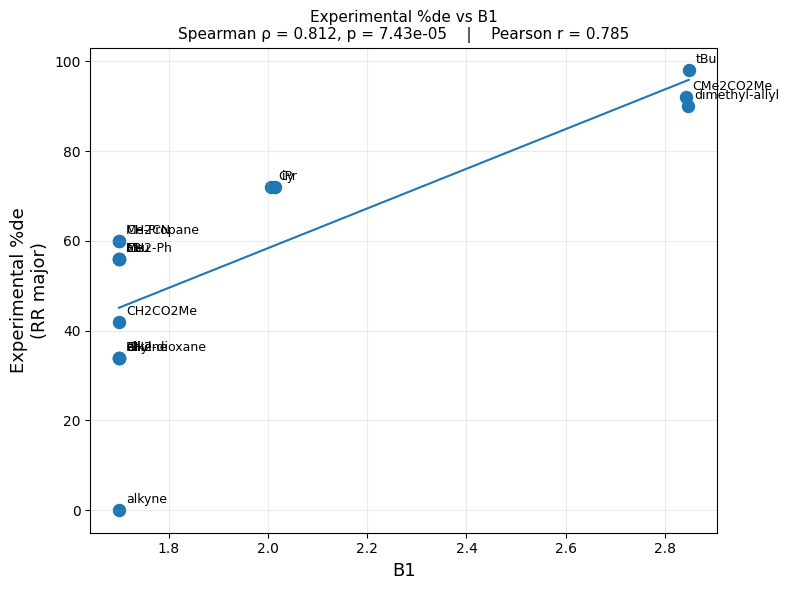

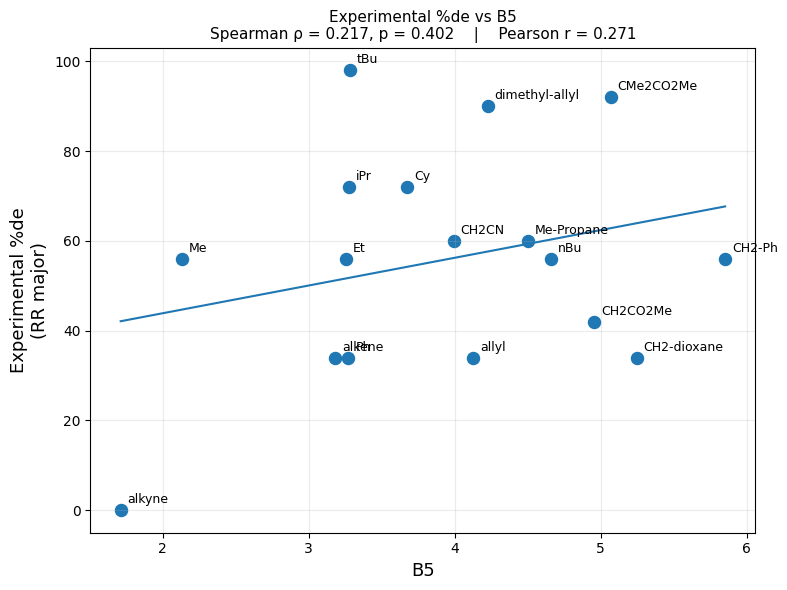

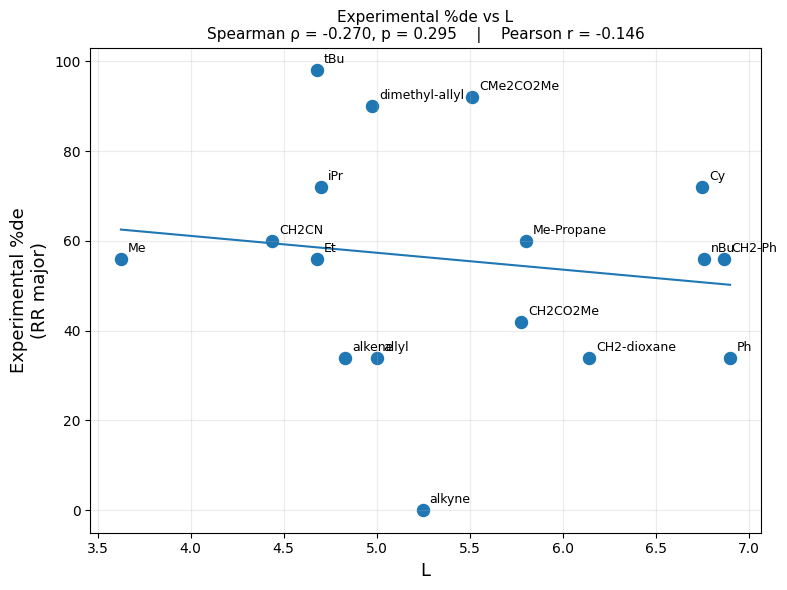

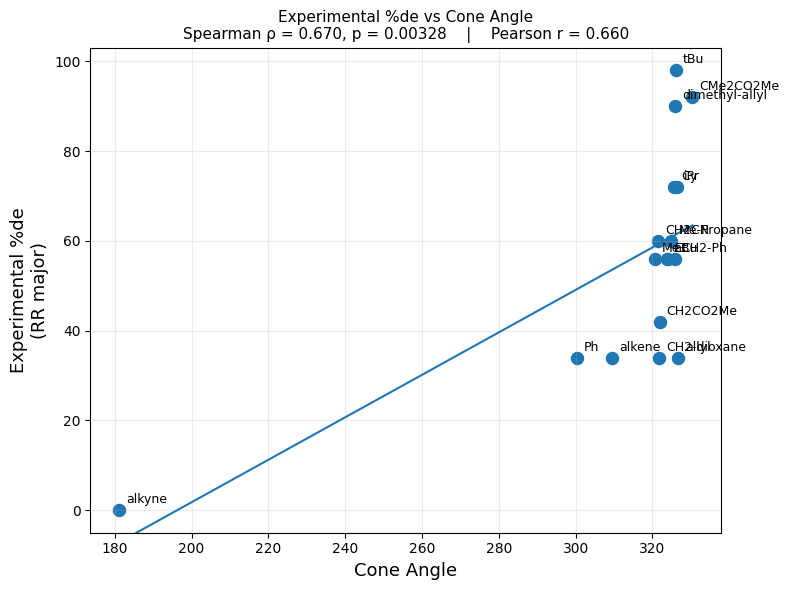

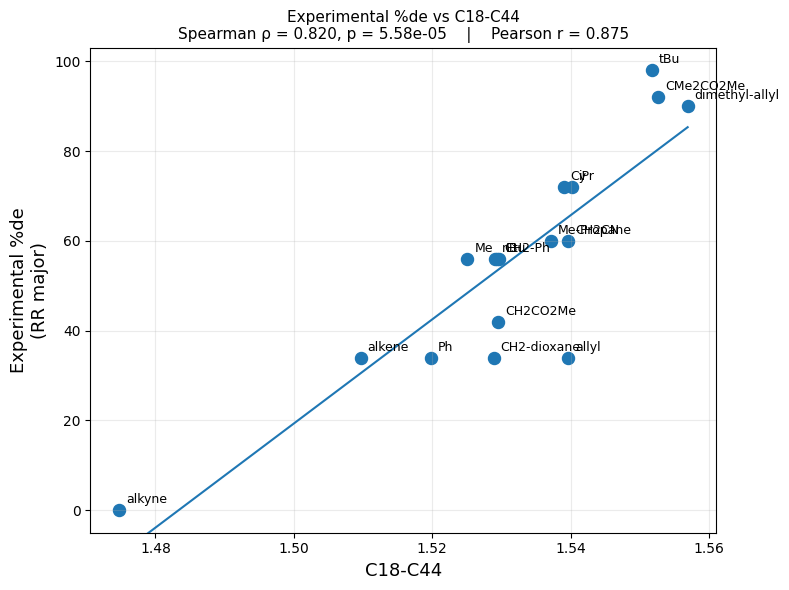

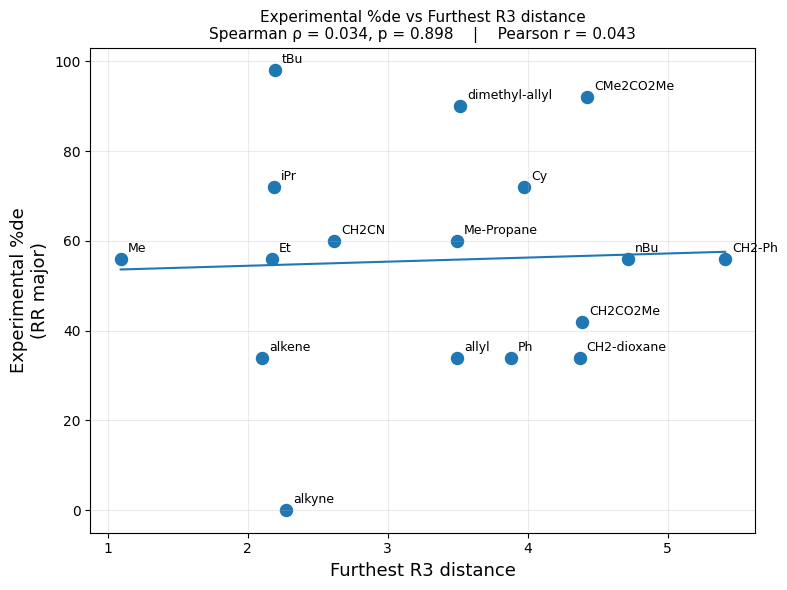

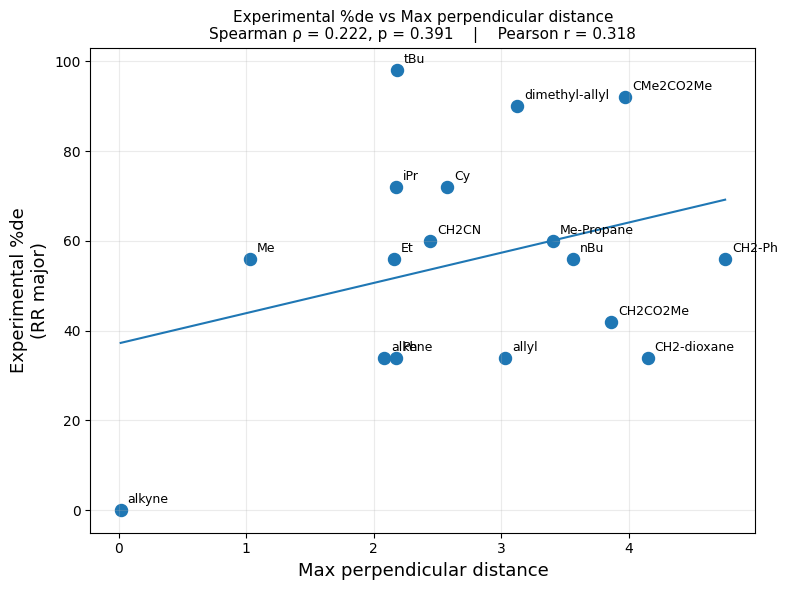



DONE

Excel file:
/content/drive/MyDrive/xyz_files/R3_%de_Correlation_Analysis.xlsx

PDF file:
/content/drive/MyDrive/xyz_files/R3_%de_Correlation_Diagrams.pdf


In [4]:
# ============================================================
# INSTALL
# ============================================================

!pip install -q pandas numpy openpyxl scipy matplotlib


# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import drive


# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive', force_remount=True)


# ============================================================
# PATH
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"

input_file = os.path.join(
    xyz_folder,
    "ALL_R3_Steric_Parameters.xlsx"
)


# ============================================================
# CHECK FILE
# ============================================================

print("Checking file:")
print(input_file)

print("\nFile exists:",
      os.path.exists(input_file))


if not os.path.exists(input_file):

    raise FileNotFoundError(
        "ALL_R3_Steric_Parameters.xlsx "
        "was not found."
    )


# ============================================================
# READ CALCULATED STERIC DATA
# ============================================================

steric_df = pd.read_excel(
    input_file
)


print("\nCalculated data:")
display(steric_df)


# ============================================================
# EXPERIMENTAL DIastereoselectivity
#
# RR = MAJOR
# RS = MINOR
#
# Values are %de
# ============================================================

exp_data = {

    "RR_CH2-Ph.xyz": 56,

    "RR_CH2-dioxane.xyz": 34,

    "RR_CH2CN.xyz": 60,

    "RR_CH2CO2Me.xyz": 42,

    "RR_CMe2CO2Me.xyz": 92,

    "RR_Cy.xyz": 72,

    "RR_Et.xyz": 56,

    "RR_Me-Propane.xyz": 60,

    "RR_Me.xyz": 56,

    "RR_Ph.xyz": 34,

    "RR_alkene.xyz": 34,

    "RR_alkyne.xyz": 0,

    "RR_allyl.xyz": 34,

    "RR_dimethyl-allyl.xyz": 90,

    "RR_iPr.xyz": 72,

    "RR_nBu.xyz": 56,

    "RR_tBu.xyz": 98

}


exp_df = pd.DataFrame(

    list(exp_data.items()),

    columns=[
        "File",
        "Experimental_%de"
    ]

)


# ============================================================
# STANDARDIZE COLUMN NAMES
# ============================================================

rename_dict = {

    "Sterimol B1 (Å)": "B1",

    "B1 (Å)": "B1",

    "Sterimol B5 (Å)": "B5",

    "B5 (Å)": "B5",

    "Sterimol L (Å)": "L",

    "L (Å)": "L",

    "Cone Angle (deg)": "Cone Angle",

    "Cone Angle": "Cone Angle",

    "C18-C44 distance (Å)": "C18-C44",

    "C18-C44 (Å)": "C18-C44",

    "C44-furthest R3 distance (Å)":
        "Furthest R3 distance",

    "C44-furthest R3 (Å)":
        "Furthest R3 distance",

    "Max perpendicular distance (Å)":
        "Max perpendicular distance"

}


for old_name, new_name in rename_dict.items():

    if old_name in steric_df.columns:

        steric_df = steric_df.rename(

            columns={
                old_name: new_name
            }

        )


# ============================================================
# PARAMETERS TO CORRELATE
# ============================================================

parameters = [

    "B1",

    "B5",

    "L",

    "Cone Angle",

    "C18-C44",

    "Furthest R3 distance",

    "Max perpendicular distance"

]


# ============================================================
# CHECK PARAMETERS
# ============================================================

missing = [

    p

    for p in parameters

    if p not in steric_df.columns

]


if missing:

    print("\nMissing parameters:")

    print(missing)

    print("\nAvailable columns:")

    print(
        list(steric_df.columns)
    )

    raise ValueError(
        "Some required parameters are missing."
    )


# ============================================================
# MERGE EXPERIMENTAL + CALCULATED DATA
# ============================================================

df = exp_df.merge(

    steric_df,

    on="File",

    how="left"

)


# ============================================================
# R3 LABEL
# ============================================================

df["R3"] = (

    df["File"]

    .str.replace(
        "RR_",
        "",
        regex=False
    )

    .str.replace(
        ".xyz",
        "",
        regex=False
    )

)


# ============================================================
# CONVERT TO NUMERIC
# ============================================================

df["Experimental_%de"] = pd.to_numeric(

    df["Experimental_%de"],

    errors="coerce"

)


for p in parameters:

    df[p] = pd.to_numeric(

        df[p],

        errors="coerce"

    )


# ============================================================
# DISPLAY MERGED DATA
# ============================================================

print("\n")
print("=" * 70)
print("MERGED EXPERIMENTAL + CALCULATED DATA")
print("=" * 70)

display(

    df[
        ["File", "R3", "Experimental_%de"]
        + parameters
    ]

)


# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_results = []


for parameter in parameters:

    sub = df[
        [
            "R3",
            "Experimental_%de",
            parameter
        ]
    ].dropna()


    x = sub[parameter].values

    y = sub["Experimental_%de"].values


    # --------------------------------------------------------
    # Spearman
    # --------------------------------------------------------

    if (
        len(x) >= 3
        and len(np.unique(x)) > 1
    ):

        rho, rho_p = spearmanr(
            x,
            y
        )

    else:

        rho = np.nan
        rho_p = np.nan


    # --------------------------------------------------------
    # Pearson
    # --------------------------------------------------------

    if (
        len(x) >= 3
        and len(np.unique(x)) > 1
    ):

        r, r_p = pearsonr(
            x,
            y
        )

    else:

        r = np.nan
        r_p = np.nan


    correlation_results.append({

        "Parameter":
            parameter,

        "N":
            len(x),

        "Spearman rho":
            rho,

        "Spearman p-value":
            rho_p,

        "Pearson r":
            r,

        "Pearson p-value":
            r_p

    })


# ============================================================
# CORRELATION TABLE
# ============================================================

corr_df = pd.DataFrame(
    correlation_results
)


print("\n")
print("=" * 70)
print("CORRELATION STATISTICS")
print("=" * 70)

display(
    corr_df
)


# ============================================================
# CREATE PDF
# ============================================================

pdf_file = os.path.join(

    xyz_folder,

    "R3_%de_Correlation_Diagrams.pdf"

)


with PdfPages(pdf_file) as pdf:


    for parameter in parameters:


        sub = df[
            [
                "R3",
                "Experimental_%de",
                parameter
            ]
        ].dropna()


        x = sub[parameter].values

        y = sub["Experimental_%de"].values


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        stat = corr_df[
            corr_df["Parameter"] == parameter
        ].iloc[0]


        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(8, 6)
        )


        ax.scatter(

            x,

            y,

            s=75

        )


        # ----------------------------------------------------
        # Linear trend line
        # ----------------------------------------------------

        if (

            len(x) >= 2

            and
            np.ptp(x) > 0

        ):

            slope, intercept = np.polyfit(

                x,

                y,

                1

            )


            xx = np.linspace(

                x.min(),

                x.max(),

                200

            )


            yy = (
                slope * xx
                + intercept
            )


            ax.plot(

                xx,

                yy

            )


        # ----------------------------------------------------
        # Label each R3
        # ----------------------------------------------------

        for _, row in sub.iterrows():

            ax.annotate(

                row["R3"],

                (
                    row[parameter],

                    row[
                        "Experimental_%de"
                    ]
                ),

                xytext=(5, 5),

                textcoords="offset points",

                fontsize=9

            )


        # ----------------------------------------------------
        # Axis labels
        # ----------------------------------------------------

        ax.set_xlabel(

            parameter,

            fontsize=13

        )


        ax.set_ylabel(

            "Experimental %de\n(RR major)",

            fontsize=13

        )


        # ----------------------------------------------------
        # Title
        # ----------------------------------------------------

        ax.set_title(

            f"Experimental %de vs {parameter}\n"
            f"Spearman ρ = "
            f"{stat['Spearman rho']:.3f}, "
            f"p = "
            f"{stat['Spearman p-value']:.3g}    |    "
            f"Pearson r = "
            f"{stat['Pearson r']:.3f}",

            fontsize=11

        )


        ax.set_ylim(
            -5,
            103
        )


        ax.grid(
            alpha=0.25
        )


        fig.tight_layout()


        pdf.savefig(
            fig
        )


        plt.show()

        plt.close(fig)


# ============================================================
# SAVE EXCEL
# ============================================================

excel_output = os.path.join(

    xyz_folder,

    "R3_%de_Correlation_Analysis.xlsx"

)


with pd.ExcelWriter(

    excel_output,

    engine="openpyxl"

) as writer:


    df.to_excel(

        writer,

        sheet_name="Merged_Data",

        index=False

    )


    corr_df.to_excel(

        writer,

        sheet_name="Correlation_Statistics",

        index=False

    )


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 70)
print("DONE")
print("=" * 70)

print(
    "\nExcel file:"
)

print(
    excel_output
)

print(
    "\nPDF file:"
)

print(
    pdf_file
)

Mounted at /content/drive
CHECKING INPUT FILE

Input file:
/content/drive/MyDrive/xyz_files/ALL_R3_Steric_Parameters.xlsx

File exists: True

Columns in Excel:
   File
   Status
   Number of atoms
   R3
   R3 atoms
   C18-C44 distance (Å)
   Furthest R3 atom
   C44-furthest R3 distance (Å)
   Max perpendicular atom
   Max perpendicular distance (Å)
   Sterimol B1 (Å)
   Sterimol B5 (Å)
   Sterimol L (Å)
   Cone Angle (deg)
   Error

Number of experimental compounds:
17


SPEARMAN CORRELATION MATRIX


,Experimental_%de,B1,B5,L,Cone_Angle,C18_C44,Furthest_R3,Max_Perpendicular
Experimental_%de,1.000,0.812,0.217,-0.270,0.670,0.820,0.034,0.222
B1,0.812,1.000,0.061,-0.216,0.658,0.757,0.002,0.081
B5,0.217,0.061,1.000,0.525,0.461,0.343,0.843,0.998
L,-0.270,-0.216,0.525,1.000,-0.047,-0.279,0.806,0.554
Cone_Angle,0.670,0.658,0.461,-0.047,1.000,0.865,0.250,0.475
C18_C44,0.820,0.757,0.343,-0.279,0.865,1.000,0.105,0.341
Furthest_R3,0.034,0.002,0.843,0.806,0.250,0.105,1.000,0.855
Max_Perpendicular,0.222,0.081,0.998,0.554,0.475,0.341,0.855,1.000




PEARSON CORRELATION MATRIX


,Experimental_%de,B1,B5,L,Cone_Angle,C18_C44,Furthest_R3,Max_Perpendicular
Experimental_%de,1.000,0.785,0.271,-0.146,0.660,0.875,0.043,0.318
B1,0.785,1.000,0.090,-0.174,0.218,0.613,0.008,0.113
B5,0.271,0.090,1.000,0.546,0.568,0.505,0.858,0.991
L,-0.146,-0.174,0.546,1.000,0.018,-0.070,0.856,0.539
Cone_Angle,0.660,0.218,0.568,0.018,1.000,0.850,0.248,0.643
C18_C44,0.875,0.613,0.505,-0.070,0.850,1.000,0.225,0.554
Furthest_R3,0.043,0.008,0.858,0.856,0.248,0.225,1.000,0.839
Max_Perpendicular,0.318,0.113,0.991,0.539,0.643,0.554,0.839,1.000




SPEARMAN CORRELATION WITH EXPERIMENTAL %de


,Parameter,N,Spearman rho,p-value
4,C18_C44,17,0.8200,0.0001
0,B1,17,0.8124,0.0001
3,Cone_Angle,17,0.6696,0.0033
2,L,17,-0.2696,0.2954
6,Max_Perpendicular,17,0.2224,0.3910
1,B5,17,0.2174,0.4019
5,Furthest_R3,17,0.0335,0.8983




PEARSON CORRELATION WITH EXPERIMENTAL %de


,Parameter,N,Pearson r,p-value
4,C18_C44,17,0.8746,0.0000
0,B1,17,0.7847,0.0002
3,Cone_Angle,17,0.6601,0.0039
6,Max_Perpendicular,17,0.3177,0.2140
1,B5,17,0.2708,0.2931
2,L,17,-0.1462,0.5755
5,Furthest_R3,17,0.0433,0.8690


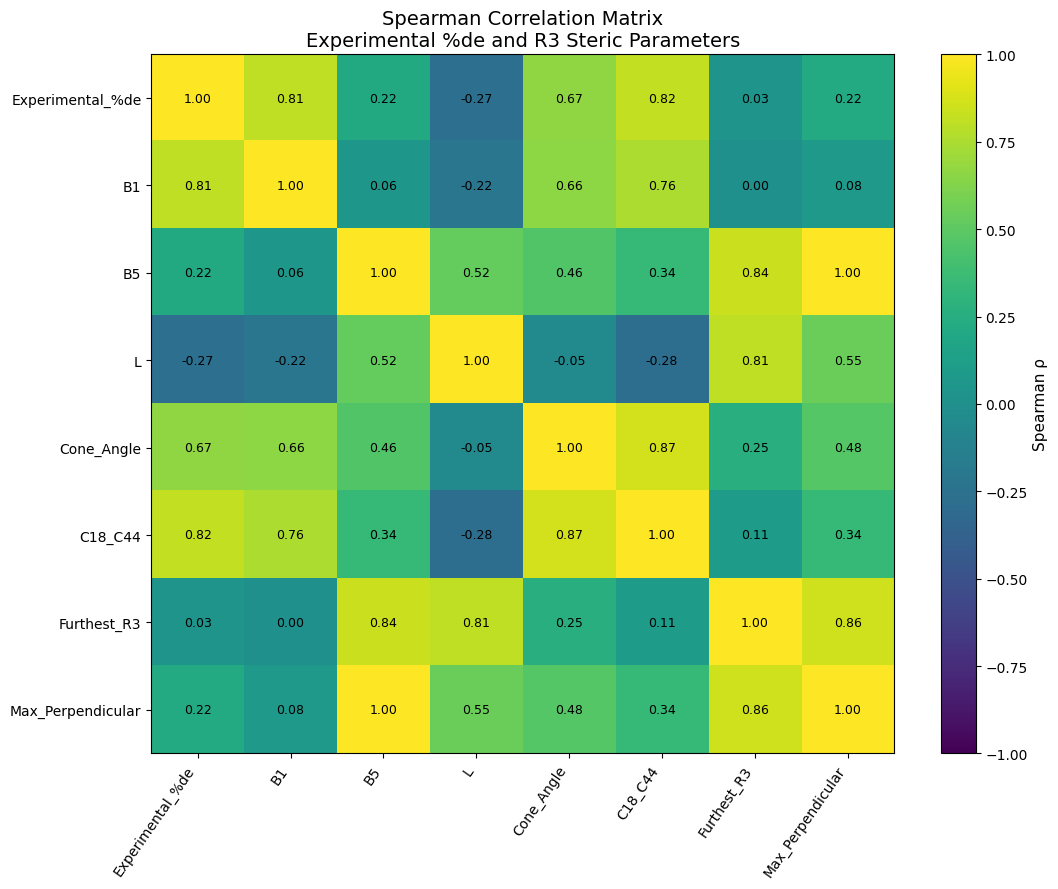

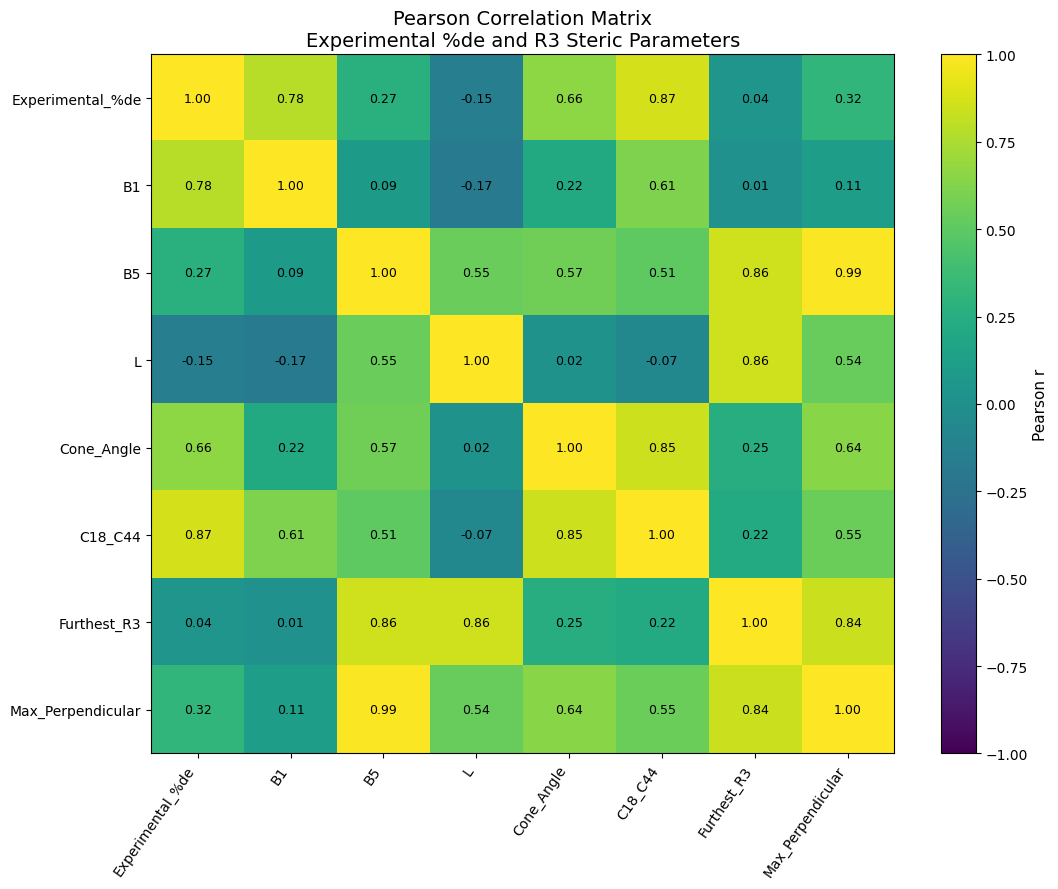



CORRELATION ANALYSIS COMPLETED

Number of compounds: 17

Excel:
/content/drive/MyDrive/xyz_files/R3_Correlation_Matrices.xlsx

PDF:
/content/drive/MyDrive/xyz_files/R3_Correlation_Matrices_Heatmaps.pdf

Spearman PNG:
/content/drive/MyDrive/xyz_files/Spearman_Correlation_Matrix.png

Pearson PNG:
/content/drive/MyDrive/xyz_files/Pearson_Correlation_Matrix.png


In [5]:
# ============================================================
# R3 STERIC PARAMETERS vs EXPERIMENTAL %de
# CORRELATION MATRIX
#
# RR = major product
# RS = minor product
#
# Input:
# ALL_R3_Steric_Parameters.xlsx
#
# Output:
# 1. R3_Correlation_Matrices.xlsx
# 2. R3_Correlation_Matrices_Heatmaps.pdf
# 3. Pearson heatmap
# 4. Spearman heatmap
# ============================================================


# ============================================================
# 1. INSTALL
# ============================================================

!pip install -q pandas numpy openpyxl scipy matplotlib


# ============================================================
# 2. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import spearmanr, pearsonr
from google.colab import drive
from matplotlib.backends.backend_pdf import PdfPages


# ============================================================
# 3. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=True
)


# ============================================================
# 4. FILE PATH
# ============================================================

xyz_folder = Path(
    "/content/drive/MyDrive/xyz_files"
)

input_file = (
    xyz_folder /
    "ALL_R3_Steric_Parameters.xlsx"
)


print("=" * 70)
print("CHECKING INPUT FILE")
print("=" * 70)

print(
    "\nInput file:"
)

print(input_file)

print(
    "\nFile exists:",
    input_file.exists()
)


if not input_file.exists():

    raise FileNotFoundError(
        "\nALL_R3_Steric_Parameters.xlsx "
        "was not found."
    )


# ============================================================
# 5. READ STERIC DATA
# ============================================================

steric_df = pd.read_excel(
    input_file
)


print("\nColumns in Excel:")

for col in steric_df.columns:
    print("  ", col)


# ============================================================
# 6. EXPERIMENTAL %de
#
# RR = MAJOR
# RS = MINOR
# ============================================================

exp_data = {

    "RR_CH2-Ph.xyz": 56,

    "RR_CH2-dioxane.xyz": 34,

    "RR_CH2CN.xyz": 60,

    "RR_CH2CO2Me.xyz": 42,

    "RR_CMe2CO2Me.xyz": 92,

    "RR_Cy.xyz": 72,

    "RR_Et.xyz": 56,

    "RR_Me-Propane.xyz": 60,

    "RR_Me.xyz": 56,

    "RR_Ph.xyz": 34,

    "RR_alkene.xyz": 34,

    "RR_alkyne.xyz": 0,

    "RR_allyl.xyz": 34,

    "RR_dimethyl-allyl.xyz": 90,

    "RR_iPr.xyz": 72,

    "RR_nBu.xyz": 56,

    "RR_tBu.xyz": 98

}


exp_df = pd.DataFrame(

    list(exp_data.items()),

    columns=[
        "File",
        "Experimental_%de"
    ]

)


print("\nNumber of experimental compounds:")

print(
    len(exp_df)
)


# ============================================================
# 7. STANDARDIZE COLUMN NAMES
# ============================================================

rename_dict = {

    "Sterimol B1 (Å)": "B1",

    "B1 (Å)": "B1",

    "Sterimol B5 (Å)": "B5",

    "B5 (Å)": "B5",

    "Sterimol L (Å)": "L",

    "L (Å)": "L",

    "Cone Angle (deg)": "Cone_Angle",

    "Cone Angle": "Cone_Angle",

    "C18-C44 distance (Å)": "C18_C44",

    "C18-C44 (Å)": "C18_C44",

    "C44-furthest R3 distance (Å)":
        "Furthest_R3",

    "C44-furthest R3 (Å)":
        "Furthest_R3",

    "Max perpendicular distance (Å)":
        "Max_Perpendicular"

}


for old_name, new_name in rename_dict.items():

    if old_name in steric_df.columns:

        steric_df = steric_df.rename(

            columns={
                old_name: new_name
            }

        )


# ============================================================
# 8. PARAMETERS FOR CORRELATION
# ============================================================

parameters = [

    "B1",

    "B5",

    "L",

    "Cone_Angle",

    "C18_C44",

    "Furthest_R3",

    "Max_Perpendicular"

]


# ============================================================
# 9. CHECK PARAMETERS
# ============================================================

missing = [

    p

    for p in parameters

    if p not in steric_df.columns

]


if missing:

    print(
        "\nMissing parameters:"
    )

    for p in missing:
        print(
            "  ",
            p
        )

    print(
        "\nAvailable columns:"
    )

    print(
        list(steric_df.columns)
    )

    raise ValueError(
        "\nRequired parameters are missing."
    )


# ============================================================
# 10. MERGE EXPERIMENTAL + CALCULATED DATA
# ============================================================

df = exp_df.merge(

    steric_df,

    on="File",

    how="left"

)


# ============================================================
# 11. R3 NAME
# ============================================================

df["R3"] = (

    df["File"]

    .str.replace(
        "RR_",
        "",
        regex=False
    )

    .str.replace(
        ".xyz",
        "",
        regex=False
    )

)


# ============================================================
# 12. CONVERT TO NUMERIC
# ============================================================

df["Experimental_%de"] = pd.to_numeric(

    df["Experimental_%de"],

    errors="coerce"

)


for p in parameters:

    df[p] = pd.to_numeric(

        df[p],

        errors="coerce"

    )


# ============================================================
# 13. SELECT DATA FOR CORRELATION
# ============================================================

correlation_columns = [

    "Experimental_%de"

] + parameters


correlation_data = df[
    correlation_columns
].copy()


# ============================================================
# 14. SPEARMAN CORRELATION MATRIX
# ============================================================

spearman_matrix = correlation_data.corr(

    method="spearman"

)


# ============================================================
# 15. PEARSON CORRELATION MATRIX
# ============================================================

pearson_matrix = correlation_data.corr(

    method="pearson"

)


# ============================================================
# 16. PRINT SPEARMAN MATRIX
# ============================================================

print("\n")
print("=" * 70)
print("SPEARMAN CORRELATION MATRIX")
print("=" * 70)

display(
    spearman_matrix.round(3)
)


# ============================================================
# 17. PRINT PEARSON MATRIX
# ============================================================

print("\n")
print("=" * 70)
print("PEARSON CORRELATION MATRIX")
print("=" * 70)

display(
    pearson_matrix.round(3)
)


# ============================================================
# 18. SPEARMAN CORRELATION WITH %de ONLY
# ============================================================

print("\n")
print("=" * 70)
print("SPEARMAN CORRELATION WITH EXPERIMENTAL %de")
print("=" * 70)


spearman_results = []


for p in parameters:

    sub = df[
        [
            "Experimental_%de",
            p
        ]
    ].dropna()


    rho, p_value = spearmanr(

        sub["Experimental_%de"],

        sub[p]

    )


    spearman_results.append({

        "Parameter":
            p,

        "N":
            len(sub),

        "Spearman rho":
            rho,

        "p-value":
            p_value

    })


spearman_results_df = pd.DataFrame(

    spearman_results

)


display(

    spearman_results_df.sort_values(

        "Spearman rho",

        key=lambda x: x.abs(),

        ascending=False

    ).round(4)

)


# ============================================================
# 19. PEARSON CORRELATION WITH %de ONLY
# ============================================================

print("\n")
print("=" * 70)
print("PEARSON CORRELATION WITH EXPERIMENTAL %de")
print("=" * 70)


pearson_results = []


for p in parameters:

    sub = df[
        [
            "Experimental_%de",
            p
        ]
    ].dropna()


    r, p_value = pearsonr(

        sub["Experimental_%de"],

        sub[p]

    )


    pearson_results.append({

        "Parameter":
            p,

        "N":
            len(sub),

        "Pearson r":
            r,

        "p-value":
            p_value

    })


pearson_results_df = pd.DataFrame(

    pearson_results

)


display(

    pearson_results_df.sort_values(

        "Pearson r",

        key=lambda x: x.abs(),

        ascending=False

    ).round(4)

)


# ============================================================
# 20. CREATE SPEARMAN HEATMAP
# ============================================================

fig, ax = plt.subplots(

    figsize=(11, 9)

)


im = ax.imshow(

    spearman_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto"

)


ax.set_xticks(

    range(
        len(spearman_matrix.columns)
    )

)


ax.set_yticks(

    range(
        len(spearman_matrix.index)
    )

)


ax.set_xticklabels(

    spearman_matrix.columns,

    rotation=55,

    ha="right",

    fontsize=10

)


ax.set_yticklabels(

    spearman_matrix.index,

    fontsize=10

)


# Values inside cells

for i in range(
    len(spearman_matrix.index)
):

    for j in range(
        len(spearman_matrix.columns)
    ):

        value = spearman_matrix.iloc[i, j]

        ax.text(

            j,

            i,

            f"{value:.2f}",

            ha="center",

            va="center",

            fontsize=9

        )


ax.set_title(

    "Spearman Correlation Matrix\n"
    "Experimental %de and R3 Steric Parameters",

    fontsize=14

)


cbar = fig.colorbar(

    im,

    ax=ax

)


cbar.set_label(

    "Spearman ρ",

    fontsize=11

)


fig.tight_layout()


# ============================================================
# SAVE SPEARMAN FIGURE
# ============================================================

spearman_png = (

    xyz_folder /

    "Spearman_Correlation_Matrix.png"

)


fig.savefig(

    spearman_png,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close(fig)


# ============================================================
# 21. CREATE PEARSON HEATMAP
# ============================================================

fig, ax = plt.subplots(

    figsize=(11, 9)

)


im = ax.imshow(

    pearson_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto"

)


ax.set_xticks(

    range(
        len(pearson_matrix.columns)
    )

)


ax.set_yticks(

    range(
        len(pearson_matrix.index)
    )

)


ax.set_xticklabels(

    pearson_matrix.columns,

    rotation=55,

    ha="right",

    fontsize=10

)


ax.set_yticklabels(

    pearson_matrix.index,

    fontsize=10

)


for i in range(
    len(pearson_matrix.index)
):

    for j in range(
        len(pearson_matrix.columns)
    ):

        value = pearson_matrix.iloc[i, j]

        ax.text(

            j,

            i,

            f"{value:.2f}",

            ha="center",

            va="center",

            fontsize=9

        )


ax.set_title(

    "Pearson Correlation Matrix\n"
    "Experimental %de and R3 Steric Parameters",

    fontsize=14

)


cbar = fig.colorbar(

    im,

    ax=ax

)


cbar.set_label(

    "Pearson r",

    fontsize=11

)


fig.tight_layout()


# ============================================================
# SAVE PEARSON FIGURE
# ============================================================

pearson_png = (

    xyz_folder /

    "Pearson_Correlation_Matrix.png"

)


fig.savefig(

    pearson_png,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close(fig)


# ============================================================
# 22. SAVE BOTH HEATMAPS INTO ONE PDF
# ============================================================

pdf_file = (

    xyz_folder /

    "R3_Correlation_Matrices_Heatmaps.pdf"

)


with PdfPages(pdf_file) as pdf:

    # -----------------------------
    # Spearman
    # -----------------------------

    fig, ax = plt.subplots(

        figsize=(11, 9)

    )


    im = ax.imshow(

        spearman_matrix.values,

        vmin=-1,

        vmax=1,

        aspect="auto"

    )


    ax.set_xticks(

        range(
            len(spearman_matrix.columns)
        )

    )

    ax.set_yticks(

        range(
            len(spearman_matrix.index)
        )

    )


    ax.set_xticklabels(

        spearman_matrix.columns,

        rotation=55,

        ha="right"

    )


    ax.set_yticklabels(

        spearman_matrix.index

    )


    for i in range(
        len(spearman_matrix.index)
    ):

        for j in range(
            len(spearman_matrix.columns)
        ):

            ax.text(

                j,

                i,

                f"{spearman_matrix.iloc[i,j]:.2f}",

                ha="center",

                va="center"

            )


    ax.set_title(

        "Spearman Correlation Matrix"

    )


    fig.colorbar(

        im,

        ax=ax,

        label="Spearman ρ"

    )


    fig.tight_layout()

    pdf.savefig(fig)

    plt.close(fig)


    # -----------------------------
    # Pearson
    # -----------------------------

    fig, ax = plt.subplots(

        figsize=(11, 9)

    )


    im = ax.imshow(

        pearson_matrix.values,

        vmin=-1,

        vmax=1,

        aspect="auto"

    )


    ax.set_xticks(

        range(
            len(pearson_matrix.columns)
        )

    )

    ax.set_yticks(

        range(
            len(pearson_matrix.index)
        )

    )


    ax.set_xticklabels(

        pearson_matrix.columns,

        rotation=55,

        ha="right"

    )


    ax.set_yticklabels(

        pearson_matrix.index

    )


    for i in range(
        len(pearson_matrix.index)
    ):

        for j in range(
            len(pearson_matrix.columns)
        ):

            ax.text(

                j,

                i,

                f"{pearson_matrix.iloc[i,j]:.2f}",

                ha="center",

                va="center"

            )


    ax.set_title(

        "Pearson Correlation Matrix"

    )


    fig.colorbar(

        im,

        ax=ax,

        label="Pearson r"

    )


    fig.tight_layout()

    pdf.savefig(fig)

    plt.close(fig)


# ============================================================
# 23. SAVE EVERYTHING TO EXCEL
# ============================================================

excel_output = (

    xyz_folder /

    "R3_Correlation_Matrices.xlsx"

)


with pd.ExcelWriter(

    excel_output,

    engine="openpyxl"

) as writer:


    # Original merged data

    df.to_excel(

        writer,

        sheet_name="Merged_Data",

        index=False

    )


    # Spearman matrix

    spearman_matrix.to_excel(

        writer,

        sheet_name="Spearman_Matrix"

    )


    # Pearson matrix

    pearson_matrix.to_excel(

        writer,

        sheet_name="Pearson_Matrix"

    )


    # Spearman statistics

    spearman_results_df.to_excel(

        writer,

        sheet_name="Spearman_%de",

        index=False

    )


    # Pearson statistics

    pearson_results_df.to_excel(

        writer,

        sheet_name="Pearson_%de",

        index=False

    )


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("CORRELATION ANALYSIS COMPLETED")
print("=" * 70)


print(
    "\nNumber of compounds:",
    len(df)
)


print(
    "\nExcel:"
)

print(
    excel_output
)


print(
    "\nPDF:"
)

print(
    pdf_file
)


print(
    "\nSpearman PNG:"
)

print(
    spearman_png
)


print(
    "\nPearson PNG:"
)

print(
    pearson_png
)

In [6]:
def compute_cone_angle_debug(elements, coordinates, vertex_idx_1based, first_r3_idx_1based):
    # Define vdW radii (from the main loop)
    vdw_radii = {
        "H": 1.20, "C": 1.70, "N": 1.55, "O": 1.52, "F": 1.47,
        "P": 1.80, "S": 1.80, "Cl": 1.75, "Br": 1.85, "I": 1.98
    }

    n_atoms = len(elements)

    # Determine R3_atoms (from the main loop, adjusted for debugging a single file)
    # In the original loop, R3_atoms go from R3_START_ATOM to n_atoms.
    # For a debug function, `first_r3_idx_1based` is the start, and `n_atoms` is the end.
    R3_atoms = list(range(first_r3_idx_1based, n_atoms + 1))

    # C18 (vertex) and C44 (first R3 atom) coordinates
    r_vertex = coordinates[vertex_idx_1based - 1]
    r_first_r3 = coordinates[first_r3_idx_1based - 1]

    # C18 -> C44 axis (vertex to first R3 atom)
    axis_vector = r_first_r3 - r_vertex
    C18_C44 = np.linalg.norm(axis_vector)

    if C18_C44 < 1.0e-8:
        # Handle the case where the axis is too short, similar to the original code
        return np.nan # Or raise an error as in the main loop

    unit_axis = axis_vector / C18_C44

    half_angles = []

    for atom_idx_1based in R3_atoms:
        r_atom = coordinates[atom_idx_1based - 1]

        # Vector from C44 (first R3 atom) to current R3 atom
        v = r_atom - r_first_r3 # The original code uses r44 (r_first_r3 here)

        distance = np.linalg.norm(v)

        if distance < 1.0e-8:
            continue

        # Angle between C18-C44 axis and C44-atom vector
        cos_theta = np.dot(unit_axis, v / distance)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)

        # van der Waals radius
        element = elements[atom_idx_1based - 1]
        radius = vdw_radii.get(element, 1.70)

        # Angular radius of atom
        if distance > radius:
            alpha = np.arcsin(radius / distance)
        else:
            alpha = np.pi / 2

        half_angles.append(theta + alpha)

    if len(half_angles) > 0:
        cone_half_angle = max(half_angles)
        cone_angle = 2.0 * np.degrees(cone_half_angle)
    else:
        cone_angle = np.nan

    return cone_angle

test_path = os.path.join(xyz_folder, "RR_Me.xyz")
elements, coordinates = read_xyz(test_path)
coordinates = np.asarray(coordinates, dtype=float)

print(f"Testing RR_Me.xyz — {len(elements)} atoms\n")

# sanity check: confirm atom 18 and atom 44 are really what we expect
print(f"Atom 18 (should be C, the C2/C18 vertex): {elements[17]}  coords={coordinates[17]}")
print(f"Atom 44 (should be C, first R3 atom):     {elements[43]}  coords={coordinates[43]}")
print(f"Total atoms in file: {len(elements)}\n")

angle = compute_cone_angle_debug(elements, coordinates, vertex_idx_1based=18, first_r3_idx_1based=44)
print(f"\nFinal cone angle = {angle:.3f}°")

Testing RR_Me.xyz — 47 atoms

Atom 18 (should be C, the C2/C18 vertex): C  coords=[1.513314 0.279963 0.948737]
Atom 44 (should be C, first R3 atom):     C  coords=[2.127998 1.366772 0.072992]
Total atoms in file: 47


Final cone angle = 320.731°


In [7]:
# ============================================================
# FRESH, SELF-CONTAINED DIAGNOSTIC — run after Runtime > Restart
# ============================================================
import os
import numpy as np
from morfeus import read_xyz

xyz_folder = "/content/drive/MyDrive/xyz_files"

vdw_radii = {
    "H": 1.20, "C": 1.70, "N": 1.55, "O": 1.52, "F": 1.47,
    "P": 1.80, "S": 1.80, "Cl": 1.75, "Br": 1.85, "I": 1.98,
}

def compute_cone_angle_debug(elements, coordinates, vertex_idx_1based, first_r3_idx_1based):
    n_atoms = len(elements)
    r18 = coordinates[vertex_idx_1based - 1]
    r44 = coordinates[first_r3_idx_1based - 1]

    axis_vec = r44 - r18
    axis_norm = np.linalg.norm(axis_vec)
    print(f"C18->C44 axis vector: {axis_vec}, length = {axis_norm:.3f} Å")
    if axis_norm < 1e-8:
        return np.nan
    unit_axis = axis_vec / axis_norm

    R3_atoms_local = list(range(first_r3_idx_1based, n_atoms + 1))
    print(f"R3 atoms being scanned: {R3_atoms_local}\n")
    half_angles = []

    for atom_index in R3_atoms_local:
        r_atom = coordinates[atom_index - 1]
        v = r_atom - r18
        distance = np.linalg.norm(v)
        if distance < 1e-8:
            continue

        cos_theta = np.dot(unit_axis, v / distance)
        cos_theta_clipped = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta_clipped)

        element = elements[atom_index - 1]
        radius = vdw_radii.get(element, 1.70)

        if distance > radius:
            alpha = np.arcsin(np.clip(radius / distance, -1.0, 1.0))
        else:
            alpha = np.pi / 2

        edge_angle = min(theta + alpha, np.pi)
        half_angles.append(edge_angle)

        print(f"  atom {atom_index:3d} ({element}): dist(C18)={distance:.3f} Å  "
              f"cos_theta(raw)={cos_theta:8.4f}  theta={np.degrees(theta):7.2f}°  "
              f"alpha={np.degrees(alpha):6.2f}°  edge(capped)={np.degrees(edge_angle):7.2f}°")

    if len(half_angles) == 0:
        return np.nan

    cone_half_angle = min(max(half_angles), np.pi / 2)
    final_angle = 2.0 * np.degrees(cone_half_angle)
    print(f"\nmax(half_angles) before final cap = {np.degrees(max(half_angles)):.3f}°")
    print(f"cone_half_angle after cap = {np.degrees(cone_half_angle):.3f}°")
    return final_angle


def read_xyz_manual(path):
    with open(path) as f:
        lines = f.readlines()
    n_atoms = int(lines[0].strip())
    elements, coords = [], []
    for line in lines[2:2 + n_atoms]:
        parts = line.split()
        elements.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    return elements, np.array(coords)


test_path = os.path.join(xyz_folder, "RR_Me.xyz")
elements, coordinates = read_xyz_manual(test_path)   # bypass morfeus.read_xyz to rule out any format mismatch

print(f"Testing RR_Me.xyz — {len(elements)} atoms")
print(f"Atom 18: {elements[17]}  coords={coordinates[17]}")
print(f"Atom 44: {elements[43]}  coords={coordinates[43]}\n")

angle = compute_cone_angle_debug(elements, coordinates, vertex_idx_1based=18, first_r3_idx_1based=44)
print(f"\n>>> FINAL cone angle = {angle:.3f}° <<<")

Testing RR_Me.xyz — 47 atoms
Atom 18: C  coords=[1.513314 0.279963 0.948737]
Atom 44: C  coords=[2.127998 1.366772 0.072992]

C18->C44 axis vector: [ 0.614684  1.086809 -0.875745], length = 1.525 Å
R3 atoms being scanned: [44, 45, 46, 47]

  atom  44 (C): dist(C18)=1.525 Å  cos_theta(raw)=  1.0000  theta=   0.00°  alpha= 90.00°  edge(capped)=  90.00°
  atom  45 (H): dist(C18)=2.172 Å  cos_theta(raw)=  0.8829  theta=  28.01°  alpha= 33.54°  edge(capped)=  61.54°
  atom  46 (H): dist(C18)=2.154 Å  cos_theta(raw)=  0.8785  theta=  28.53°  alpha= 33.86°  edge(capped)=  62.39°
  atom  47 (H): dist(C18)=2.157 Å  cos_theta(raw)=  0.8788  theta=  28.50°  alpha= 33.81°  edge(capped)=  62.31°

max(half_angles) before final cap = 90.000°
cone_half_angle after cap = 90.000°

>>> FINAL cone angle = 180.000° <<<


In [8]:
def compute_cone_angle_fixed(elements, coordinates, vertex_idx_1based, first_r3_idx_1based):
    n_atoms = len(elements)
    r18 = coordinates[vertex_idx_1based - 1]
    r44 = coordinates[first_r3_idx_1based - 1]

    axis_vec = r44 - r18
    axis_norm = np.linalg.norm(axis_vec)
    if axis_norm < 1e-8:
        return np.nan
    unit_axis = axis_vec / axis_norm

    # EXCLUDE the axis-defining atom (first_r3_idx_1based) itself —
    # it has theta=0 by construction and carries no angular information
    R3_probe_atoms = list(range(first_r3_idx_1based + 1, n_atoms + 1))

    if len(R3_probe_atoms) == 0:
        return 0.0  # substituent has only one atom (e.g. a single F/Cl) — no meaningful cone

    half_angles = []
    for atom_index in R3_probe_atoms:
        r_atom = coordinates[atom_index - 1]
        v = r_atom - r18
        distance = np.linalg.norm(v)
        if distance < 1e-8:
            continue

        cos_theta = np.dot(unit_axis, v / distance)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)

        element = elements[atom_index - 1]
        radius = vdw_radii.get(element, 1.70)

        if distance > radius:
            alpha = np.arcsin(np.clip(radius / distance, -1.0, 1.0))
        else:
            alpha = np.pi / 2

        edge_angle = min(theta + alpha, np.pi)
        half_angles.append(edge_angle)

    if len(half_angles) == 0:
        return np.nan

    cone_half_angle = min(max(half_angles), np.pi / 2)
    return 2.0 * np.degrees(cone_half_angle)


# ---- re-test on RR_Me.xyz ----
angle = compute_cone_angle_fixed(elements, coordinates, vertex_idx_1based=18, first_r3_idx_1based=44)
print(f"Corrected cone angle for RR_Me = {angle:.3f}°")

Corrected cone angle for RR_Me = 124.788°


In [9]:
# ============================================================
# CONE ANGLE — FINAL CORRECTED VERSION (excludes axis-defining atom)
# ============================================================

vdw_radii = {
    "H": 1.20, "C": 1.70, "N": 1.55, "O": 1.52, "F": 1.47,
    "P": 1.80, "S": 1.80, "Cl": 1.75, "Br": 1.85, "I": 1.98,
}

def compute_cone_angle(elements, coordinates, vertex_idx_1based, first_r3_idx_1based):
    """
    Geometry-based cone angle for R3, vertex = C18, axis = C18->C44.
    Excludes the axis-defining atom (C44 itself) from the angular scan,
    since it always has theta=0 by construction and its short bond length
    (< its own vdW radius) would otherwise force a spurious 90 deg
    contribution, artificially saturating the result at 180 deg.
    Bounded 0-180 deg.
    """
    n_atoms = len(elements)
    r18 = coordinates[vertex_idx_1based - 1]
    r44 = coordinates[first_r3_idx_1based - 1]

    axis_vec = r44 - r18
    axis_norm = np.linalg.norm(axis_vec)
    if axis_norm < 1e-8:
        return np.nan
    unit_axis = axis_vec / axis_norm

    # Exclude the axis-defining atom itself
    R3_probe_atoms = list(range(first_r3_idx_1based + 1, n_atoms + 1))
    if len(R3_probe_atoms) == 0:
        return 0.0

    half_angles = []
    for atom_index in R3_probe_atoms:
        r_atom = coordinates[atom_index - 1]
        v = r_atom - r18
        distance = np.linalg.norm(v)
        if distance < 1e-8:
            continue

        cos_theta = np.dot(unit_axis, v / distance)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)

        element = elements[atom_index - 1]
        radius = vdw_radii.get(element, 1.70)

        if distance > radius:
            alpha = np.arcsin(np.clip(radius / distance, -1.0, 1.0))
        else:
            alpha = np.pi / 2

        edge_angle = min(theta + alpha, np.pi)
        half_angles.append(edge_angle)

    if len(half_angles) == 0:
        return np.nan

    cone_half_angle = min(max(half_angles), np.pi / 2)
    return 2.0 * np.degrees(cone_half_angle)


# ============================================================
# RUN ON ALL RR AND RS FILES
# ============================================================
import glob
import os
import numpy as np
import pandas as pd
from morfeus import read_xyz

xyz_folder = "/content/drive/MyDrive/xyz_files"

def analyze_cone_angle_all(prefix):
    files = sorted(glob.glob(os.path.join(xyz_folder, f"{prefix}_*.xyz")))
    rows = []
    for f in files:
        elements, coordinates = read_xyz(f)
        coordinates = np.asarray(coordinates, dtype=float)
        angle = compute_cone_angle(elements, coordinates, vertex_idx_1based=18, first_r3_idx_1based=44)
        rows.append({"File": os.path.basename(f), "Cone Angle (deg)": angle})
    return pd.DataFrame(rows)

df_rr_cone = analyze_cone_angle_all("RR")
df_rs_cone = analyze_cone_angle_all("RS")

print("=== RR cone angle (corrected) ===")
print(df_rr_cone.to_string(index=False))
print("\n=== RS cone angle (corrected) ===")
print(df_rs_cone.to_string(index=False))

out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
os.makedirs(out_dir, exist_ok=True)
df_rr_cone.to_csv(os.path.join(out_dir, "RR_cone_angle_corrected.csv"), index=False)
df_rs_cone.to_csv(os.path.join(out_dir, "RS_cone_angle_corrected.csv"), index=False)

=== RR cone angle (corrected) ===
                 File  Cone Angle (deg)
        RR_CH2-Ph.xyz        180.000000
   RR_CH2-dioxane.xyz        169.017596
         RR_CH2CN.xyz        153.319502
      RR_CH2CO2Me.xyz        175.893889
     RR_CMe2CO2Me.xyz        180.000000
            RR_Cy.xyz        158.800617
            RR_Et.xyz        154.592079
    RR_Me-Propane.xyz        180.000000
            RR_Me.xyz        124.788452
            RR_Ph.xyz        156.949357
        RR_alkene.xyz        151.102401
        RR_alkyne.xyz         79.258397
         RR_allyl.xyz        151.295304
RR_dimethyl-allyl.xyz        159.290288
           RR_iPr.xyz        158.118767
           RR_nBu.xyz        156.542053
           RR_tBu.xyz        159.153814

=== RS cone angle (corrected) ===
                 File  Cone Angle (deg)
        RS_CH2-Ph.xyz        174.187294
   RS_CH2-dioxane.xyz        171.815731
         RS_CH2CN.xyz        153.730526
      RS_CH2CO2Me.xyz        180.000000
     RS_CMe

In [10]:
# ============================================================
# DIAGNOSE WHY RR_CH2-Ph.xyz HITS 180°
# ============================================================

def compute_cone_angle_debug2(elements, coordinates, vertex_idx_1based, first_r3_idx_1based):
    n_atoms = len(elements)
    r18 = coordinates[vertex_idx_1based - 1]
    r44 = coordinates[first_r3_idx_1based - 1]

    axis_vec = r44 - r18
    axis_norm = np.linalg.norm(axis_vec)
    unit_axis = axis_vec / axis_norm

    R3_probe_atoms = list(range(first_r3_idx_1based + 1, n_atoms + 1))  # excludes C44 itself
    half_angles = []

    for atom_index in R3_probe_atoms:
        r_atom = coordinates[atom_index - 1]
        v = r_atom - r18
        distance = np.linalg.norm(v)
        if distance < 1e-8:
            continue

        cos_theta = np.dot(unit_axis, v / distance)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)

        element = elements[atom_index - 1]
        radius = vdw_radii.get(element, 1.70)

        if distance > radius:
            alpha = np.arcsin(np.clip(radius / distance, -1.0, 1.0))
        else:
            alpha = np.pi / 2

        edge_angle = min(theta + alpha, np.pi)
        half_angles.append((atom_index, element, distance, theta, alpha, edge_angle))

        print(f"  atom {atom_index:3d} ({element}): dist(C18)={distance:.3f} Å  "
              f"theta={np.degrees(theta):7.2f}°  alpha={np.degrees(alpha):6.2f}°  "
              f"edge={np.degrees(edge_angle):7.2f}°")

    max_entry = max(half_angles, key=lambda x: x[5])
    print(f"\n>>> Max edge angle driven by atom {max_entry[0]} ({max_entry[1]}), "
          f"dist={max_entry[2]:.3f} Å, edge={np.degrees(max_entry[5]):.2f}°")

    cone_half_angle = min(max_entry[5], np.pi / 2)
    return 2.0 * np.degrees(cone_half_angle)


test_path = os.path.join(xyz_folder, "RR_CH2-Ph.xyz")
elements, coordinates = read_xyz(test_path)
coordinates = np.asarray(coordinates, dtype=float)

print(f"Testing RR_CH2-Ph.xyz — {len(elements)} atoms\n")
angle = compute_cone_angle_debug2(elements, coordinates, vertex_idx_1based=18, first_r3_idx_1based=44)
print(f"\nFinal cone angle = {angle:.3f}°")

Testing RR_CH2-Ph.xyz — 57 atoms

  atom  45 (H): dist(C18)=2.148 Å  theta=  28.93°  alpha= 33.97°  edge=  62.90°
  atom  46 (H): dist(C18)=2.129 Å  theta=  29.52°  alpha= 34.32°  edge=  63.84°
  atom  47 (C): dist(C18)=2.589 Å  theta=  31.59°  alpha= 41.04°  edge=  72.63°
  atom  48 (C): dist(C18)=2.977 Å  theta=  59.50°  alpha= 34.82°  edge=  94.32°
  atom  49 (C): dist(C18)=3.864 Å  theta=  21.25°  alpha= 26.10°  edge=  47.35°
  atom  50 (C): dist(C18)=4.372 Å  theta=  59.81°  alpha= 22.88°  edge=  82.69°
  atom  51 (H): dist(C18)=2.622 Å  theta=  80.54°  alpha= 27.24°  edge= 107.78°
  atom  52 (C): dist(C18)=5.018 Å  theta=  31.31°  alpha= 19.80°  edge=  51.11°
  atom  53 (H): dist(C18)=4.183 Å  theta=   6.83°  alpha= 16.67°  edge=  23.50°
  atom  54 (C): dist(C18)=5.228 Å  theta=  46.72°  alpha= 18.97°  edge=  65.69°
  atom  55 (H): dist(C18)=4.986 Å  theta=  70.79°  alpha= 13.93°  edge=  84.72°
  atom  56 (H): dist(C18)=5.974 Å  theta=  26.00°  alpha= 11.59°  edge=  37.59°
  atom

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
XYZ folder:
/content/drive/MyDrive/xyz_files

Output folder:
/content/drive/MyDrive/xyz_files/R3_Control_Correlation_Plots
                R3  %de
0           CH2-Ph   56
1      CH2-dioxane   34
2            CH2CN   60
3         CH2CO2Me   42
4        CMe2CO2Me   92
5               Cy   72
6               Et   56
7       Me-Propane   60
8               Me   56
9               Ph   34
10          alkene   34
11          alkyne    0
12           allyl   34
13  dimethyl-allyl   90
14             iPr   72
15             nBu   56
16             tBu   98
Total XYZ files: 34
RR XYZ files:    17

Processing: RR_CH2-Ph.xyz
Cone angle failed: ('Atoms within vdW radius of central atom:', '2')
XTB failed: Required executables not found in path: xtb
   R3: CH2-Ph

Processing: RR_CH2-dioxane.xyz
Cone angle failed: ('Atoms within vdW radius of central atom:', '2')
XTB faile

,R3,%de,Filename,B1,B5,L,Vbur_percent,Cone_Angle,C18-C44,Furthest_R3,...,Charge_C18,Charge_C44,Fukui_Electrophilicity_C18,Fukui_Nucleophilicity_C18,HOMO,Dipole,Electrophilicity,Nucleophilicity,IP,EA
0,CH2-Ph,56,RR_CH2-Ph.xyz,1.700000,5.852931,6.869516,27.158847,NaN,1.529416,6.286766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CH2-dioxane,34,RR_CH2-dioxane.xyz,1.700000,5.245980,6.141713,26.384877,NaN,1.528873,5.514889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CH2CN,60,RR_CH2CN.xyz,1.700000,3.992223,4.438541,23.967457,NaN,1.539665,3.486731,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CH2CO2Me,42,RR_CH2CO2Me.xyz,1.700000,4.957261,5.777883,26.479221,NaN,1.529564,5.479970,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CMe2CO2Me,92,RR_CMe2CO2Me.xyz,2.841477,5.068311,5.512985,37.009062,NaN,1.552641,5.443368,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Cy,72,RR_Cy.xyz,2.006980,3.676088,6.749453,29.255381,NaN,1.539015,5.439258,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Et,56,RR_Et.xyz,1.700000,3.255715,4.676969,23.887090,NaN,1.529597,3.479689,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Me,56,RR_Me.xyz,1.700000,2.129183,3.625097,18.369712,NaN,1.525097,2.172049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Me-Propane,60,RR_Me-Propane.xyz,1.700000,4.502030,5.803826,26.875233,NaN,1.537140,4.745295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Ph,34,RR_Ph.xyz,1.700000,3.272252,6.899519,27.759271,NaN,1.519774,5.400475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



STERIC CORRELATIONS


,Descriptor,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Abs_Spearman_rho
4,C18-C44,17,0.874606,0.000004,0.819952,0.000056,0.819952
0,B1,17,0.784713,0.000191,0.812386,0.000074,0.812386
3,Vbur_percent,17,0.755425,0.000454,0.690748,0.002140,0.690748
2,L,17,-0.146219,0.575495,-0.269590,0.295368,0.269590
6,Max_Perpendicular,17,0.317698,0.214003,0.222381,0.390960,0.222381
1,B5,17,0.270795,0.293132,0.217412,0.401903,0.217412
5,Furthest_R3,17,-0.011612,0.964719,-0.166475,0.523088,0.166475



ELECTRONIC CORRELATIONS


...

,Descriptor,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Abs_Spearman_rho
4,C18-C44,17,0.874606,0.000004,0.819952,0.000056,0.819952
0,B1,17,0.784713,0.000191,0.812386,0.000074,0.812386
3,Vbur_percent,17,0.755425,0.000454,0.690748,0.002140,0.690748
7,P_C18,17,0.537773,0.025977,0.564028,0.018359,0.564028
8,P_angle_C18,17,0.545073,0.023650,0.564028,0.018359,0.564028
2,L,17,-0.146219,0.575495,-0.269590,0.295368,0.269590
6,Max_Perpendicular,17,0.317698,0.214003,0.222381,0.390960,0.222381
1,B5,17,0.270795,0.293132,0.217412,0.401903,0.217412
5,Furthest_R3,17,-0.011612,0.964719,-0.166475,0.523088,0.166475



Pearson matrix:


,%de,B1,B5,L,Vbur_percent,Cone_Angle,C18-C44,Furthest_R3,Max_Perpendicular,Charge_C18,...,Fukui_Electrophilicity_C18,Fukui_Nucleophilicity_C18,HOMO,Dipole,Electrophilicity,Nucleophilicity,IP,EA,P_C18,P_angle_C18
%de,1.000000,0.784713,0.270795,-0.146219,0.755425,NaN,0.874606,-0.011612,0.317698,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.537773,0.545073
B1,0.784713,1.000000,0.089966,-0.173987,0.874531,NaN,0.612627,-0.023449,0.113361,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.633519,0.646435
B5,0.270795,0.089966,1.000000,0.545881,0.414338,NaN,0.505243,0.781426,0.990778,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.209384,0.208816
L,-0.146219,-0.173987,0.545881,1.000000,0.190705,NaN,-0.070071,0.925511,0.538807,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.170127,-0.169514
Vbur_percent,0.755425,0.874531,0.414338,0.190705,1.000000,NaN,0.703399,0.340751,0.437613,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.555998,0.569503
Cone_Angle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C18-C44,0.874606,0.612627,0.505243,-0.070071,0.703399,NaN,1.000000,0.138742,0.553732,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.537313,0.541490
Furthest_R3,-0.011612,-0.023449,0.781426,0.925511,0.340751,NaN,0.138742,1.000000,0.768226,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.070296,0.070892
Max_Perpendicular,0.317698,0.113361,0.990778,0.538807,0.437613,NaN,0.553732,0.768226,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.207667,0.207744
Charge_C18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Spearman matrix:


,%de,B1,B5,L,Vbur_percent,Cone_Angle,C18-C44,Furthest_R3,Max_Perpendicular,Charge_C18,...,Fukui_Electrophilicity_C18,Fukui_Nucleophilicity_C18,HOMO,Dipole,Electrophilicity,Nucleophilicity,IP,EA,P_C18,P_angle_C18
%de,1.000000,0.812386,0.217412,-0.269590,0.690748,NaN,0.819952,-0.166475,0.222381,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.564028,0.564028
B1,0.812386,1.000000,0.060824,-0.215926,0.793757,NaN,0.757262,-0.149019,0.080592,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.690356,0.690356
B5,0.217412,0.060824,1.000000,0.524510,0.455882,NaN,0.343137,0.789216,0.997549,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.389706,0.389706
L,-0.269590,-0.215926,0.524510,1.000000,0.247549,NaN,-0.279412,0.899510,0.553922,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.125000,-0.125000
Vbur_percent,0.690748,0.793757,0.455882,0.247549,1.000000,NaN,0.727941,0.284314,0.473039,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.578431,0.578431
Cone_Angle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C18-C44,0.819952,0.757262,0.343137,-0.279412,0.727941,NaN,1.000000,-0.110294,0.340686,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.703431,0.703431
Furthest_R3,-0.166475,-0.149019,0.789216,0.899510,0.284314,NaN,-0.110294,1.000000,0.808824,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.125000,0.125000
Max_Perpendicular,0.222381,0.080592,0.997549,0.553922,0.473039,NaN,0.340686,0.808824,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.404412,0.404412
Charge_C18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


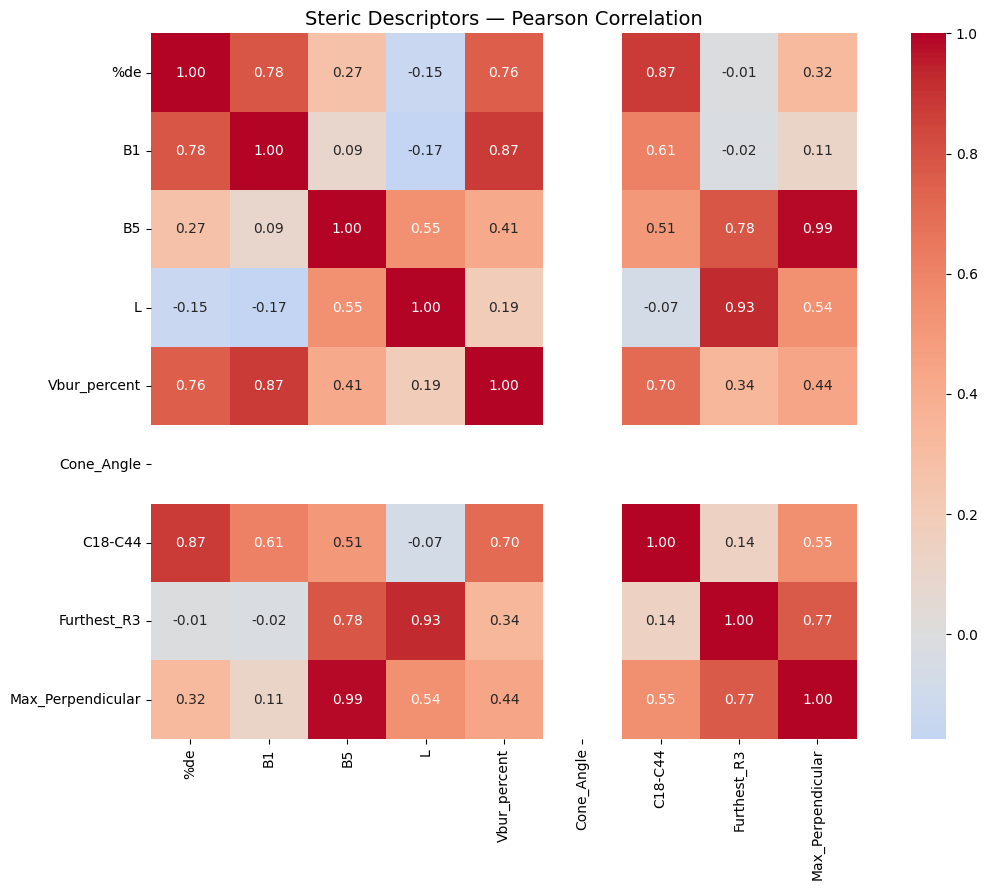

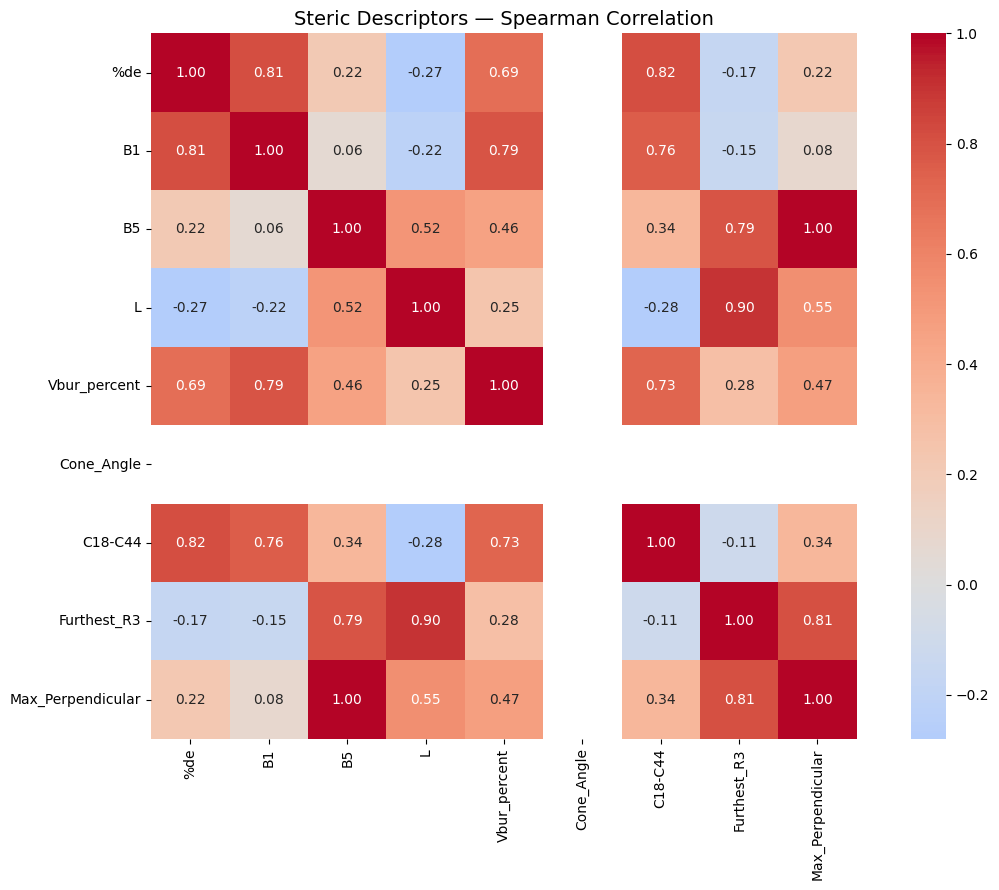

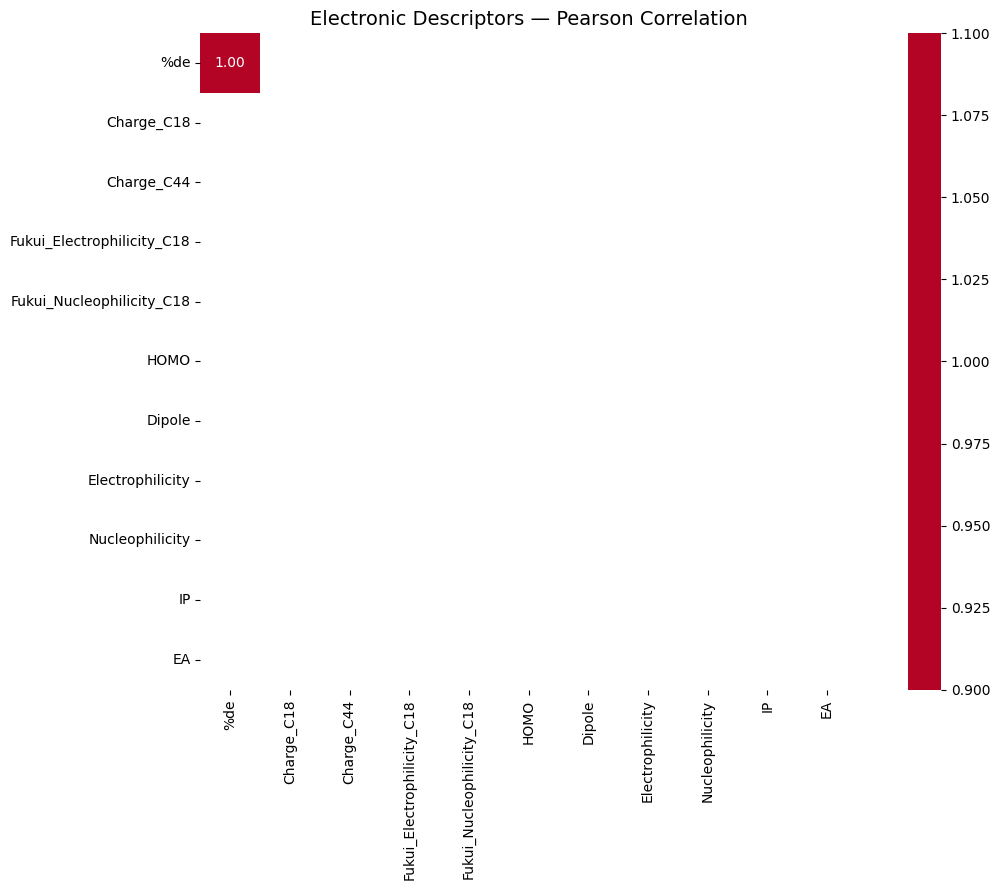

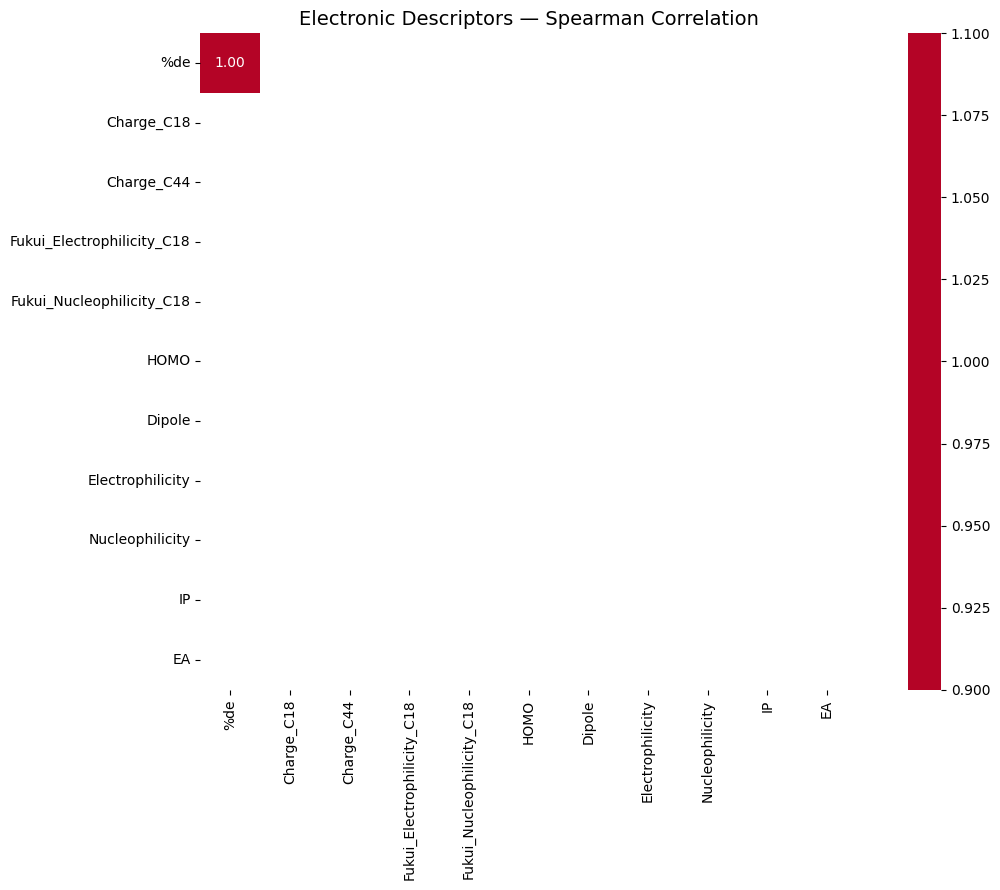

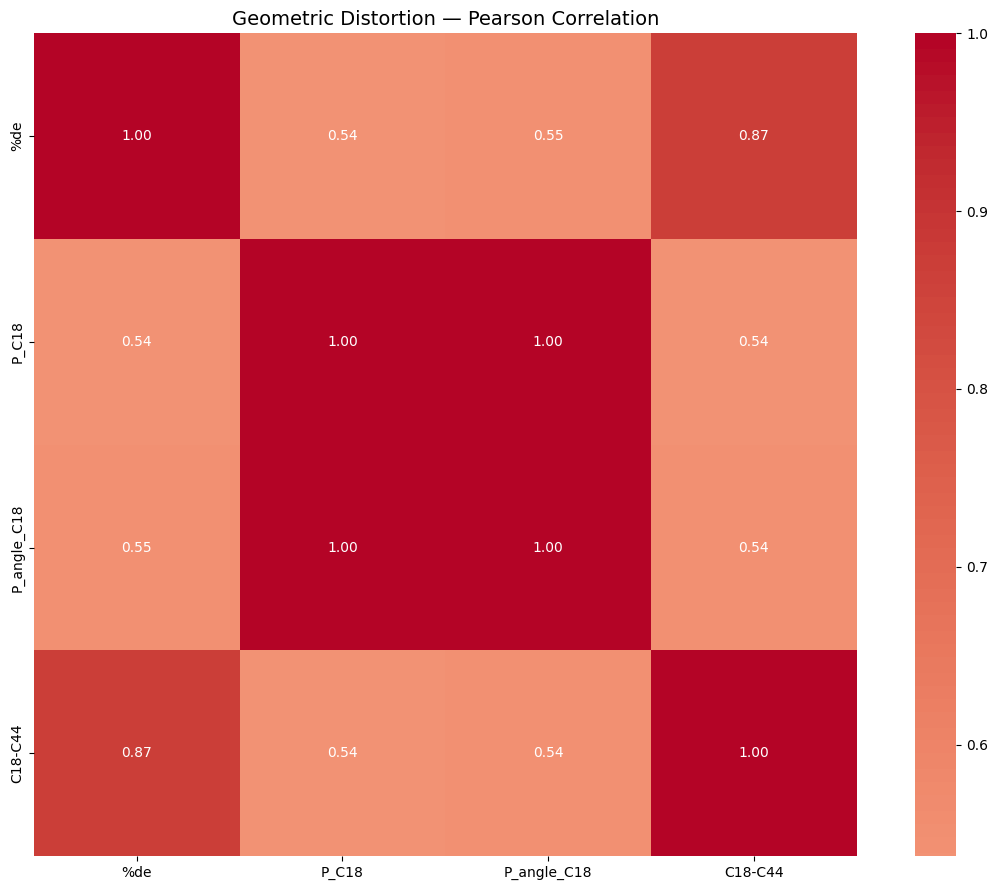

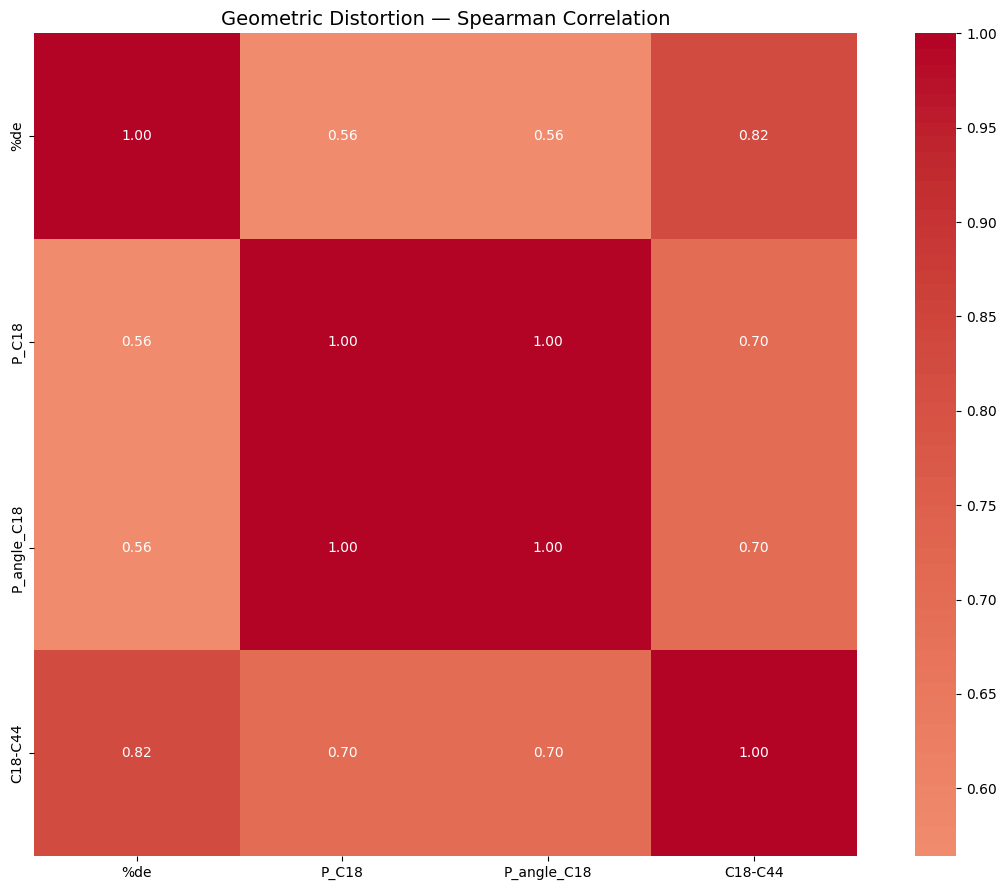

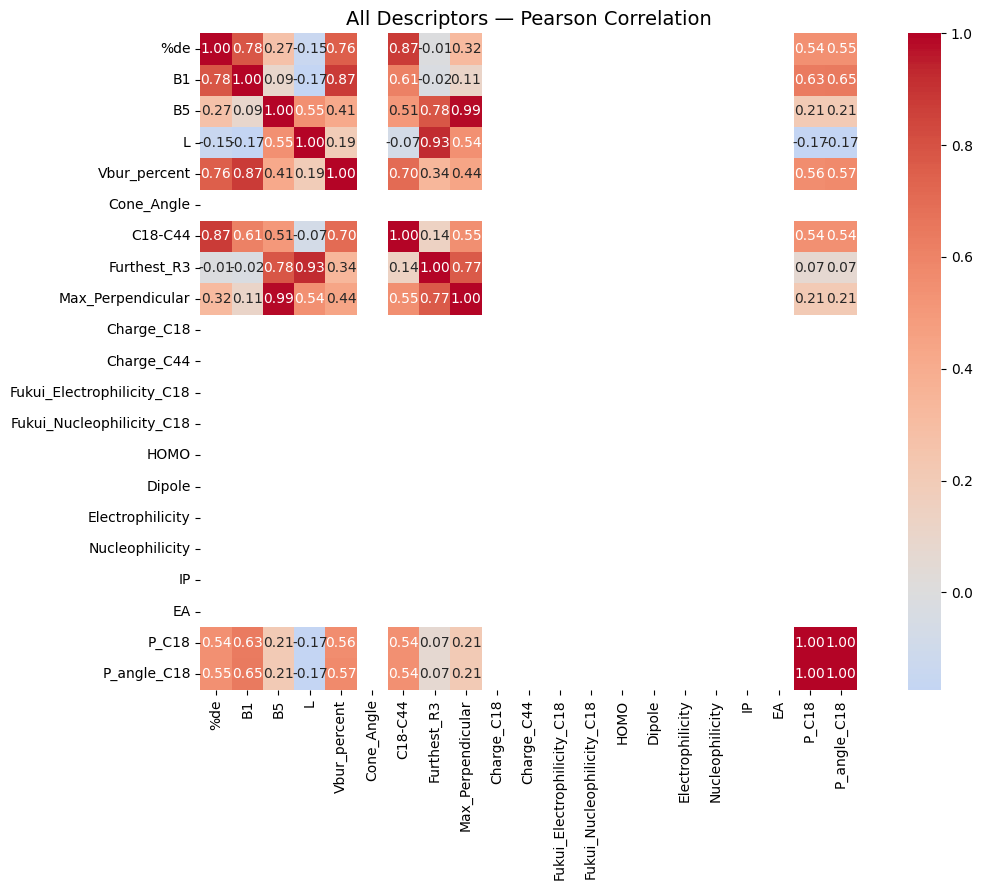

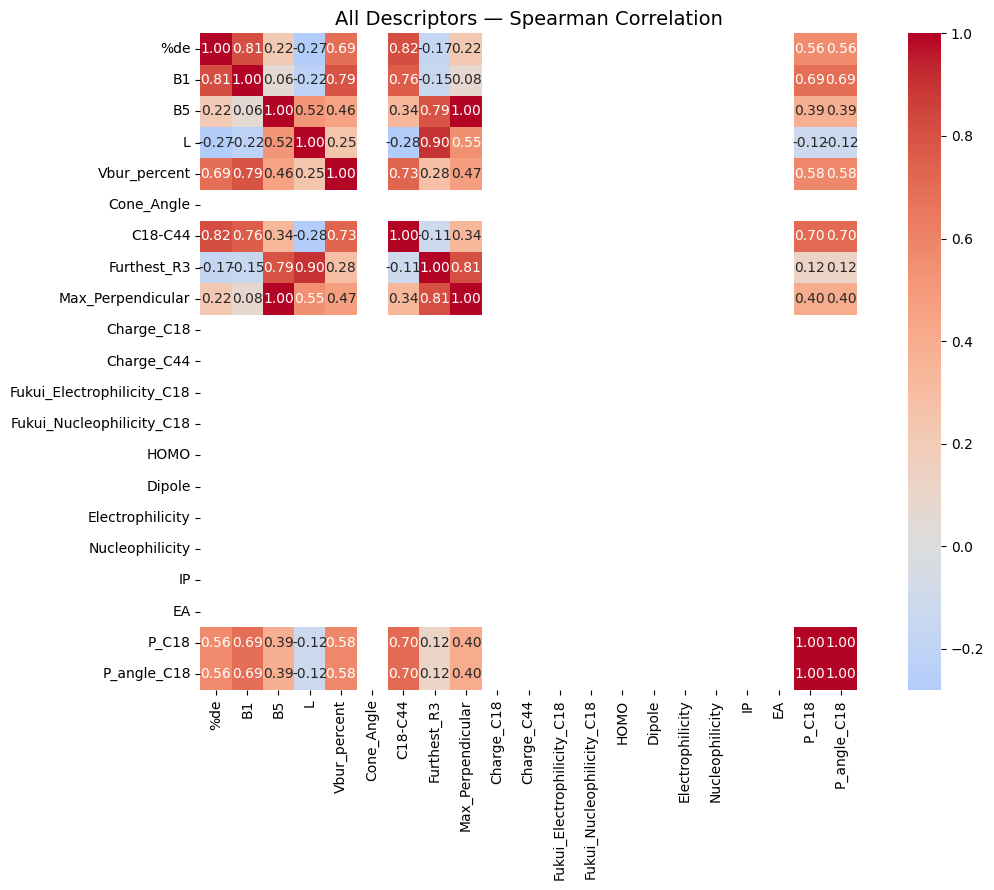

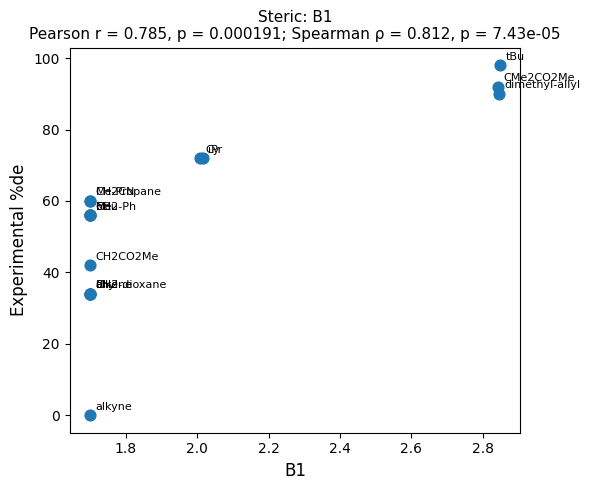

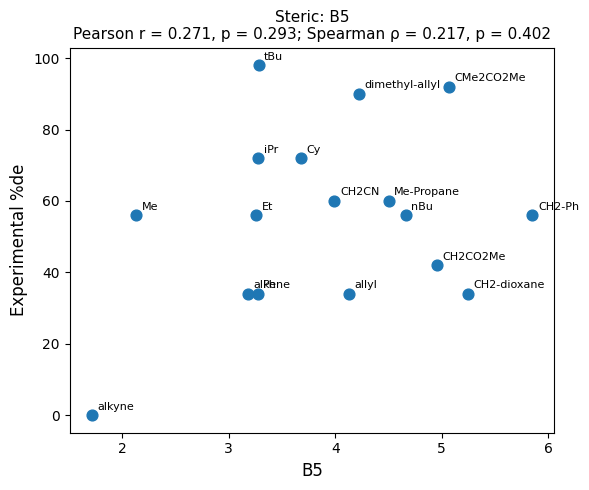

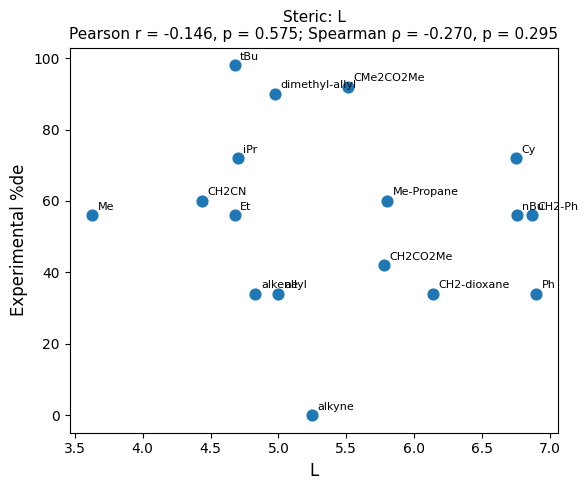

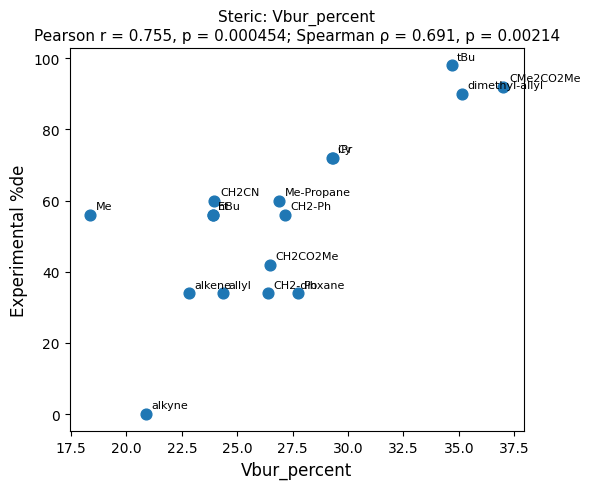

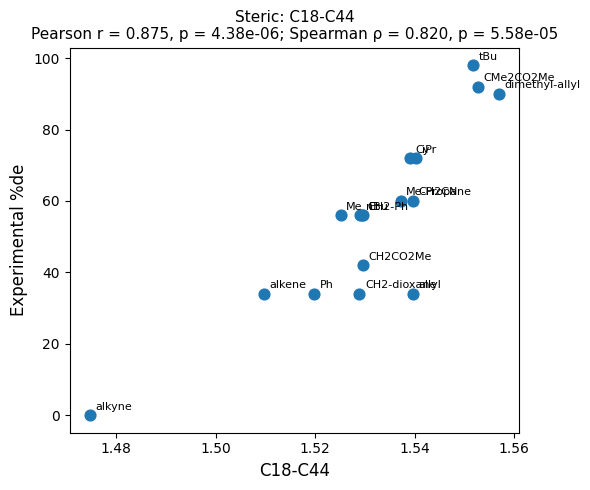

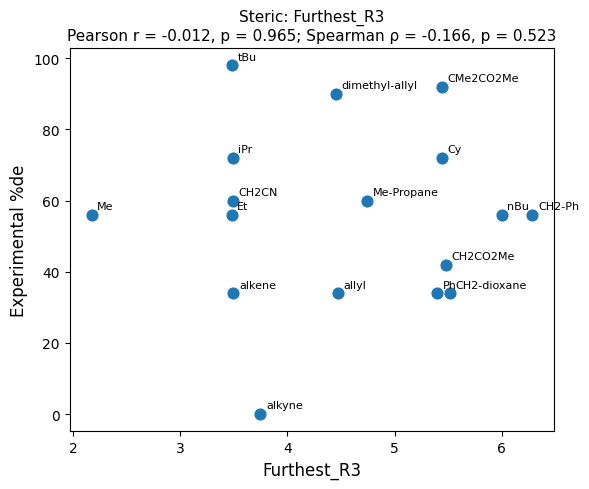

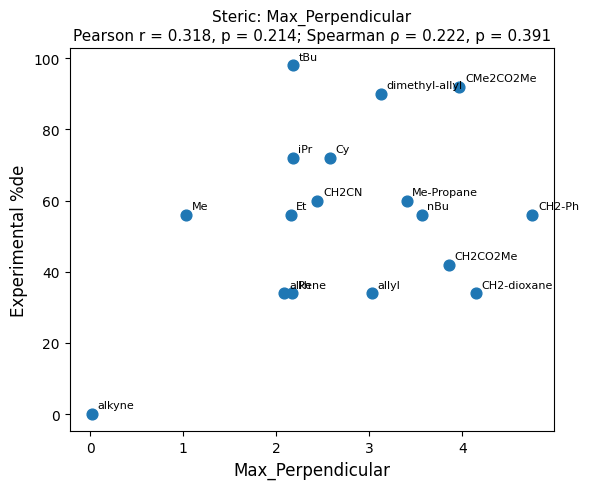

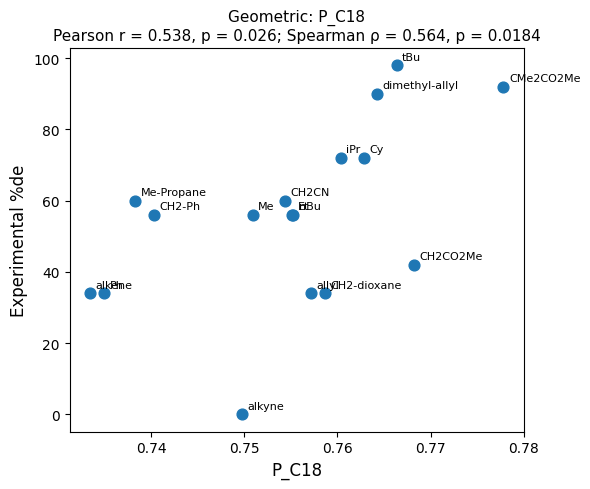

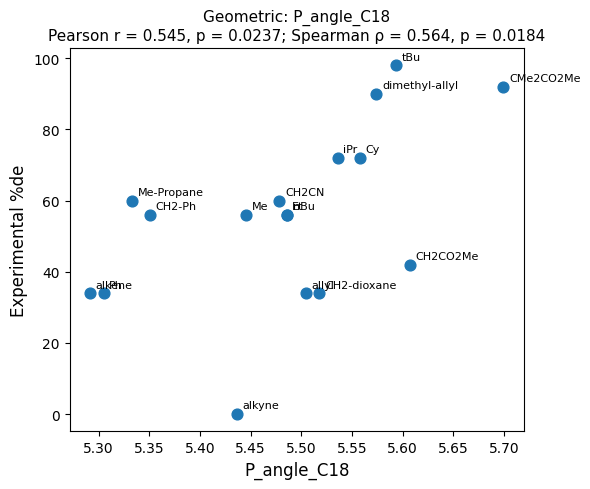

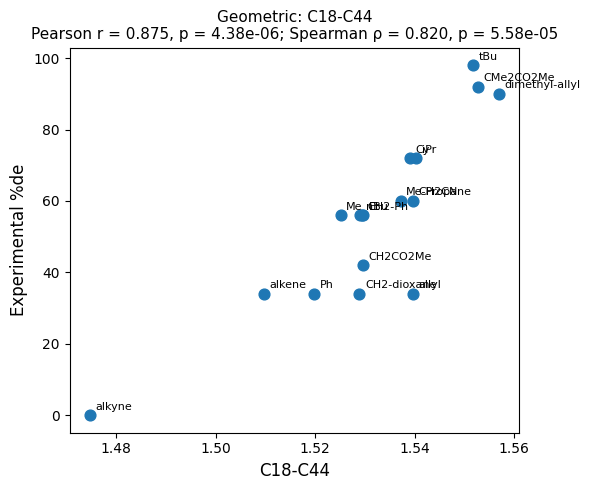



ANALYSIS COMPLETE

Excel file:
/content/drive/MyDrive/xyz_files/R3_CONTROL_Steric_Electronic_Geometric_Correlation.xlsx

Plot directory:
/content/drive/MyDrive/xyz_files/R3_Control_Correlation_Plots


Number of compounds: 17


Top descriptors by absolute Spearman correlation:


,Descriptor,Spearman_rho,Spearman_p,Pearson_r,Pearson_p
4,C18-C44,0.819952,0.000056,0.874606,0.000004
0,B1,0.812386,0.000074,0.784713,0.000191
3,Vbur_percent,0.690748,0.002140,0.755425,0.000454
7,P_C18,0.564028,0.018359,0.537773,0.025977
8,P_angle_C18,0.564028,0.018359,0.545073,0.023650
2,L,-0.269590,0.295368,-0.146219,0.575495
6,Max_Perpendicular,0.222381,0.390960,0.317698,0.214003
1,B5,0.217412,0.401903,0.270795,0.293132
5,Furthest_R3,-0.166475,0.523088,-0.011612,0.964719


In [11]:
# ============================================================
# R3 CONTROL ANALYSIS
# STERIC vs ELECTRONIC vs GEOMETRIC DISTORTION
#
# Target:
#   Experimental %de
#
# Descriptor groups:
#   1. Steric
#      - Sterimol B1
#      - Sterimol B5
#      - Sterimol L
#      - Custom C18-centered %Vbur
#      - Cone angle
#      - C18-C44 distance
#      - R3 maximum extent
#      - R3 maximum perpendicular width
#
#   2. Electronic
#      - XTB charge at C18
#      - XTB charge at C44
#      - XTB Fukui electrophilicity
#      - XTB Fukui nucleophilicity
#      - HOMO
#      - dipole
#      - electrophilicity
#      - nucleophilicity
#      - IP
#      - EA
#
#   3. Geometric distortion
#      - pyramidalization P at C18
#      - pyramidalization angle at C18
#      - C18-C44 bond distance
#
# Statistics:
#      - Pearson r
#      - Spearman rho
#
# Output:
#      - Excel workbook
#      - Pearson matrices
#      - Spearman matrices
#      - heatmaps
#      - individual correlation tables
# ============================================================


# ============================================================
# 1. INSTALL PACKAGES
# ============================================================

!pip -q install morfeus-ml pandas numpy scipy openpyxl matplotlib seaborn


# ============================================================
# 2. IMPORTS
# ============================================================

import os
import re
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from morfeus import (
    read_xyz,
    Sterimol,
    BuriedVolume,
    ConeAngle,
    Pyramidalization
)

# XTB is imported separately because availability can depend
# on the installed Morfeus version.
try:
    from morfeus import XTB
    XTB_AVAILABLE = True
except ImportError:
    XTB_AVAILABLE = False

warnings.filterwarnings("ignore")


# ============================================================
# 3. GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# 4. PATHS
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"

output_excel = os.path.join(
    xyz_folder,
    "R3_CONTROL_Steric_Electronic_Geometric_Correlation.xlsx"
)

output_dir = os.path.join(
    xyz_folder,
    "R3_Control_Correlation_Plots"
)

os.makedirs(output_dir, exist_ok=True)

print("XYZ folder:")
print(xyz_folder)

print("\nOutput folder:")
print(output_dir)


# ============================================================
# 5. FIXED ATOM NUMBERING
# ============================================================

# Your standardized numbering:
#
# DDQ       = 1–15
# Substrate = 16 onward
# C2        = C18
# H         = H43
# R3 starts = C44
#
# Therefore:

C18_ATOM = 18
R3_START_ATOM = 44


# ============================================================
# 6. EXPERIMENTAL %de DATA
# ============================================================

de_data = {

    "CH2-Ph": 56,
    "CH2-dioxane": 34,
    "CH2CN": 60,
    "CH2CO2Me": 42,
    "CMe2CO2Me": 92,
    "Cy": 72,
    "Et": 56,
    "Me-Propane": 60,
    "Me": 56,
    "Ph": 34,
    "alkene": 34,
    "alkyne": 0,
    "allyl": 34,
    "dimethyl-allyl": 90,
    "iPr": 72,
    "nBu": 56,
    "tBu": 98
}

de_df = pd.DataFrame(
    list(de_data.items()),
    columns=["R3", "%de"]
)

print(de_df)


# ============================================================
# 7. IDENTIFY XYZ FILES
# ============================================================

xyz_files = [
    f for f in os.listdir(xyz_folder)
    if f.lower().endswith(".xyz")
]

# Only RR files for comparison with experimental %de
rr_files = [
    f for f in xyz_files
    if f.startswith("RR_")
]

print(f"Total XYZ files: {len(xyz_files)}")
print(f"RR XYZ files:    {len(rr_files)}")


# ============================================================
# 8. FUNCTION TO CONVERT FILENAME → R3 NAME
# ============================================================

def filename_to_r3(filename):

    name = os.path.basename(filename)

    name = re.sub(r"^RR_", "", name)
    name = re.sub(r"\.xyz$", "", name, flags=re.I)

    return name


# ============================================================
# 9. GEOMETRY CHECK FUNCTIONS
# ============================================================

def geometry_checks(elements, coordinates):

    n_atoms = len(elements)

    if n_atoms < R3_START_ATOM:
        raise ValueError(
            f"Structure contains only {n_atoms} atoms; "
            f"R3 must start at atom {R3_START_ATOM_ATOM}."
        )

    # Convert to zero-based Python indexing
    c18 = coordinates[C18_ATOM - 1]
    c44 = coordinates[R3_START_ATOM - 1]

    # --------------------------------------------------------
    # C18-C44 distance
    # --------------------------------------------------------

    c18_c44 = np.linalg.norm(c44 - c18)

    # --------------------------------------------------------
    # R3 atoms
    # --------------------------------------------------------

    r3_indices = list(
        range(R3_START_ATOM - 1, n_atoms)
    )

    r3_coords = coordinates[r3_indices]

    # --------------------------------------------------------
    # C18 → C44 axis
    # --------------------------------------------------------

    axis_vector = c44 - c18
    axis_length = np.linalg.norm(axis_vector)

    if axis_length == 0:
        raise ValueError("C18-C44 distance is zero.")

    u = axis_vector / axis_length

    # --------------------------------------------------------
    # Distance of every R3 atom from C18
    # --------------------------------------------------------

    distances = np.linalg.norm(
        r3_coords - c18,
        axis=1
    )

    furthest_r3 = np.max(distances)

    # --------------------------------------------------------
    # Maximum perpendicular distance from C18-C44 axis
    # --------------------------------------------------------

    perpendicular_distances = []

    for r in r3_coords:

        vector = r - c18

        parallel_component = np.dot(vector, u) * u

        perpendicular_component = (
            vector - parallel_component
        )

        d_perp = np.linalg.norm(
            perpendicular_component
        )

        perpendicular_distances.append(d_perp)

    max_perpendicular = np.max(
        perpendicular_distances
    )

    return {
        "C18-C44": c18_c44,
        "Furthest_R3": furthest_r3,
        "Max_Perpendicular": max_perpendicular
    }


# ============================================================
# 10. STERIMOL
# ============================================================

def calculate_sterimol(elements, coordinates):

    n_atoms = len(elements)

    # Keep only:
    # C18 + R3 atoms 44 onward
    #
    # Everything else is excluded.

    keep_atoms = set(
        [C18_ATOM] +
        list(range(R3_START_ATOM, n_atoms + 1))
    )

    excluded_atoms = [
        i for i in range(1, n_atoms + 1)
        if i not in keep_atoms
    ]

    sterimol = Sterimol(
        elements,
        coordinates,
        dummy_index=C18_ATOM,
        attached_index=R3_START_ATOM,
        excluded_atoms=excluded_atoms,
        radii_type="crc",
        n_rot_vectors=3600
    )

    return {
        "B1": sterimol.B_1_value,
        "B5": sterimol.B_5_value,
        "L": sterimol.L_value
    }


# ============================================================
# 11. CUSTOM C18-CENTERED BURIED VOLUME
# ============================================================

def calculate_vbur(elements, coordinates):

    n_atoms = len(elements)

    keep_atoms = set(
        [C18_ATOM] +
        list(range(R3_START_ATOM, n_atoms + 1))
    )

    excluded_atoms = [
        i for i in range(1, n_atoms + 1)
        if i not in keep_atoms
    ]

    buried = BuriedVolume(
        elements,
        coordinates,
        metal_index=C18_ATOM,
        excluded_atoms=excluded_atoms,
        radius=3.5,
        include_hs=False,
        radii_type="bondi",
        radii_scale=1.17
    )

    # Current Morfeus API:
    percent_vbur = (
        buried.fraction_buried_volume * 100
    )

    return percent_vbur


# ============================================================
# 12. CONE ANGLE
# ============================================================

def calculate_cone_angle(elements, coordinates):

    n_atoms = len(elements)

    # --------------------------------------------------------
    # Create reduced C18 + R3 system
    # --------------------------------------------------------

    keep = (
        [C18_ATOM - 1] +
        list(range(R3_START_ATOM - 1, n_atoms))
    )

    reduced_elements = [
        elements[i] for i in keep
    ]

    reduced_coordinates = (
        coordinates[keep]
    )

    # Central atom becomes atom 1 in reduced system
    central_atom = 1

    try:

        cone = ConeAngle(
            reduced_elements,
            reduced_coordinates,
            central_atom,
            radii_type="crc",
            method="libconeangle"
        )

        angle = cone.cone_angle

        # Conventional cone angle should be 0–180 degrees.
        # If the library returns something outside this range,
        # flag it rather than using it blindly.

        if angle < 0 or angle > 180:

            print(
                f"WARNING: unusual cone angle = {angle:.2f}"
            )

        return angle

    except Exception as e:

        print(
            "Cone angle failed:",
            str(e)
        )

        return np.nan


# ============================================================
# 13. PYRAMIDALIZATION
# ============================================================

def calculate_pyramidalization(coordinates):

    try:

        pyr = Pyramidalization(
            coordinates,
            C18_ATOM
        )

        return {
            "P": pyr.P,
            "P_angle": pyr.P_angle
        }

    except Exception as e:

        print(
            "Pyramidalization failed:",
            str(e)
        )

        return {
            "P": np.nan,
            "P_angle": np.nan
        }


# ============================================================
# 14. XTB ELECTRONIC DESCRIPTORS
# ============================================================

def calculate_xtb(elements, coordinates):

    if not XTB_AVAILABLE:

        return {
            "Charge_C18": np.nan,
            "Charge_C44": np.nan,
            "Fukui_Electrophilicity_C18": np.nan,
            "Fukui_Nucleophilicity_C18": np.nan,
            "HOMO": np.nan,
            "Dipole": np.nan,
            "Electrophilicity": np.nan,
            "Nucleophilicity": np.nan,
            "IP": np.nan,
            "EA": np.nan
        }

    try:

        xtb = XTB(
            elements,
            coordinates
        )

        # ----------------------------------------------------
        # Charges
        # ----------------------------------------------------

        charges = xtb.get_charges()

        charge_c18 = charges[C18_ATOM - 1]
        charge_c44 = charges[R3_START_ATOM - 1]

        # ----------------------------------------------------
        # HOMO
        # ----------------------------------------------------

        try:
            homo = xtb.get_homo()
        except:
            homo = np.nan

        # ----------------------------------------------------
        # Dipole
        # ----------------------------------------------------

        try:
            dipole_value = xtb.get_dipole()

            # If vector is returned, convert to magnitude
            if np.ndim(dipole_value) > 0:
                dipole = np.linalg.norm(
                    np.asarray(dipole_value)
                )
            else:
                dipole = dipole_value

        except:
            dipole = np.nan

        # ----------------------------------------------------
        # IP
        # ----------------------------------------------------

        try:
            ip = xtb.get_ip()
        except:
            ip = np.nan

        # ----------------------------------------------------
        # EA
        # ----------------------------------------------------

        try:
            ea = xtb.get_ea()
        except:
            ea = np.nan

        # ----------------------------------------------------
        # Global electrophilicity
        # ----------------------------------------------------

        try:
            electrophilicity = (
                xtb.get_global_descriptor(
                    "electrophilicity"
                )
            )
        except:
            electrophilicity = np.nan

        # ----------------------------------------------------
        # Global nucleophilicity
        # ----------------------------------------------------

        try:
            nucleophilicity = (
                xtb.get_global_descriptor(
                    "nucleophilicity"
                )
            )
        except:
            nucleophilicity = np.nan

        # ----------------------------------------------------
        # Fukui electrophilicity
        # ----------------------------------------------------

        try:

            fukui_e = xtb.get_fukui(
                "electrophilicity"
            )

            fukui_e_c18 = (
                fukui_e[C18_ATOM - 1]
            )

        except:

            fukui_e_c18 = np.nan

        # ----------------------------------------------------
        # Fukui nucleophilicity
        # ----------------------------------------------------

        try:

            fukui_n = xtb.get_fukui(
                "nucleophilicity"
            )

            fukui_n_c18 = (
                fukui_n[C18_ATOM - 1]
            )

        except:

            fukui_n_c18 = np.nan

        return {

            "Charge_C18":
                charge_c18,

            "Charge_C44":
                charge_c44,

            "Fukui_Electrophilicity_C18":
                fukui_e_c18,

            "Fukui_Nucleophilicity_C18":
                fukui_n_c18,

            "HOMO":
                homo,

            "Dipole":
                dipole,

            "Electrophilicity":
                electrophilicity,

            "Nucleophilicity":
                nucleophilicity,

            "IP":
                ip,

            "EA":
                ea
        }

    except Exception as e:

        print(
            "XTB failed:",
            str(e)
        )

        return {

            "Charge_C18": np.nan,
            "Charge_C44": np.nan,

            "Fukui_Electrophilicity_C18":
                np.nan,

            "Fukui_Nucleophilicity_C18":
                np.nan,

            "HOMO": np.nan,
            "Dipole": np.nan,
            "Electrophilicity": np.nan,
            "Nucleophilicity": np.nan,
            "IP": np.nan,
            "EA": np.nan
        }


# ============================================================
# 15. PROCESS ALL RR STRUCTURES
# ============================================================

results = []

for filename in sorted(rr_files):

    filepath = os.path.join(
        xyz_folder,
        filename
    )

    print(
        "\nProcessing:",
        filename
    )

    try:

        # ----------------------------------------------------
        # Read XYZ
        # ----------------------------------------------------

        elements, coordinates = read_xyz(
            filepath
        )

        # ----------------------------------------------------
        # R3 name
        # ----------------------------------------------------

        r3_name = filename_to_r3(
            filename
        )

        # ----------------------------------------------------
        # Geometry
        # ----------------------------------------------------

        geom = geometry_checks(
            elements,
            coordinates
        )

        # ----------------------------------------------------
        # Sterimol
        # ----------------------------------------------------

        sterimol = calculate_sterimol(
            elements,
            coordinates
        )

        # ----------------------------------------------------
        # Buried volume
        # ----------------------------------------------------

        vbur = calculate_vbur(
            elements,
            coordinates
        )

        # ----------------------------------------------------
        # Cone angle
        # ----------------------------------------------------

        cone_angle = calculate_cone_angle(
            elements,
            coordinates
        )

        # ----------------------------------------------------
        # Pyramidalization
        # ----------------------------------------------------

        pyr = calculate_pyramidalization(
            coordinates
        )

        # ----------------------------------------------------
        # XTB
        # ----------------------------------------------------

        xtb = calculate_xtb(
            elements,
            coordinates
        )

        # ----------------------------------------------------
        # Combine
        # ----------------------------------------------------

        row = {

            "R3":
                r3_name,

            "%de":
                de_data.get(
                    r3_name,
                    np.nan
                ),

            "Filename":
                filename,

            # -----------------------------
            # STERIC
            # -----------------------------

            "B1":
                sterimol["B1"],

            "B5":
                sterimol["B5"],

            "L":
                sterimol["L"],

            "Vbur_percent":
                vbur,

            "Cone_Angle":
                cone_angle,

            "C18-C44":
                geom["C18-C44"],

            "Furthest_R3":
                geom["Furthest_R3"],

            "Max_Perpendicular":
                geom["Max_Perpendicular"],

            # -----------------------------
            # GEOMETRIC DISTORTION
            # -----------------------------

            "P_C18":
                pyr["P"],

            "P_angle_C18":
                pyr["P_angle"],

            # -----------------------------
            # ELECTRONIC
            # -----------------------------

            "Charge_C18":
                xtb["Charge_C18"],

            "Charge_C44":
                xtb["Charge_C44"],

            "Fukui_Electrophilicity_C18":
                xtb[
                    "Fukui_Electrophilicity_C18"
                ],

            "Fukui_Nucleophilicity_C18":
                xtb[
                    "Fukui_Nucleophilicity_C18"
                ],

            "HOMO":
                xtb["HOMO"],

            "Dipole":
                xtb["Dipole"],

            "Electrophilicity":
                xtb["Electrophilicity"],

            "Nucleophilicity":
                xtb["Nucleophilicity"],

            "IP":
                xtb["IP"],

            "EA":
                xtb["EA"]
        }

        results.append(row)

        print(
            "   R3:",
            r3_name
        )

    except Exception as e:

        print(
            "ERROR:",
            filename,
            str(e)
        )


# ============================================================
# 16. CREATE MASTER DATAFRAME
# ============================================================

df = pd.DataFrame(results)

# Keep only compounds for which experimental %de exists
df = df[
    df["%de"].notna()
].copy()

df = df.sort_values(
    "R3"
).reset_index(drop=True)

print("\nFinal dataset:")
display(df)


# ============================================================
# 17. DESCRIPTOR GROUPS
# ============================================================

steric_cols = [

    "B1",
    "B5",
    "L",
    "Vbur_percent",
    "Cone_Angle",
    "C18-C44",
    "Furthest_R3",
    "Max_Perpendicular"
]

electronic_cols = [

    "Charge_C18",
    "Charge_C44",
    "Fukui_Electrophilicity_C18",
    "Fukui_Nucleophilicity_C18",
    "HOMO",
    "Dipole",
    "Electrophilicity",
    "Nucleophilicity",
    "IP",
    "EA"
]

geometric_cols = [

    "P_C18",
    "P_angle_C18",
    "C18-C44"
]


# ============================================================
# 18. CORRELATION FUNCTION
# ============================================================

def correlation_table(
    dataframe,
    descriptor_columns,
    target="%de"
):

    records = []

    for col in descriptor_columns:

        if col not in dataframe.columns:
            continue

        temp = dataframe[
            [target, col]
        ].dropna()

        if len(temp) < 3:
            continue

        x = temp[col].values
        y = temp[target].values

        # Need variation in both variables
        if (
            np.std(x) == 0
            or
            np.std(y) == 0
        ):
            continue

        # Pearson
        r, p_pearson = pearsonr(
            x,
            y
        )

        # Spearman
        rho, p_spearman = spearmanr(
            x,
            y
        )

        records.append({

            "Descriptor":
                col,

            "N":
                len(temp),

            "Pearson_r":
                r,

            "Pearson_p":
                p_pearson,

            "Spearman_rho":
                rho,

            "Spearman_p":
                p_spearman
        })

    result = pd.DataFrame(
        records
    )

    if len(result) > 0:

        result["Abs_Spearman_rho"] = (
            result["Spearman_rho"].abs()
        )

        result = result.sort_values(
            "Abs_Spearman_rho",
            ascending=False
        )

    return result


# ============================================================
# 19. CALCULATE CORRELATIONS
# ============================================================

steric_corr = correlation_table(
    df,
    steric_cols
)

electronic_corr = correlation_table(
    df,
    electronic_cols
)

geometric_corr = correlation_table(
    df,
    geometric_cols
)

print("\n==============================")
print("STERIC CORRELATIONS")
print("==============================")

display(
    steric_corr
)

print("\n==============================")
print("ELECTRONIC CORRELATIONS")
print("==============================")

display(
    electronic_corr
)

print("\n==============================")
print("GEOMETRIC CORRELATIONS")
print("==============================")

display(
    geometric_corr
)


# ============================================================
# 20. COMPLETE CORRELATION TABLE
# ============================================================

all_descriptor_cols = list(
    dict.fromkeys(
        steric_cols
        + electronic_cols
        + geometric_cols
    )
)

all_corr = correlation_table(
    df,
    all_descriptor_cols
)

display(
    all_corr
)


# ============================================================
# 21. PEARSON CORRELATION MATRIX
# ============================================================

pearson_cols = [
    "%de"
] + all_descriptor_cols

pearson_matrix = df[
    pearson_cols
].corr(
    method="pearson"
)

print("\nPearson matrix:")
display(
    pearson_matrix
)


# ============================================================
# 22. SPEARMAN CORRELATION MATRIX
# ============================================================

spearman_matrix = df[
    pearson_cols
].corr(
    method="spearman"
)

print("\nSpearman matrix:")
display(
    spearman_matrix
)


# ============================================================
# 23. STERIC MATRICES
# ============================================================

steric_matrix_cols = [
    "%de"
] + [
    c for c in steric_cols
    if c in df.columns
]

steric_pearson = df[
    steric_matrix_cols
].corr(
    method="pearson"
)

steric_spearman = df[
    steric_matrix_cols
].corr(
    method="spearman"
)


# ============================================================
# 24. ELECTRONIC MATRICES
# ============================================================

electronic_matrix_cols = [
    "%de"
] + [
    c for c in electronic_cols
    if c in df.columns
]

electronic_pearson = df[
    electronic_matrix_cols
].corr(
    method="pearson"
)

electronic_spearman = df[
    electronic_matrix_cols
].corr(
    method="spearman"
)


# ============================================================
# 25. GEOMETRIC MATRICES
# ============================================================

geometric_matrix_cols = [
    "%de"
] + [
    c for c in geometric_cols
    if c in df.columns
]

geometric_pearson = df[
    geometric_matrix_cols
].corr(
    method="pearson"
)

geometric_spearman = df[
    geometric_matrix_cols
].corr(
    method="spearman"
)


# ============================================================
# 26. HEATMAP FUNCTION
# ============================================================

def make_heatmap(
    matrix,
    title,
    filename
):

    plt.figure(
        figsize=(12, 9)
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        square=True
    )

    plt.title(
        title,
        fontsize=14
    )

    plt.tight_layout()

    path = os.path.join(
        output_dir,
        filename
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 27. GENERATE HEATMAPS
# ============================================================

make_heatmap(
    steric_pearson,
    "Steric Descriptors — Pearson Correlation",
    "Steric_Pearson.png"
)

make_heatmap(
    steric_spearman,
    "Steric Descriptors — Spearman Correlation",
    "Steric_Spearman.png"
)

make_heatmap(
    electronic_pearson,
    "Electronic Descriptors — Pearson Correlation",
    "Electronic_Pearson.png"
)

make_heatmap(
    electronic_spearman,
    "Electronic Descriptors — Spearman Correlation",
    "Electronic_Spearman.png"
)

make_heatmap(
    geometric_pearson,
    "Geometric Distortion — Pearson Correlation",
    "Geometric_Pearson.png"
)

make_heatmap(
    geometric_spearman,
    "Geometric Distortion — Spearman Correlation",
    "Geometric_Spearman.png"
)

make_heatmap(
    pearson_matrix,
    "All Descriptors — Pearson Correlation",
    "ALL_Pearson.png"
)

make_heatmap(
    spearman_matrix,
    "All Descriptors — Spearman Correlation",
    "ALL_Spearman.png"
)


# ============================================================
# 28. INDIVIDUAL SCATTER PLOTS
# ============================================================

def scatter_correlation_plots(
    dataframe,
    descriptor_columns,
    group_name
):

    for col in descriptor_columns:

        if col not in dataframe.columns:
            continue

        temp = dataframe[
            ["%de", col]
        ].dropna()

        if len(temp) < 3:
            continue

        x = temp[col].values
        y = temp["%de"].values

        if np.std(x) == 0:
            continue

        r, p_r = pearsonr(
            x,
            y
        )

        rho, p_rho = spearmanr(
            x,
            y
        )

        plt.figure(
            figsize=(6, 5)
        )

        plt.scatter(
            x,
            y,
            s=60
        )

        plt.xlabel(
            col,
            fontsize=12
        )

        plt.ylabel(
            "Experimental %de",
            fontsize=12
        )

        plt.title(
            f"{group_name}: {col}\n"
            f"Pearson r = {r:.3f}, p = {p_r:.3g}; "
            f"Spearman ρ = {rho:.3f}, p = {p_rho:.3g}",
            fontsize=11
        )

        # Add compound labels
        for _, row in temp.iterrows():

            plt.annotate(
                dataframe.loc[
                    row.name,
                    "R3"
                ],
                (
                    row[col],
                    row["%de"]
                ),
                fontsize=8,
                xytext=(4, 4),
                textcoords="offset points"
            )

        plt.tight_layout()

        safe_name = re.sub(
            r"[^A-Za-z0-9_.-]+",
            "_",
            col
        )

        path = os.path.join(
            output_dir,
            f"{group_name}_{safe_name}.png"
        )

        plt.savefig(
            path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()


# ============================================================
# 29. MAKE SCATTER PLOTS
# ============================================================

scatter_correlation_plots(
    df,
    steric_cols,
    "Steric"
)

scatter_correlation_plots(
    df,
    electronic_cols,
    "Electronic"
)

scatter_correlation_plots(
    df,
    geometric_cols,
    "Geometric"
)


# ============================================================
# 30. SAVE EVERYTHING TO EXCEL
# ============================================================

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # Raw calculated data
    # --------------------------------------------------------

    df.to_excel(
        writer,
        sheet_name="All_Descriptors",
        index=False
    )

    # --------------------------------------------------------
    # Correlation tables
    # --------------------------------------------------------

    steric_corr.to_excel(
        writer,
        sheet_name="Steric_Correlation",
        index=False
    )

    electronic_corr.to_excel(
        writer,
        sheet_name="Electronic_Correlation",
        index=False
    )

    geometric_corr.to_excel(
        writer,
        sheet_name="Geometric_Correlation",
        index=False
    )

    all_corr.to_excel(
        writer,
        sheet_name="All_Correlation",
        index=False
    )

    # --------------------------------------------------------
    # Pearson matrices
    # --------------------------------------------------------

    pearson_matrix.to_excel(
        writer,
        sheet_name="Pearson_All"
    )

    steric_pearson.to_excel(
        writer,
        sheet_name="Pearson_Steric"
    )

    electronic_pearson.to_excel(
        writer,
        sheet_name="Pearson_Electronic"
    )

    geometric_pearson.to_excel(
        writer,
        sheet_name="Pearson_Geometric"
    )

    # --------------------------------------------------------
    # Spearman matrices
    # --------------------------------------------------------

    spearman_matrix.to_excel(
        writer,
        sheet_name="Spearman_All"
    )

    steric_spearman.to_excel(
        writer,
        sheet_name="Spearman_Steric"
    )

    electronic_spearman.to_excel(
        writer,
        sheet_name="Spearman_Electronic"
    )

    geometric_spearman.to_excel(
        writer,
        sheet_name="Spearman_Geometric"
    )


# ============================================================
# 31. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print(
    "\nExcel file:"
)
print(
    output_excel
)

print(
    "\nPlot directory:"
)
print(
    output_dir
)

print("\n")
print("Number of compounds:", len(df))

print("\n")
print("Top descriptors by absolute Spearman correlation:")
display(
    all_corr[
        [
            "Descriptor",
            "Spearman_rho",
            "Spearman_p",
            "Pearson_r",
            "Pearson_p"
        ]
    ].head(15)
)

In [12]:
# ============================================================
# AXIS-DEFINED R3 CONE ANGLE
#
# Definition for your system:
#
#   C18 = reference atom
#   C44 = R3 attachment / cone apex
#   R3  = atoms 45 through last atom
#
# Cone axis:
#       C18  --->  C44  --->  R3
#
# The cone contains the van der Waals spheres of all R3 atoms.
#
# Cone angle = 2 × maximum required half-angle
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd

from morfeus import read_xyz


# ============================================================
# 2. PATH
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"


# ============================================================
# 3. YOUR FIXED ATOM NUMBERING
# ============================================================

C18 = 18
C44 = 44


# ============================================================
# 4. VAN DER WAALS RADII
#
# Values in Å.
#
# These are used to calculate the tangent angle from C44
# to each R3 atom's vdW sphere.
# ============================================================

VDW_RADII = {

    "H": 1.20,
    "C": 1.70,
    "N": 1.55,
    "O": 1.52,
    "F": 1.47,
    "P": 1.80,
    "S": 1.80,
    "Cl": 1.75,
    "Br": 1.85,
    "I": 1.98,

}


# ============================================================
# 5. CALCULATE AXIS-DEFINED CONE ANGLE
# ============================================================

def calculate_r3_cone_angle(
    elements,
    coordinates,
    reference_atom=18,
    apex_atom=44,
    include_hydrogens=True
):

    n_atoms = len(elements)

    # --------------------------------------------------------
    # Convert to zero-based Python indices
    # --------------------------------------------------------

    ref_idx = reference_atom - 1
    apex_idx = apex_atom - 1

    # --------------------------------------------------------
    # Coordinates
    # --------------------------------------------------------

    r18 = np.asarray(
        coordinates[ref_idx],
        dtype=float
    )

    r44 = np.asarray(
        coordinates[apex_idx],
        dtype=float
    )

    # --------------------------------------------------------
    # Define axis:
    #
    # C18 ---> C44
    #
    # This points OUTWARD from substrate toward R3.
    # --------------------------------------------------------

    axis = r44 - r18

    axis_length = np.linalg.norm(axis)

    if axis_length < 1e-8:
        raise ValueError(
            "C18-C44 distance is zero."
        )

    u = axis / axis_length

    # --------------------------------------------------------
    # R3 = atoms AFTER C44
    #
    # C44 itself is the cone apex and is NOT included.
    # --------------------------------------------------------

    r3_atom_numbers = list(
        range(
            apex_atom + 1,
            n_atoms + 1
        )
    )

    if not include_hydrogens:

        r3_atom_numbers = [
            i
            for i in r3_atom_numbers
            if elements[i - 1] != "H"
        ]

    # --------------------------------------------------------
    # Store atom-level information
    # --------------------------------------------------------

    atom_results = []

    max_half_angle = -np.inf
    limiting_atom = None

    # --------------------------------------------------------
    # Loop over R3 atoms
    # --------------------------------------------------------

    for atom_number in r3_atom_numbers:

        element = elements[atom_number - 1]

        if element not in VDW_RADII:

            print(
                f"WARNING: no vdW radius for "
                f"{element} (atom {atom_number})"
            )

            continue

        radius = VDW_RADII[element]

        position = np.asarray(
            coordinates[atom_number - 1],
            dtype=float
        )

        # Vector from C44 to R3 atom
        v = position - r44

        d = np.linalg.norm(v)

        if d < 1e-8:

            print(
                f"WARNING: atom {atom_number} "
                f"is at cone apex."
            )

            continue

        # ----------------------------------------------------
        # Angle between C18→C44 axis and C44→atom vector
        # ----------------------------------------------------

        cos_theta = np.dot(
            u,
            v
        ) / d

        # Numerical protection
        cos_theta = np.clip(
            cos_theta,
            -1.0,
            1.0
        )

        theta = np.degrees(
            np.arccos(cos_theta)
        )

        # ----------------------------------------------------
        # Tangent angular radius of the vdW sphere
        #
        # alpha = asin(r / d)
        #
        # This is the angular radius of the sphere as seen
        # from the cone apex.
        # ----------------------------------------------------

        if radius >= d:

            alpha = 90.0

            print(
                f"WARNING: vdW radius >= distance "
                f"for atom {atom_number}"
            )

        else:

            alpha = np.degrees(
                np.arcsin(
                    radius / d
                )
            )

        # ----------------------------------------------------
        # Required half-angle for this atom
        #
        # The cone must extend from the axis by:
        #
        # theta + alpha
        #
        # to completely contain the vdW sphere.
        # ----------------------------------------------------

        required_half_angle = (
            theta + alpha
        )

        # ----------------------------------------------------
        # Projection along the C18→C44 axis
        # ----------------------------------------------------

        axial_projection = np.dot(
            v,
            u
        )

        # ----------------------------------------------------
        # Perpendicular distance
        # ----------------------------------------------------

        perpendicular_vector = (
            v
            - axial_projection * u
        )

        perpendicular_distance = np.linalg.norm(
            perpendicular_vector
        )

        # ----------------------------------------------------
        # Save atom information
        # ----------------------------------------------------

        atom_results.append({

            "Atom": atom_number,

            "Element": element,

            "Distance_from_C44":
                d,

            "Axial_projection":
                axial_projection,

            "Perpendicular_distance":
                perpendicular_distance,

            "Theta_deg":
                theta,

            "vdW_radius":
                radius,

            "vdW_angular_radius_deg":
                alpha,

            "Required_half_angle_deg":
                required_half_angle
        })

        # ----------------------------------------------------
        # Find limiting atom
        # ----------------------------------------------------

        if required_half_angle > max_half_angle:

            max_half_angle = (
                required_half_angle
            )

            limiting_atom = atom_number

    # ========================================================
    # FULL CONE ANGLE
    # ========================================================

    cone_angle = (
        2.0 * max_half_angle
    )

    # ========================================================
    # RETURN
    # ========================================================

    atom_df = pd.DataFrame(
        atom_results
    )

    return {

        "Cone_Angle": cone_angle,

        "Half_Cone_Angle":
            max_half_angle,

        "Limiting_Atom":
            limiting_atom,

        "C18_C44_Distance":
            axis_length,

        "Atom_Data":
            atom_df
    }


# ============================================================
# 6. TEST ON ONE STRUCTURE
# ============================================================

test_file = os.path.join(
    xyz_folder,
    "RR_CH2-Ph.xyz"
)

elements, coordinates = read_xyz(
    test_file
)


result = calculate_r3_cone_angle(
    elements,
    coordinates,
    reference_atom=18,
    apex_atom=44,
    include_hydrogens=True
)


print("=" * 60)
print("R3 AXIS-DEFINED CONE ANGLE")
print("=" * 60)

print(
    f"C18 → C44 distance: "
    f"{result['C18_C44_Distance']:.3f} Å"
)

print(
    f"Half cone angle: "
    f"{result['Half_Cone_Angle']:.2f}°"
)

print(
    f"FULL cone angle: "
    f"{result['Cone_Angle']:.2f}°"
)

print(
    f"Limiting atom: "
    f"{result['Limiting_Atom']}"
)

print("\nAtom-level information:")

display(
    result["Atom_Data"]
)


# ============================================================
# 7. ALSO CALCULATE WITHOUT HYDROGENS
#
# This is useful as a diagnostic.
# ============================================================

result_heavy = calculate_r3_cone_angle(
    elements,
    coordinates,
    reference_atom=18,
    apex_atom=44,
    include_hydrogens=False
)

print("\n")
print("=" * 60)
print("HEAVY-ATOM-ONLY CONE ANGLE")
print("=" * 60)

print(
    f"Cone angle: "
    f"{result_heavy['Cone_Angle']:.2f}°"
)

print(
    f"Limiting atom: "
    f"{result_heavy['Limiting_Atom']}"
)

R3 AXIS-DEFINED CONE ANGLE
C18 → C44 distance: 1.529 Å
Half cone angle: 162.90°
FULL cone angle: 325.79°
Limiting atom: 46

Atom-level information:


,Atom,Element,Distance_from_C44,Axial_projection,Perpendicular_distance,Theta_deg,vdW_radius,vdW_angular_radius_deg,Required_half_angle_deg
0,45,H,1.096399,0.350105,1.038998,71.378054,1.2,90.000000,161.378054
1,46,H,1.097464,0.322748,1.048933,72.897301,1.2,90.000000,162.897301
2,47,C,1.515195,0.675967,1.356055,63.504634,1.7,90.000000,153.504634
3,48,C,2.565047,-0.018266,2.564981,90.408023,1.7,41.510402,131.918425
4,49,C,2.500620,2.071852,1.400189,34.051419,1.7,42.830470,76.881889
5,50,C,3.837794,0.669418,3.778961,79.954646,1.7,26.293070,106.247716
6,51,H,2.809496,-1.098359,2.585900,113.013316,1.2,25.285105,138.298421
7,52,C,3.795507,2.758042,2.607504,43.392903,1.7,26.608904,70.001807
8,53,H,2.670271,2.623570,0.497219,10.731430,1.2,26.704723,37.436153
9,54,C,4.325517,2.055128,3.806119,61.633009,1.7,23.142334,84.775343




HEAVY-ATOM-ONLY CONE ANGLE
Cone angle: 307.01°
Limiting atom: 47


In [13]:
# ============================================================
# CALCULATE R3 CONE ANGLE FOR ALL RR XYZ FILES
# ============================================================

# ============================================================
# EXPERIMENTAL %de DATA (copied from an earlier cell for scope)
# ============================================================
de_data = {

    "CH2-Ph": 56,
    "CH2-dioxane": 34,
    "CH2CN": 60,
    "CH2CO2Me": 42,
    "CMe2CO2Me": 92,
    "Cy": 72,
    "Et": 56,
    "Me-Propane": 60,
    "Me": 56,
    "Ph": 34,
    "alkene": 34,
    "alkyne": 0,
    "allyl": 34,
    "dimethyl-allyl": 90,
    "iPr": 72,
    "nBu": 56,
    "tBu": 98
}

rr_files = sorted([
    f
    for f in os.listdir(xyz_folder)
    if f.startswith("RR_")
    and f.lower().endswith(".xyz")
])


cone_results = []


for filename in rr_files:

    filepath = os.path.join(
        xyz_folder,
        filename
    )

    print(
        "Processing:",
        filename
    )

    try:

        elements, coordinates = read_xyz(
            filepath
        )

        result = calculate_r3_cone_angle(
            elements,
            coordinates,
            reference_atom=18,
            apex_atom=44,
            include_hydrogens=True
        )

        # -----------------------------------------------
        # R3 name
        # -----------------------------------------------

        r3_name = filename

        if r3_name.startswith("RR_"):
            r3_name = r3_name[3:]

        if r3_name.lower().endswith(".xyz"):
            r3_name = r3_name[:-4]

        # -----------------------------------------------
        # Experimental %de
        # -----------------------------------------------

        de = de_data.get(
            r3_name,
            np.nan
        )

        cone_results.append({

            "R3":
                r3_name,

            "%de":
                de,

            "Filename":
                filename,

            "Cone_Angle":
                result["Cone_Angle"],

            "Half_Cone_Angle":
                result["Half_Cone_Angle"],

            "Limiting_Atom":
                result["Limiting_Atom"],

            "C18-C44":
                result["C18_C44_Distance"]
        })

    except Exception as e:

        print(
            "ERROR:",
            filename,
            e
        )


cone_df = pd.DataFrame(
    cone_results
)

cone_df = cone_df.sort_values(
    "R3"
).reset_index(drop=True)


print("\n")
print("=" * 70)
print("FINAL R3 CONE ANGLES")
print("=" * 70)

display(
    cone_df
)

Processing: RR_CH2-Ph.xyz
Processing: RR_CH2-dioxane.xyz
Processing: RR_CH2CN.xyz
Processing: RR_CH2CO2Me.xyz
Processing: RR_CMe2CO2Me.xyz
Processing: RR_Cy.xyz
Processing: RR_Et.xyz
Processing: RR_Me-Propane.xyz
Processing: RR_Me.xyz
Processing: RR_Ph.xyz
Processing: RR_alkene.xyz
Processing: RR_alkyne.xyz
Processing: RR_allyl.xyz
Processing: RR_dimethyl-allyl.xyz
Processing: RR_iPr.xyz
Processing: RR_nBu.xyz
Processing: RR_tBu.xyz


FINAL R3 CONE ANGLES


,R3,%de,Filename,Cone_Angle,Half_Cone_Angle,Limiting_Atom,C18-C44
0,CH2-Ph,56,RR_CH2-Ph.xyz,325.794603,162.897301,46,1.529416
1,CH2-dioxane,34,RR_CH2-dioxane.xyz,321.733742,160.866871,46,1.528873
2,CH2CN,60,RR_CH2CN.xyz,321.573965,160.786983,46,1.539665
3,CH2CO2Me,42,RR_CH2CO2Me.xyz,321.891106,160.945553,47,1.529564
4,CMe2CO2Me,92,RR_CMe2CO2Me.xyz,330.412414,165.206207,45,1.552641
5,Cy,72,RR_Cy.xyz,325.601324,162.800662,47,1.539015
6,Et,56,RR_Et.xyz,323.960445,161.980223,46,1.529597
7,Me,56,RR_Me.xyz,320.731282,160.365641,46,1.525097
8,Me-Propane,60,RR_Me-Propane.xyz,324.953488,162.476744,46,1.537140
9,Ph,34,RR_Ph.xyz,300.329967,150.164984,45,1.519774


In [14]:
# ============================================================
# R3 AXIS-DEFINED GEOMETRIC CONE ANGLE
#
# YOUR ATOM NUMBERING:
#
# C18 = substrate C2
# C44 = first carbon of R3 / attachment atom
# C45...N = remaining R3 atoms
#
# AXIS:
#
# C18  ---------------->  C44
#                             \
#                              R3
#
# Definition:
#   angle between C18->C44 axis and C44->R3 atom vectors
#
# Full cone angle = 2 × maximum half-angle
#
# IMPORTANT:
#   This is a GEOMETRIC cone angle.
#   It is NOT the conventional Tolman cone angle.
# ============================================================

import numpy as np
import pandas as pd
from morfeus import read_xyz


C18 = 18
C44 = 44


def calculate_r3_geometric_cone_angle(
    elements,
    coordinates,
    reference_atom=18,
    apex_atom=44,
    include_hydrogens=True
):

    n_atoms = len(elements)

    # --------------------------------------------------------
    # Coordinates
    # --------------------------------------------------------

    r18 = np.asarray(
        coordinates[reference_atom - 1],
        dtype=float
    )

    r44 = np.asarray(
        coordinates[apex_atom - 1],
        dtype=float
    )

    # --------------------------------------------------------
    # Define C18 -> C44 axis
    # --------------------------------------------------------

    axis = r44 - r18

    axis_length = np.linalg.norm(axis)

    if axis_length < 1e-8:
        raise ValueError(
            "C18-C44 distance is zero."
        )

    u = axis / axis_length

    # --------------------------------------------------------
    # R3 atoms
    #
    # IMPORTANT:
    # C44 itself is NOT included.
    #
    # R3 atoms = 45 ... last atom
    # --------------------------------------------------------

    r3_atom_numbers = list(
        range(
            apex_atom + 1,
            n_atoms + 1
        )
    )

    if not include_hydrogens:

        r3_atom_numbers = [
            i for i in r3_atom_numbers
            if elements[i - 1] != "H"
        ]

    # --------------------------------------------------------
    # Calculate angular distribution
    # --------------------------------------------------------

    atom_results = []

    max_angle = -np.inf
    limiting_atom = None

    for atom_number in r3_atom_numbers:

        element = elements[
            atom_number - 1
        ]

        r = np.asarray(
            coordinates[atom_number - 1],
            dtype=float
        )

        # Vector C44 -> R3 atom
        v = r - r44

        distance = np.linalg.norm(v)

        if distance < 1e-8:
            continue

        # ----------------------------------------------------
        # Angle between:
        #
        # C18 -> C44
        #
        # and
        #
        # C44 -> R3 atom
        # ----------------------------------------------------

        cos_theta = np.dot(
            u,
            v
        ) / distance

        cos_theta = np.clip(
            cos_theta,
            -1.0,
            1.0
        )

        theta = np.degrees(
            np.arccos(cos_theta)
        )

        # ----------------------------------------------------
        # Axial and perpendicular components
        # ----------------------------------------------------

        axial = np.dot(
            v,
            u
        )

        perpendicular_vector = (
            v - axial * u
        )

        perpendicular = np.linalg.norm(
            perpendicular_vector
        )

        atom_results.append({

            "Atom": atom_number,

            "Element": element,

            "C44_to_atom_distance":
                distance,

            "Axial_projection":
                axial,

            "Perpendicular_distance":
                perpendicular,

            "Angle_from_C18_C44_axis":
                theta
        })

        # ----------------------------------------------------
        # Find largest angular deviation
        # ----------------------------------------------------

        if theta > max_angle:

            max_angle = theta

            limiting_atom = atom_number

    # --------------------------------------------------------
    # FULL CONE ANGLE
    # --------------------------------------------------------

    full_cone_angle = 2.0 * max_angle

    # --------------------------------------------------------
    # DataFrame
    # --------------------------------------------------------

    atom_df = pd.DataFrame(
        atom_results
    )

    return {

        "Cone_Angle":
            full_cone_angle,

        "Half_Cone_Angle":
            max_angle,

        "Limiting_Atom":
            limiting_atom,

        "C18-C44":
            axis_length,

        "Atom_Data":
            atom_df
    }

In [15]:
# ============================================================
# TEST
# ============================================================

xyz_file = os.path.join(
    xyz_folder,
    "RR_CH2-Ph.xyz"
)

elements, coordinates = read_xyz(
    xyz_file
)

result = calculate_r3_geometric_cone_angle(
    elements,
    coordinates,
    reference_atom=18,
    apex_atom=44,
    include_hydrogens=True
)

print("=" * 60)
print("R3 GEOMETRIC CONE ANGLE")
print("=" * 60)

print(
    f"C18-C44 distance : "
    f"{result['C18-C44']:.3f} Å"
)

print(
    f"Half cone angle  : "
    f"{result['Half_Cone_Angle']:.2f}°"
)

print(
    f"FULL cone angle  : "
    f"{result['Cone_Angle']:.2f}°"
)

print(
    f"Limiting atom    : "
    f"{result['Limiting_Atom']}"
)

print("\nAtom-level data:")

display(
    result["Atom_Data"].sort_values(
        "Angle_from_C18_C44_axis",
        ascending=False
    )
)

R3 GEOMETRIC CONE ANGLE
C18-C44 distance : 1.529 Å
Half cone angle  : 113.01°
FULL cone angle  : 226.03°
Limiting atom    : 51

Atom-level data:


,Atom,Element,C44_to_atom_distance,Axial_projection,Perpendicular_distance,Angle_from_C18_C44_axis
6,51,H,2.809496,-1.098359,2.585900,113.013316
3,48,C,2.565047,-0.018266,2.564981,90.408023
10,55,H,4.709891,0.110901,4.708585,88.650768
5,50,C,3.837794,0.669418,3.778961,79.954646
1,46,H,1.097464,0.322748,1.048933,72.897301
0,45,H,1.096399,0.350105,1.038998,71.378054
2,47,C,1.515195,0.675967,1.356055,63.504634
9,54,C,4.325517,2.055128,3.806119,61.633009
12,57,H,5.410684,2.585565,4.752931,61.454089
7,52,C,3.795507,2.758042,2.607504,43.392903


In [16]:
# ============================================================
# XTB DIAGNOSTIC
# ============================================================

import numpy as np
import morfeus

print("Morfeus version:", getattr(morfeus, "__version__", "unknown"))

try:
    from morfeus import XTB
    print("✓ Morfeus XTB imported successfully")
except Exception as e:
    print("✗ Morfeus XTB import FAILED")
    print(type(e).__name__, ":", e)

try:
    import xtb
    print("✓ xtb imported successfully")
    print("xtb version:", getattr(xtb, "__version__", "unknown"))
except Exception as e:
    print("✗ xtb import FAILED")
    print(type(e).__name__, ":", e)

Morfeus version: 0.8.0
✓ Morfeus XTB imported successfully
✗ xtb import FAILED
ModuleNotFoundError : No module named 'xtb'


In [17]:
!pip install xtb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 727.0 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [18]:
import sys
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


In [19]:
!pip uninstall -y xtb
!pip install -q condacolab

In [20]:
!pip install -q condacolab

In [21]:
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:19
🔁 Restarting kernel...


In [22]:
!conda install -y -c conda-forge xtb-python

Retrieving notices: - \ | done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: \ | / done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - xtb-python


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _python_abi3_support-1.0   |       hd8ed1ab_3           8 KB  conda-forge
    annotated-types-0.8.0      |     pyhd8ed1ab_0          19 KB  conda-forge
    anyio-4.15.0               |     pyh5ded981_0         171 KB  conda-forge
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    cached-property-2.0.1      |     pyhcf101f3_0           4 KB  conda-forge
    cached_property-2.0.1      |     pyhcf101f3_0          16 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
    colorama-0.4.6             |     pyhd8ed1ab_1          26 KB  conda-forge
    conda-26

In [23]:
import xtb

print("XTB imported successfully!")
print("XTB version:", getattr(xtb, "__version__", "unknown"))

XTB imported successfully!
XTB version: 20.2


In [1]:
from morfeus import XTB, read_xyz

test_file = "/content/drive/MyDrive/xyz_files/RR_Me.xyz"

elements, coordinates = read_xyz(test_file)

print("Number of atoms:", len(elements))

xtb_test = XTB(elements, coordinates)

print("HOMO:", xtb_test.get_homo())
print("LUMO:", xtb_test.get_lumo())
print("Dipole:", xtb_test.get_dipole())
print("IP:", xtb_test.get_ip())
print("EA:", xtb_test.get_ea())

charges = xtb_test.get_charges()

print("C18 charge:", charges[17])
print("C44 charge:", charges[43])
print("C22 charge:", charges[21])

Number of atoms: 47
HOMO: -0.3572649
LUMO: -0.3491235
Dipole: [-2.83863008  2.064422   -2.99976855]
IP: 7.1019
EA: 2.4719
C18 charge: -0.41792643
C44 charge: 0.03537274
C22 charge: -0.02508282


In [2]:
# ============================================================
# 19. XTB ELECTRONIC DESCRIPTORS
# ============================================================
#
# XTB is now installed and tested successfully.
#
# This section calculates:
#   - XTB Energy
#   - HOMO
#   - LUMO
#   - HOMO-LUMO gap
#   - Dipole moment
#   - IP
#   - EA
#   - Electrophilicity
#   - Nucleophilicity
#   - Atomic charges at C18, C44, C22
#
# ============================================================

def calculate_xtb_descriptors(
    elements,
    coordinates
):

    # --------------------------------------------------------
    # Run XTB
    # --------------------------------------------------------

    xtb = XTB(
        elements,
        coordinates
    )

    # --------------------------------------------------------
    # Energy
    # --------------------------------------------------------

    try:
        xtb_energy = xtb.get_energy()
    except Exception:
        xtb_energy = np.nan

    # --------------------------------------------------------
    # HOMO
    # --------------------------------------------------------

    try:
        homo = xtb.get_homo()
    except Exception:
        homo = np.nan

    # --------------------------------------------------------
    # LUMO
    # --------------------------------------------------------

    try:
        lumo = xtb.get_lumo()
    except Exception:
        lumo = np.nan

    # --------------------------------------------------------
    # HOMO-LUMO gap
    # --------------------------------------------------------

    if (
        not np.isnan(homo)
        and
        not np.isnan(lumo)
    ):
        gap = lumo - homo
    else:
        gap = np.nan

    # --------------------------------------------------------
    # Dipole
    # --------------------------------------------------------

    try:

        dipole = xtb.get_dipole()

        dipole = np.asarray(
            dipole,
            dtype=float
        )

        if dipole.ndim == 0:

            dipole_magnitude = float(
                dipole
            )

        else:

            dipole_magnitude = np.linalg.norm(
                dipole
            )

    except Exception:

        dipole_magnitude = np.nan

    # --------------------------------------------------------
    # Ionization potential
    # --------------------------------------------------------

    try:
        ip = xtb.get_ip()
    except Exception:
        ip = np.nan

    # --------------------------------------------------------
    # Electron affinity
    # --------------------------------------------------------

    try:
        ea = xtb.get_ea()
    except Exception:
        ea = np.nan

    # --------------------------------------------------------
    # Electrophilicity
    # --------------------------------------------------------
    #
    # μ = (HOMO + LUMO) / 2
    # η = (LUMO - HOMO) / 2
    # ω = μ² / (2η)
    #
    # --------------------------------------------------------

    if (
        not np.isnan(homo)
        and
        not np.isnan(lumo)
        and
        (lumo - homo) != 0
    ):

        mu = (
            homo + lumo
        ) / 2.0

        eta = (
            lumo - homo
        ) / 2.0

        electrophilicity = (
            mu ** 2
        ) / (
            2.0 * eta
        )

    else:

        electrophilicity = np.nan

    # --------------------------------------------------------
    # Nucleophilicity
    # --------------------------------------------------------
    #
    # Simple HOMO-based index:
    # N = -HOMO
    #
    # --------------------------------------------------------

    if not np.isnan(homo):

        nucleophilicity = -homo

    else:

        nucleophilicity = np.nan

    # --------------------------------------------------------
    # Atomic charges
    # --------------------------------------------------------

    try:

        charges = xtb.get_charges()

        charge_C18 = charges[C18 - 1]
        charge_C44 = charges[C44 - 1]
        charge_C22 = charges[C22 - 1]

    except Exception as e:

        print(
            "Charge calculation failed:",
            str(e)[:150]
        )

        charge_C18 = np.nan
        charge_C44 = np.nan
        charge_C22 = np.nan

    # --------------------------------------------------------
    # O17-C22 bond order
    # --------------------------------------------------------
    #
    # Keep this as a separate test because the availability/
    # API of bond-order extraction can differ from the other
    # XTB descriptors.
    #
    # --------------------------------------------------------

    try:

        bond_order_O17_C22 = xtb.get_bond_order(
            O17,
            C22
        )

    except Exception as e:

        print(
            "O17-C22 bond order unavailable:",
            str(e)[:150]
        )

        bond_order_O17_C22 = np.nan

    # --------------------------------------------------------
    # Return results
    # --------------------------------------------------------

    return {

        "XTB_Energy":
            xtb_energy,

        "XTB_HOMO":
            homo,

        "XTB_LUMO":
            lumo,

        "XTB_Gap":
            gap,

        "XTB_Dipole":
            dipole_magnitude,

        "XTB_IP":
            ip,

        "XTB_EA":
            ea,

        "XTB_Electrophilicity":
            electrophilicity,

        "XTB_Nucleophilicity":
            nucleophilicity,

        "XTB_Charge_C18":
            charge_C18,

        "XTB_Charge_C44":
            charge_C44,

        "XTB_Charge_C22":
            charge_C22,

        "XTB_BondOrder_O17_C22":
            bond_order_O17_C22
    }

In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from morfeus import (
    read_xyz,
    Sterimol,
    BuriedVolume,
    XTB
)

warnings.filterwarnings("ignore")


# ============================================================
# 2. GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive"
)


# ============================================================
# 3. PATH
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"

output_folder = os.path.join(
    xyz_folder,
    "R3_Control_Analysis"
)

os.makedirs(
    output_folder,
    exist_ok=True
)


# ============================================================
# 4. FIXED ATOM NUMBERING
# ============================================================

O15 = 15
H16 = 16
O17 = 17

C18 = 18
C19 = 19
C20 = 20
C21 = 21
C22 = 22
C23 = 23

C44 = 44
C45 = 45

# Six-membered ring
RING = [
    17,
    18,
    19,
    20,
    21,
    22
]


# ============================================================
# 5. EXPERIMENTAL %de
#
# RR = major
#
# Values supplied for your R3 series.
# ============================================================

de_data = {

    "CH2-Ph": 56,
    "CH2-dioxane": 34,
    "CH2CN": 60,
    "CH2CO2Me": 42,
    "CMe2CO2Me": 92,
    "Cy": 72,
    "Et": 56,
    "Me-Propane": 60,
    "Me": 56,
    "Ph": 34,
    "alkene": 34,
    "alkyne": 0,
    "allyl": 34,
    "dimethyl-allyl": 90,
    "iPr": 72,
    "nBu": 56,
    "tBu": 98
}


# ============================================================
# 6. GENERAL GEOMETRY FUNCTIONS
# ============================================================

def pos(atoms, atom):
    """
    Return coordinates of a 1-indexed atom.
    """
    return np.asarray(
        atoms[atom - 1][1],
        dtype=float
    )


def distance(atoms, i, j):
    """
    Distance i-j in Å.
    """

    return np.linalg.norm(
        pos(atoms, i) -
        pos(atoms, j)
    )


def angle(atoms, i, j, k):
    """
    Angle i-j-k in degrees.
    """

    v1 = pos(atoms, i) - pos(atoms, j)
    v2 = pos(atoms, k) - pos(atoms, j)

    denominator = (
        np.linalg.norm(v1) *
        np.linalg.norm(v2)
    )

    if denominator == 0:
        return np.nan

    cosang = np.dot(
        v1,
        v2
    ) / denominator

    cosang = np.clip(
        cosang,
        -1.0,
        1.0
    )

    return np.degrees(
        np.arccos(cosang)
    )


def dihedral(atoms, i, j, k, l):
    """
    Dihedral i-j-k-l in degrees.
    """

    p0 = pos(atoms, i)
    p1 = pos(atoms, j)
    p2 = pos(atoms, k)
    p3 = pos(atoms, l)

    b0 = p0 - p1
    b1 = p2 - p1
    b2 = p3 - p2

    b1_norm = np.linalg.norm(b1)

    if b1_norm == 0:
        return np.nan

    b1 = b1 / b1_norm

    v = (
        b0 -
        np.dot(b0, b1) * b1
    )

    w = (
        b2 -
        np.dot(b2, b1) * b1
    )

    x = np.dot(v, w)

    y = np.dot(
        np.cross(b1, v),
        w
    )

    return np.degrees(
        np.arctan2(y, x)
    )


# ============================================================
# 7. STERIMOL
#
# Custom C18 -> C44 axis
#
# IMPORTANT:
# This is an axis-defined R3 Sterimol descriptor.
# It is not a conventional metal-centered Tolman descriptor.
# ============================================================

def calculate_sterimol(
    elements,
    coordinates
):

    n_atoms = len(elements)

    # R3 = C44 onward
    R3_atoms = list(
        range(
            C44,
            n_atoms + 1
        )
    )

    # Exclude everything except C18 + R3
    excluded_atoms = [
        i
        for i in range(
            1,
            n_atoms + 1
        )
        if (
            i != C18
            and i not in R3_atoms
        )
    ]

    sterimol = Sterimol(
        elements,
        coordinates,

        dummy_index=C18,
        attached_index=C44,

        excluded_atoms=excluded_atoms,

        radii_type="crc",

        n_rot_vectors=3600
    )

    return {

        "Sterimol_B1":
            sterimol.B_1_value,

        "Sterimol_B5":
            sterimol.B_5_value,

        "Sterimol_L":
            sterimol.L_value
    }


# ============================================================
# 8. CUSTOM R3 % BURIED VOLUME
#
# C18-centered
# R3-only
#
# Again, this is a custom descriptor rather than
# conventional metal-centered ligand %Vbur.
# ============================================================

def calculate_vbur(
    elements,
    coordinates
):

    n_atoms = len(elements)

    R3_atoms = list(
        range(
            C44,
            n_atoms + 1
        )
    )

    excluded_atoms = [
        i
        for i in range(
            1,
            n_atoms + 1
        )
        if (
            i != C18
            and i not in R3_atoms
        )
    ]

    buried = BuriedVolume(

        elements,
        coordinates,

        metal_index=C18,

        excluded_atoms=excluded_atoms,

        radius=3.5,

        include_hs=False,

        radii_type="bondi",

        radii_scale=1.17
    )

    return (
        buried.fraction_buried_volume *
        100.0
    )


# ============================================================
# 9. GEOMETRIC R3 CONE ANGLE
#
# IMPORTANT:
#
# NO vdW radii.
#
# Axis:
# C18 ---> C44
#
# Cone apex:
# C44
#
# R3:
# C45...N
#
# The largest angular deviation of the R3 atom
# positions defines the half-angle.
#
# Full cone angle = 2 × half-angle.
# ============================================================

def calculate_geometric_cone_angle(
    elements,
    coordinates,
    heavy_atoms_only=True
):

    n_atoms = len(elements)

    r18 = np.asarray(
        coordinates[C18 - 1],
        dtype=float
    )

    r44 = np.asarray(
        coordinates[C44 - 1],
        dtype=float
    )

    axis = r44 - r18

    axis_length = np.linalg.norm(
        axis
    )

    if axis_length < 1e-10:

        return {
            "Geometric_Cone_Angle": np.nan,
            "Geometric_Half_Cone_Angle": np.nan,
            "Cone_Limiting_Atom": np.nan
        }

    u = axis / axis_length

    angles = []

    for atom in range(
        C44 + 1,
        n_atoms + 1
    ):

        element = elements[
            atom - 1
        ]

        if (
            heavy_atoms_only
            and element == "H"
        ):
            continue

        v = (
            np.asarray(
                coordinates[atom - 1],
                dtype=float
            )
            - r44
        )

        d = np.linalg.norm(v)

        if d < 1e-10:
            continue

        cos_theta = (
            np.dot(u, v) /
            d
        )

        cos_theta = np.clip(
            cos_theta,
            -1.0,
            1.0
        )

        theta = np.degrees(
            np.arccos(cos_theta)
        )

        angles.append(
            (
                atom,
                theta
            )
        )

    if len(angles) == 0:

        return {
            "Geometric_Cone_Angle": np.nan,
            "Geometric_Half_Cone_Angle": np.nan,
            "Cone_Limiting_Atom": np.nan
        }

    limiting_atom, half_angle = max(
        angles,
        key=lambda x: x[1]
    )

    return {

        "Geometric_Cone_Angle":
            2.0 * half_angle,

        "Geometric_Half_Cone_Angle":
            half_angle,

        "Cone_Limiting_Atom":
            limiting_atom
    }


# ============================================================
# 10. FORMING BOND
#
# O17 -> C22
# ============================================================

def forming_bond(
    atoms
):

    return distance(
        atoms,
        O17,
        C22
    )


# ============================================================
# 11. FIND H ATTACHED TO C22
# ============================================================

def find_hydrogen_attached_to(
    atoms,
    center,
    max_dist=1.3
):

    center_pos = pos(
        atoms,
        center
    )

    candidates = []

    for atom_number, (
        element,
        coord
    ) in enumerate(
        atoms,
        start=1
    ):

        if element != "H":
            continue

        d = np.linalg.norm(
            np.asarray(coord) -
            center_pos
        )

        if d <= max_dist:

            candidates.append(
                (
                    d,
                    atom_number
                )
            )

    if not candidates:
        return None

    candidates.sort()

    return candidates[0][1]


# ============================================================
# 12. C22 PLANARITY / PYRAMIDALIZATION
# ============================================================

def c22_planarity(
    atoms
):

    H22 = find_hydrogen_attached_to(
        atoms,
        C22
    )

    if H22 is None:

        return {

            "C22_Angle_Sum":
                np.nan,

            "C22_Pyramidalization":
                np.nan
        }

    a1 = angle(
        atoms,
        C21,
        C22,
        C23
    )

    a2 = angle(
        atoms,
        C21,
        C22,
        H22
    )

    a3 = angle(
        atoms,
        C23,
        C22,
        H22
    )

    angle_sum = (
        a1 + a2 + a3
    )

    pyramidalization = (
        360.0 -
        angle_sum
    )

    return {

        "C22_Angle_Sum":
            angle_sum,

        "C22_Pyramidalization":
            pyramidalization
    }


# ============================================================
# 13. BURGI-DUNITZ ANGLES
#
# O17 attacks C22
#
# ============================================================

def burgi_dunitz(
    atoms
):

    bd1 = angle(
        atoms,
        O17,
        C22,
        C21
    )

    bd2 = angle(
        atoms,
        O17,
        C22,
        C23
    )

    return {

        "BD_O17_C22_C21":
            bd1,

        "BD_O17_C22_C23":
            bd2,

        "BD_Average":
            np.nanmean(
                [
                    bd1,
                    bd2
                ]
            )
    }


# ============================================================
# 14. PROTON SHUTTLE
#
# O15-H16...O17
# ============================================================

def proton_shuttle(
    atoms
):

    d_OH = distance(
        atoms,
        O15,
        H16
    )

    d_HO = distance(
        atoms,
        H16,
        O17
    )

    a_Hbond = angle(
        atoms,
        O15,
        H16,
        O17
    )

    return {

        "O15-H16":
            d_OH,

        "H16-O17":
            d_HO,

        "O15-H16-O17_Angle":
            a_Hbond
    }


# ============================================================
# 15. C18-R ROTAMER
#
# Correct torsion:
#
# O17-C18-C44-C45
#
# rotation around C18-C44
# ============================================================

def c18_r_rotamer(
    atoms
):

    if len(atoms) < C45:

        return {
            "C18-C44_Distance":
                np.nan,

            "C18-R_Torsion":
                np.nan
        }

    return {

        "C18-C44_Distance":
            distance(
                atoms,
                C18,
                C44
            ),

        "C18-R_Torsion":
            dihedral(
                atoms,
                O17,
                C18,
                C44,
                C45
            )
    }


# ============================================================
# 16. CREMER-POPLE FOR SIX-MEMBERED RING
#
# Ring:
#
# O17-C18-C19-C20-C21-C22
# ============================================================

def cremer_pople_6(
    atoms
):

    coords = np.array([
        pos(atoms, atom)
        for atom in RING
    ])

    N = 6

    center = coords.mean(
        axis=0
    )

    centered = (
        coords -
        center
    )

    j = np.arange(N)

    Rprime = (
        centered *
        np.sin(
            2 * np.pi * j / N
        )[:, None]
    ).sum(axis=0)

    Rdouble = (
        centered *
        np.cos(
            2 * np.pi * j / N
        )[:, None]
    ).sum(axis=0)

    normal = np.cross(
        Rprime,
        Rdouble
    )

    norm = np.linalg.norm(
        normal
    )

    if norm < 1e-12:

        return {

            "CP_Q":
                np.nan,

            "CP_Theta":
                np.nan,

            "CP_Phi":
                np.nan
        }

    normal /= norm

    z = centered @ normal

    c = np.sqrt(
        2 / N
    ) * np.sum(
        z *
        np.cos(
            2 * 2 * np.pi * j / N
        )
    )

    s = -np.sqrt(
        2 / N
    ) * np.sum(
        z *
        np.sin(
            2 * 2 * np.pi * j / N
        )
    )

    q2 = np.sqrt(
        c**2 + s**2
    )

    q3 = np.sqrt(
        1 / N
    ) * np.sum(
        z *
        ((-1) ** j)
    )

    Q = np.sqrt(
        q2**2 + q3**2
    )

    if Q > 1e-10:

        theta = np.degrees(
            np.arccos(
                np.clip(
                    q3 / Q,
                    -1,
                    1
                )
            )
        )

    else:

        theta = 0.0

    phi = np.degrees(
        np.arctan2(
            s,
            c
        )
    ) % 360

    return {

        "CP_Q":
            Q,

        "CP_Theta":
            theta,

        "CP_Phi":
            phi
    }


# ============================================================
# 17. CREMER-POPLE CLASSIFICATION
# ============================================================

def classify_ring(
    theta,
    phi
):

    if np.isnan(theta):
        return "Unknown"

    # --------------------------------------------------------
    # Chair
    # --------------------------------------------------------

    if (
        theta < 15
        or
        theta > 165
    ):

        return "Chair"

    # --------------------------------------------------------
    # Boat / twist boat
    # --------------------------------------------------------

    if (
        75 <= theta <= 105
    ):

        m = phi % 60

        if (
            m < 15
            or
            m > 45
        ):

            return "Boat"

        return "Twist-boat"

    # --------------------------------------------------------
    # Half-chair / envelope
    # --------------------------------------------------------

    if (
        35 <= theta <= 65
        or
        115 <= theta <= 145
    ):

        m = phi % 60

        if (
            m < 15
            or
            m > 45
        ):

            return "Envelope"

        return "Half-chair"

    return "Intermediate"


# ============================================================
# 18. COMPLETE GEOMETRIC ANALYSIS
# ============================================================

def analyze_geometry(
    atoms
):

    result = {}

    # --------------------------------------------------------
    # Forming bond
    # --------------------------------------------------------

    result[
        "O17-C22_Forming_Bond"
    ] = forming_bond(
        atoms
    )

    # --------------------------------------------------------
    # C22 distortion
    # --------------------------------------------------------

    result.update(
        c22_planarity(
            atoms
        )
    )

    # --------------------------------------------------------
    # Bürgi-Dunitz
    # --------------------------------------------------------

    result.update(
        burgi_dunitz(
            atoms
        )
    )

    # --------------------------------------------------------
    # Cremer-Pople
    # --------------------------------------------------------

    cp = cremer_pople_6(
        atoms
    )

    result.update(cp)

    result[
        "Ring_Classification"
    ] = classify_ring(
        cp["CP_Theta"],
        cp["CP_Phi"]
    )

    # --------------------------------------------------------
    # Proton shuttle
    # --------------------------------------------------------

    result.update(
        proton_shuttle(
            atoms
        )
    )

    # --------------------------------------------------------
    # C18-R rotamer
    # --------------------------------------------------------

    result.update(
        c18_r_rotamer(
            atoms
        )
    )

    return result


# ============================================================
# 19. XTB ELECTRONIC DESCRIPTORS
# ============================================================
#
# XTB is now installed and tested successfully.
#
# This section calculates:
#   - XTB Energy
#   - HOMO
#   - LUMO
#   - HOMO-LUMO gap
#   - Dipole moment
#   - IP
#   - EA
#   - Electrophilicity
#   - Nucleophilicity
#   - Atomic charges at C18, C44, C22
#
# ============================================================

def calculate_xtb_descriptors(
    elements,
    coordinates
):

    # --------------------------------------------------------
    # Run XTB
    # --------------------------------------------------------

    xtb = XTB(
        elements,
        coordinates
    )

    # --------------------------------------------------------
    # Energy
    # --------------------------------------------------------

    try:
        xtb_energy = xtb.get_energy()
    except Exception:
        xtb_energy = np.nan

    # --------------------------------------------------------
    # HOMO
    # --------------------------------------------------------

    try:
        homo = xtb.get_homo()
    except Exception:
        homo = np.nan

    # --------------------------------------------------------
    # LUMO
    # --------------------------------------------------------

    try:
        lumo = xtb.get_lumo()
    except Exception:
        lumo = np.nan

    # --------------------------------------------------------
    # HOMO-LUMO gap
    # --------------------------------------------------------

    if (
        not np.isnan(homo)
        and
        not np.isnan(lumo)
    ):
        gap = lumo - homo
    else:
        gap = np.nan

    # --------------------------------------------------------
    # Dipole
    # --------------------------------------------------------

    try:

        dipole = xtb.get_dipole()

        dipole = np.asarray(
            dipole,
            dtype=float
        )

        if dipole.ndim == 0:

            dipole_magnitude = float(
                dipole
            )

        else:

            dipole_magnitude = np.linalg.norm(
                dipole
            )

    except Exception:

        dipole_magnitude = np.nan

    # --------------------------------------------------------
    # Ionization potential
    # --------------------------------------------------------

    try:
        ip = xtb.get_ip()
    except Exception:
        ip = np.nan

    # --------------------------------------------------------
    # Electron affinity
    # --------------------------------------------------------

    try:
        ea = xtb.get_ea()
    except Exception:
        ea = np.nan

    # --------------------------------------------------------
    # Electrophilicity
    # --------------------------------------------------------
    #
    # μ = (HOMO + LUMO) / 2
    # η = (LUMO - HOMO) / 2
    # ω = μ² / (2η)
    #
    # --------------------------------------------------------

    if (
        not np.isnan(homo)
        and
        not np.isnan(lumo)
        and
        (lumo - homo) != 0
    ):

        mu = (
            homo + lumo
        ) / 2.0

        eta = (
            lumo - homo
        ) / 2.0

        electrophilicity = (
            mu ** 2
        ) / (
            2.0 * eta
        )

    else:

        electrophilicity = np.nan

    # --------------------------------------------------------
    # Nucleophilicity
    # --------------------------------------------------------
    #
    # Simple HOMO-based index:
    # N = -HOMO
    #
    # --------------------------------------------------------

    if not np.isnan(homo):

        nucleophilicity = -homo

    else:

        nucleophilicity = np.nan

    # --------------------------------------------------------
    # Atomic charges
    # --------------------------------------------------------

    try:

        charges = xtb.get_charges()

        charge_C18 = charges[C18 - 1]
        charge_C44 = charges[C44 - 1]
        charge_C22 = charges[C22 - 1]

    except Exception as e:

        print(
            "Charge calculation failed:",
            str(e)[:150]
        )

        charge_C18 = np.nan
        charge_C44 = np.nan
        charge_C22 = np.nan

    # --------------------------------------------------------
    # O17-C22 bond order
    # --------------------------------------------------------
    #
    # Keep this as a separate test because the availability/
    # API of bond-order extraction can differ from the other
    # XTB descriptors.
    #
    # --------------------------------------------------------

    try:

        bond_order_O17_C22 = xtb.get_bond_order(
            O17,
            C22
        )

    except Exception as e:

        print(
            "O17-C22 bond order unavailable:",
            str(e)[:150]
        )

        bond_order_O17_C22 = np.nan

    # --------------------------------------------------------
    # Return results
    # --------------------------------------------------------

    return {

        "XTB_Energy":
            xtb_energy,

        "XTB_HOMO":
            homo,

        "XTB_LUMO":
            lumo,

        "XTB_Gap":
            gap,

        "XTB_Dipole":
            dipole_magnitude,

        "XTB_IP":
            ip,

        "XTB_EA":
            ea,

        "XTB_Electrophilicity":
            electrophilicity,

        "XTB_Nucleophilicity":
            nucleophilicity,

        "XTB_Charge_C18":
            charge_C18,

        "XTB_Charge_C44":
            charge_C44,

        "XTB_Charge_C22":
            charge_C22,

        "XTB_BondOrder_O17_C22":
            bond_order_O17_C22
    }



# ============================================================
# 20. ANALYZE ONE XYZ FILE
# ============================================================

def analyze_xyz_file(
    filepath
):

    elements, coordinates = read_xyz(
        filepath
    )

    # --------------------------------------------------------
    # Convert to atom structure
    # --------------------------------------------------------

    atoms = [
        (
            elements[i],
            coordinates[i]
        )
        for i in range(
            len(elements)
        )
    ]

    # --------------------------------------------------------
    # R3 name
    # --------------------------------------------------------

    filename = os.path.basename(
        filepath
    )

    r3_name = filename

    if r3_name.startswith("RR_"):
        r3_name = r3_name[3:]

    if r3_name.lower().endswith(".xyz"):
        r3_name = r3_name[:-4]

    # --------------------------------------------------------
    # Result dictionary
    # --------------------------------------------------------

    result = {

        "R3":
            r3_name,

        "Filename":
            filename,

        "%de":
            de_data.get(
                r3_name,
                np.nan
            )
    }

    # --------------------------------------------------------
    # Steric
    # --------------------------------------------------------

    try:

        result.update(
            calculate_sterimol(
                elements,
                coordinates
            )
        )

    except Exception as e:

        print(
            "Sterimol failed:",
            filename,
            e
        )

        result.update({

            "Sterimol_B1":
                np.nan,

            "Sterimol_B5":
                np.nan,

            "Sterimol_L":
                np.nan
        })

    # --------------------------------------------------------
    # Buried volume
    # --------------------------------------------------------

    try:

        result[
            "R3_%Vbur"
        ] = calculate_vbur(
            elements,
            coordinates
        )

    except Exception as e:

        print(
            "Vbur failed:",
            filename,
            e
        )

        result[
            "R3_%Vbur"
        ] = np.nan

    # --------------------------------------------------------
    # Geometric cone
    # --------------------------------------------------------

    try:

        result.update(
            calculate_geometric_cone_angle(
                elements,
                coordinates,
                heavy_atoms_only=True
            )
        )

    except Exception as e:

        print(
            "Cone angle failed:",
            filename,
            e
        )

        result.update({

            "Geometric_Cone_Angle":
                np.nan,

            "Geometric_Half_Cone_Angle":
                np.nan,

            "Cone_Limiting_Atom":
                np.nan
        })

    # --------------------------------------------------------
    # Geometric / mechanistic descriptors
    # --------------------------------------------------------

    try:

        result.update(
            analyze_geometry(
                atoms
            )
        )

    except Exception as e:

        print(
            "Geometry failed:",
            filename,
            e
        )

    # --------------------------------------------------------
    # Electronic descriptors
    # --------------------------------------------------------

    xtb_result = calculate_xtb_descriptors(
        elements,
        coordinates
    )

    result.update(
        xtb_result
    )

    return result


# ============================================================
# 21. FIND RR XYZ FILES
# ============================================================

rr_files = sorted([

    f

    for f in os.listdir(
        xyz_folder
    )

    if (
        f.startswith("RR_")
        and
        f.lower().endswith(".xyz")
    )

])


print(
    "Number of RR files:",
    len(rr_files)
)


# ============================================================
# 22. RUN COMPLETE ANALYSIS
# ============================================================

all_results = []


for filename in rr_files:

    filepath = os.path.join(
        xyz_folder,
        filename
    )

    print(
        "Processing:",
        filename
    )

    try:

        result = analyze_xyz_file(
            filepath
        )

        all_results.append(
            result
        )

    except Exception as e:

        print(
            "ERROR:",
            filename,
            e
        )


results_df = pd.DataFrame(
    all_results
)


# ============================================================
# 23. SORT
# ============================================================

results_df = results_df.sort_values(
    "R3"
).reset_index(
    drop=True
)


# ============================================================
# 24. DISPLAY MAIN DATA
# ============================================================

print("\n")
print("=" * 100)
print("COMPLETE R3 ANALYSIS")
print("=" * 100)

display(
    results_df
)
# ============================================================
# 24-1. SAVE COMPLETE R3 ANALYSIS
# ============================================================

output_file = "/content/drive/MyDrive/xyz_files/COMPLETE_R3_ANALYSIS.xlsx"

results_df.to_excel(output_file, index=False)

print("\n" + "=" * 100)
print("FILE SAVED SUCCESSFULLY")
print("=" * 100)
print(f"Saved to: {output_file}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of RR files: 17
Processing: RR_CH2-Ph.xyz
Processing: RR_CH2-dioxane.xyz
Processing: RR_CH2CN.xyz
Processing: RR_CH2CO2Me.xyz
Processing: RR_CMe2CO2Me.xyz
Processing: RR_Cy.xyz
Processing: RR_Et.xyz
Processing: RR_Me-Propane.xyz
Processing: RR_Me.xyz
Processing: RR_Ph.xyz
Processing: RR_alkene.xyz
Processing: RR_alkyne.xyz
Processing: RR_allyl.xyz
Processing: RR_dimethyl-allyl.xyz
Processing: RR_iPr.xyz
Processing: RR_nBu.xyz
Processing: RR_tBu.xyz


COMPLETE R3 ANALYSIS


,R3,Filename,%de,Sterimol_B1,Sterimol_B5,Sterimol_L,R3_%Vbur,Geometric_Cone_Angle,Geometric_Half_Cone_Angle,Cone_Limiting_Atom,...,XTB_Gap,XTB_Dipole,XTB_IP,XTB_EA,XTB_Electrophilicity,XTB_Nucleophilicity,XTB_Charge_C18,XTB_Charge_C44,XTB_Charge_C22,XTB_BondOrder_O17_C22
0,CH2-Ph,RR_CH2-Ph.xyz,56,1.700000,5.852931,6.869516,27.158847,180.816046,90.408023,48.0,...,0.010203,4.805474,6.9659,2.4205,12.160207,0.357334,-0.405866,0.037491,-0.026193,0.217524
1,CH2-dioxane,RR_CH2-dioxane.xyz,34,1.700000,5.245980,6.141713,26.384877,169.106676,84.553338,56.0,...,0.008525,4.138672,7.0448,2.5468,14.763378,0.359025,-0.420399,0.048910,-0.026269,0.172121
2,CH2CN,RR_CH2CN.xyz,60,1.700000,3.992223,4.438541,23.967457,137.534713,68.767357,48.0,...,0.008005,5.346898,7.1853,2.5846,15.896712,0.360721,-0.420379,0.037874,-0.025707,0.203850
3,CH2CO2Me,RR_CH2CO2Me.xyz,42,1.700000,4.957261,5.777883,26.479221,176.302413,88.151207,48.0,...,0.007277,5.103248,7.0911,2.5636,17.284257,0.358287,-0.426489,0.052937,-0.024242,0.164936
4,CMe2CO2Me,RR_CMe2CO2Me.xyz,92,2.841477,5.068311,5.512985,37.009062,181.918850,90.959425,46.0,...,0.008838,5.333510,7.0495,2.4387,13.988979,0.356030,-0.418450,0.049782,-0.025291,0.196761
5,Cy,RR_Cy.xyz,72,2.006980,3.676088,6.749453,29.255381,141.777492,70.888746,46.0,...,0.008062,4.681035,7.0064,2.5029,15.400468,0.356404,-0.416706,0.029075,-0.026822,0.173793
6,Et,RR_Et.xyz,56,1.700000,3.255715,4.676969,23.887090,137.303854,68.651927,47.0,...,0.007750,4.642197,7.0938,2.5047,16.110183,0.357226,-0.415493,0.032943,-0.026389,0.173880
7,Me,RR_Me.xyz,56,1.700000,2.129183,3.625097,18.369712,NaN,NaN,NaN,...,0.008141,4.617171,7.1019,2.4719,15.322444,0.357265,-0.417926,0.035373,-0.025083,0.175395
8,Me-Propane,RR_Me-Propane.xyz,60,1.700000,4.502030,5.803826,26.875233,166.554452,83.277226,53.0,...,0.010320,4.906011,7.0829,2.3775,11.947797,0.356303,-0.400407,0.035252,-0.027604,0.224828
9,Ph,RR_Ph.xyz,34,1.700000,3.272252,6.899519,27.759271,120.329967,60.164984,45.0,...,0.009368,4.657494,7.0217,2.4929,13.298579,0.357641,-0.414716,0.037148,-0.024814,0.185871



FILE SAVED SUCCESSFULLY
Saved to: /content/drive/MyDrive/xyz_files/COMPLETE_R3_ANALYSIS.xlsx


In [4]:
# ============================================================
# 25. DEFINE DESCRIPTOR GROUPS
# ============================================================

steric_descriptors = [

    "Sterimol_B1",
    "Sterimol_B5",
    "Sterimol_L",
    "R3_%Vbur",
    "Geometric_Cone_Angle",

    "C18-C44_Distance"
]


electronic_descriptors = [

    "XTB_Charge_C18",
    "XTB_Charge_C44",
    "XTB_Charge_C22",

    "XTB_BondOrder_O17_C22",

    "XTB_HOMO",
    "XTB_Dipole",
    "XTB_IP",
    "XTB_EA",

    "XTB_Electrophilicity",
    "XTB_Nucleophilicity"
]


geometric_descriptors = [

    "O17-C22_Forming_Bond",

    "C22_Angle_Sum",
    "C22_Pyramidalization",

    "BD_O17_C22_C21",
    "BD_O17_C22_C23",
    "BD_Average",

    "CP_Q",
    "CP_Theta",
    "CP_Phi",

    "O15-H16",
    "H16-O17",
    "O15-H16-O17_Angle",

    "C18-C44_Distance",
    "C18-R_Torsion"
]


all_descriptors = [

    x
    for x in (
        steric_descriptors
        +
        electronic_descriptors
        +
        geometric_descriptors
    )

    if x in results_df.columns
]


print(
    "Descriptors included:"
)

for x in all_descriptors:
    print(
        "  ",
        x
    )

Descriptors included:
   Sterimol_B1
   Sterimol_B5
   Sterimol_L
   R3_%Vbur
   Geometric_Cone_Angle
   C18-C44_Distance
   XTB_Charge_C18
   XTB_Charge_C44
   XTB_Charge_C22
   XTB_BondOrder_O17_C22
   XTB_HOMO
   XTB_Dipole
   XTB_IP
   XTB_EA
   XTB_Electrophilicity
   XTB_Nucleophilicity
   O17-C22_Forming_Bond
   C22_Angle_Sum
   C22_Pyramidalization
   BD_O17_C22_C21
   BD_O17_C22_C23
   BD_Average
   CP_Q
   CP_Theta
   CP_Phi
   O15-H16
   H16-O17
   O15-H16-O17_Angle
   C18-C44_Distance
   C18-R_Torsion


In [5]:
# ============================================================
# 26. PEARSON AND SPEARMAN CORRELATIONS WITH %de
# ============================================================

pearson_rows = []
spearman_rows = []


for descriptor in all_descriptors:

    data = results_df[
        [
            descriptor,
            "%de"
        ]
    ].dropna()

    if len(data) < 3:
        continue

    # --------------------------------------------------------
    # Pearson
    # --------------------------------------------------------

    try:

        r, p = pearsonr(
            data[descriptor],
            data["%de"]
        )

        pearson_rows.append({

            "Descriptor":
                descriptor,

            "N":
                len(data),

            "Pearson_r":
                r,

            "Pearson_p":
                p
        })

    except Exception:
        pass

    # --------------------------------------------------------
    # Spearman
    # --------------------------------------------------------

    try:

        rho, p = spearmanr(
            data[descriptor],
            data["%de"]
        )

        spearman_rows.append({

            "Descriptor":
                descriptor,

            "N":
                len(data),

            "Spearman_rho":
                rho,

            "Spearman_p":
                p
        })

    except Exception:
        pass


pearson_df = pd.DataFrame(
    pearson_rows
)

spearman_df = pd.DataFrame(
    spearman_rows
)


# ============================================================
# 27. COMBINED CORRELATION TABLE
# ============================================================

correlation_df = pd.merge(

    pearson_df,

    spearman_df,

    on=[
        "Descriptor",
        "N"
    ],

    how="outer"
)


correlation_df[
    "Abs_Spearman_rho"
] = correlation_df[
    "Spearman_rho"
].abs()


correlation_df = correlation_df.sort_values(
    "Abs_Spearman_rho",
    ascending=False
).reset_index(
    drop=True
)


print("=" * 100)
print("CORRELATION WITH EXPERIMENTAL %de")
print("=" * 100)

display(
    correlation_df
)

CORRELATION WITH EXPERIMENTAL %de


,Descriptor,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Abs_Spearman_rho
0,C18-C44_Distance,17,0.874606,0.000004,0.819952,0.000056,0.819952
1,C18-C44_Distance,17,0.874606,0.000004,0.819952,0.000056,0.819952
2,C18-C44_Distance,17,0.874606,0.000004,0.819952,0.000056,0.819952
3,C18-C44_Distance,17,0.874606,0.000004,0.819952,0.000056,0.819952
4,Sterimol_B1,17,0.784713,0.000191,0.812386,0.000074,0.812386
5,XTB_Nucleophilicity,17,-0.640249,0.005631,-0.796348,0.000131,0.796348
6,XTB_HOMO,17,0.640249,0.005631,0.796348,0.000131,0.796348
7,R3_%Vbur,17,0.755425,0.000454,0.690748,0.002140,0.690748
8,XTB_Charge_C22,17,-0.642428,0.005420,-0.673355,0.003047,0.673355
9,XTB_Dipole,17,0.414672,0.097923,0.670870,0.003199,0.670870


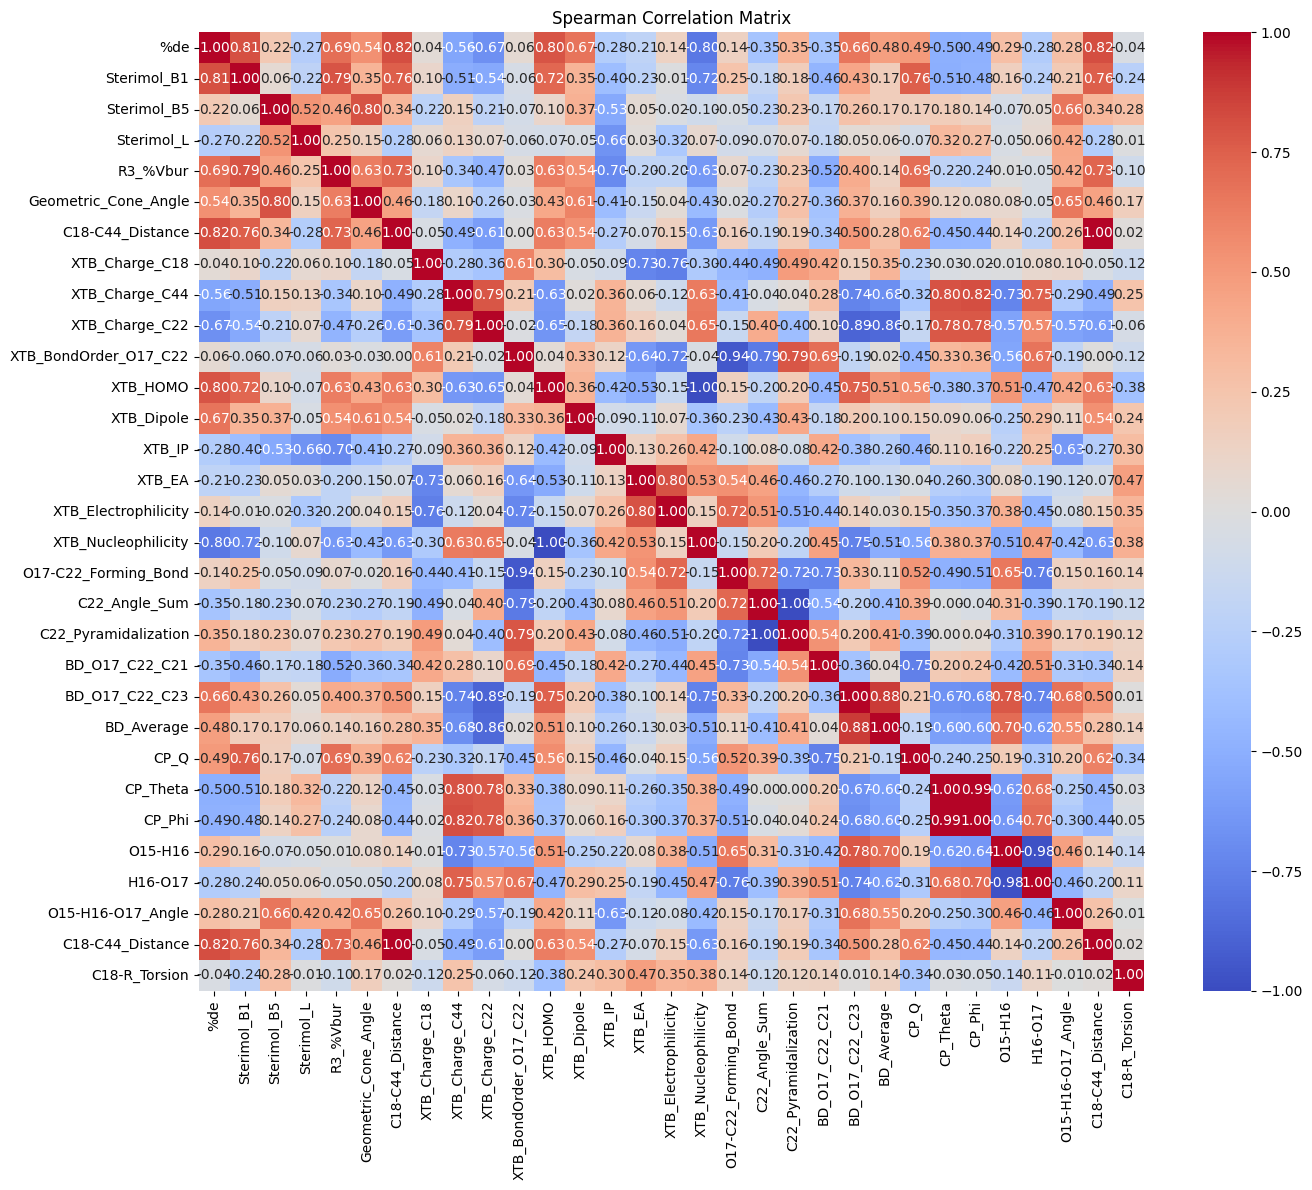

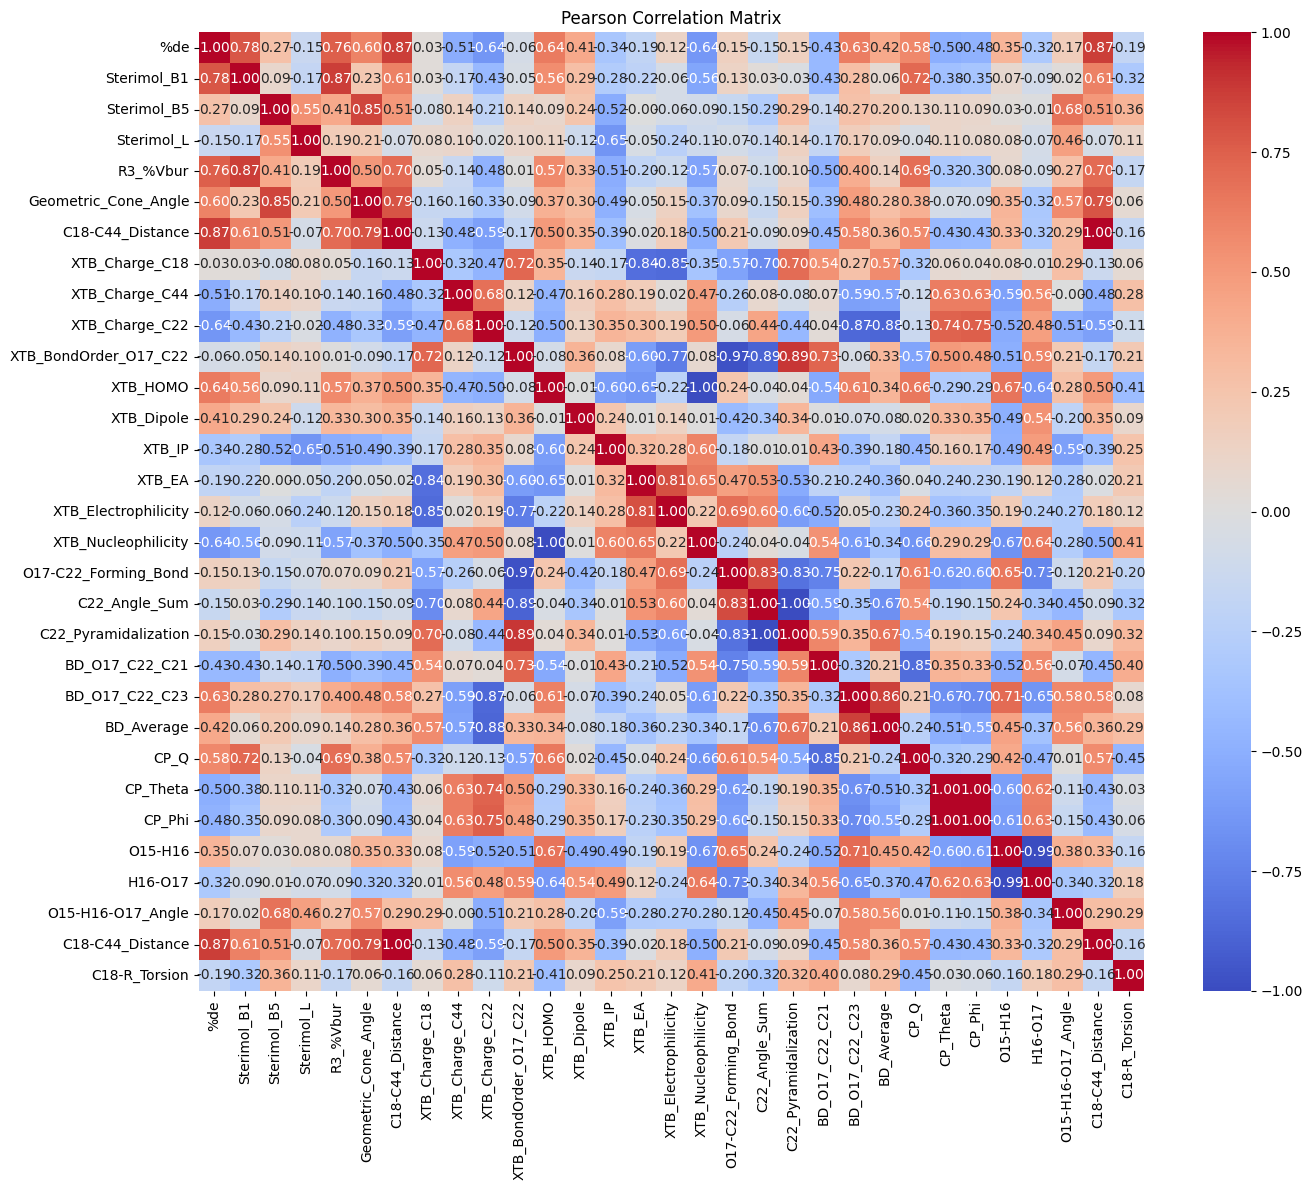

In [6]:
# ============================================================
# 28. CORRELATION HEATMAP
# ============================================================

corr_columns = [
    "%de"
] + all_descriptors


corr_data = results_df[
    corr_columns
].copy()


# ------------------------------------------------------------
# Spearman
# ------------------------------------------------------------

spearman_matrix = corr_data.corr(
    method="spearman"
)


plt.figure(
    figsize=(14, 12)
)

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    square=False
)

plt.title(
    "Spearman Correlation Matrix"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Pearson
# ------------------------------------------------------------

pearson_matrix = corr_data.corr(
    method="pearson"
)


plt.figure(
    figsize=(14, 12)
)

sns.heatmap(
    pearson_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    square=False
)

plt.title(
    "Pearson Correlation Matrix"
)

plt.tight_layout()

plt.show()

In [7]:
# ============================================================
# 29. GROUPED CORRELATION TABLE
# ============================================================

def grouped_correlations(
    descriptors,
    group_name
):

    rows = []

    for descriptor in descriptors:

        if descriptor not in results_df.columns:
            continue

        data = results_df[
            [
                descriptor,
                "%de"
            ]
        ].dropna()

        if len(data) < 3:
            continue

        try:

            pr, pp = pearsonr(
                data[descriptor],
                data["%de"]
            )

        except Exception:

            pr = np.nan
            pp = np.nan

        try:

            sr, sp = spearmanr(
                data[descriptor],
                data["%de"]
            )

        except Exception:

            sr = np.nan
            sp = np.nan

        rows.append({

            "Control":
                group_name,

            "Descriptor":
                descriptor,

            "N":
                len(data),

            "Pearson_r":
                pr,

            "Pearson_p":
                pp,

            "Spearman_rho":
                sr,

            "Spearman_p":
                sp
        })

    return pd.DataFrame(rows)


steric_corr = grouped_correlations(
    steric_descriptors,
    "Steric"
)

electronic_corr = grouped_correlations(
    electronic_descriptors,
    "Electronic"
)

geometric_corr = grouped_correlations(
    geometric_descriptors,
    "Geometric distortion"
)


grouped_corr = pd.concat(
    [
        steric_corr,
        electronic_corr,
        geometric_corr
    ],
    ignore_index=True
)


grouped_corr[
    "Abs_Spearman_rho"
] = grouped_corr[
    "Spearman_rho"
].abs()


grouped_corr = grouped_corr.sort_values(
    [
        "Control",
        "Abs_Spearman_rho"
    ],
    ascending=[
        True,
        False
    ]
)


display(
    grouped_corr
)

,Control,Descriptor,N,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Abs_Spearman_rho
10,Electronic,XTB_HOMO,17,0.640249,0.005631,0.796348,0.000131,0.796348
15,Electronic,XTB_Nucleophilicity,17,-0.640249,0.005631,-0.796348,0.000131,0.796348
8,Electronic,XTB_Charge_C22,17,-0.642428,0.005420,-0.673355,0.003047,0.673355
11,Electronic,XTB_Dipole,17,0.414672,0.097923,0.670870,0.003199,0.670870
7,Electronic,XTB_Charge_C44,17,-0.510866,0.036114,-0.559058,0.019646,0.559058
12,Electronic,XTB_IP,17,-0.339124,0.182989,-0.278287,0.279450,0.278287
13,Electronic,XTB_EA,17,-0.190910,0.462962,-0.209957,0.418622,0.209957
14,Electronic,XTB_Electrophilicity,17,0.117527,0.653267,0.135416,0.604315,0.135416
9,Electronic,XTB_BondOrder_O17_C22,17,-0.062948,0.810324,0.062118,0.812783,0.062118
6,Electronic,XTB_Charge_C18,17,0.029406,0.910798,0.040998,0.875854,0.040998


In [8]:
# ============================================================
# 30. SAVE EXCEL WORKBOOK
# ============================================================

excel_file = os.path.join(
    output_folder,
    "R3_Steric_Electronic_Geometric_Analysis.xlsx"
)


with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    # ----------------------------------------
    # Complete descriptors
    # ----------------------------------------

    results_df.to_excel(
        writer,
        sheet_name="All_Descriptors",
        index=False
    )

    # ----------------------------------------
    # Correlations
    # ----------------------------------------

    correlation_df.to_excel(
        writer,
        sheet_name="All_Correlations",
        index=False
    )

    grouped_corr.to_excel(
        writer,
        sheet_name="Grouped_Correlations",
        index=False
    )

    # ----------------------------------------
    # Pearson matrix
    # ----------------------------------------

    pearson_matrix.to_excel(
        writer,
        sheet_name="Pearson_Matrix"
    )

    # ----------------------------------------
    # Spearman matrix
    # ----------------------------------------

    spearman_matrix.to_excel(
        writer,
        sheet_name="Spearman_Matrix"
    )

    # ----------------------------------------
    # Individual groups
    # ----------------------------------------

    steric_corr.to_excel(
        writer,
        sheet_name="Steric_Correlation",
        index=False
    )

    electronic_corr.to_excel(
        writer,
        sheet_name="Electronic_Correlation",
        index=False
    )

    geometric_corr.to_excel(
        writer,
        sheet_name="Geometric_Correlation",
        index=False
    )


print(
    "Excel saved:"
)

print(
    excel_file
)

Excel saved:
/content/drive/MyDrive/xyz_files/R3_Control_Analysis/R3_Steric_Electronic_Geometric_Analysis.xlsx


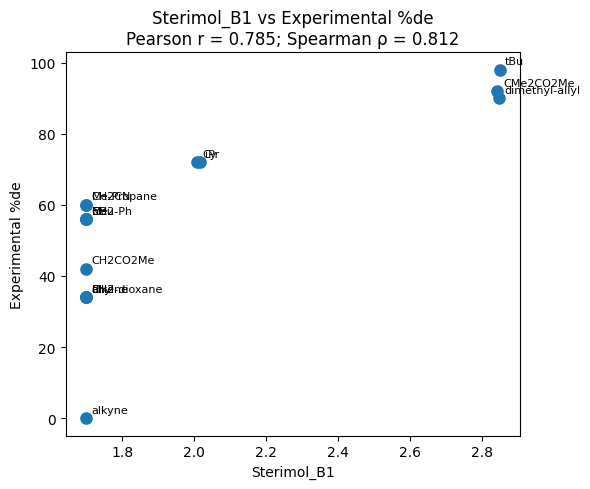

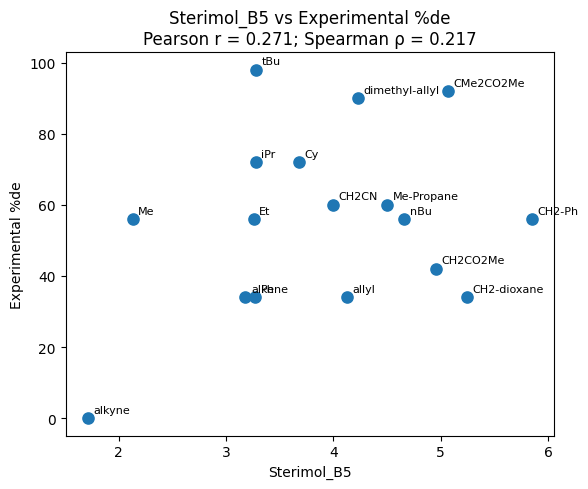

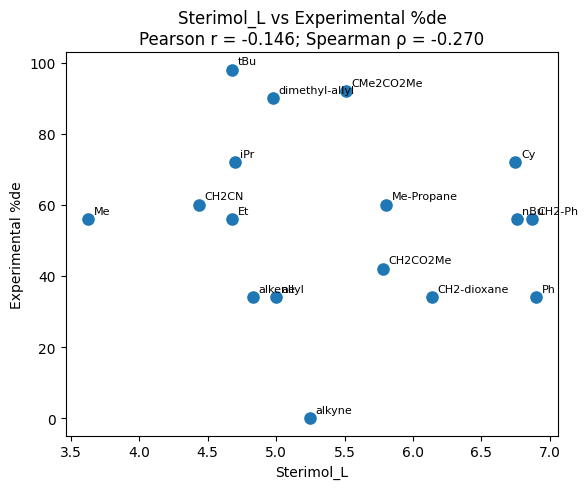

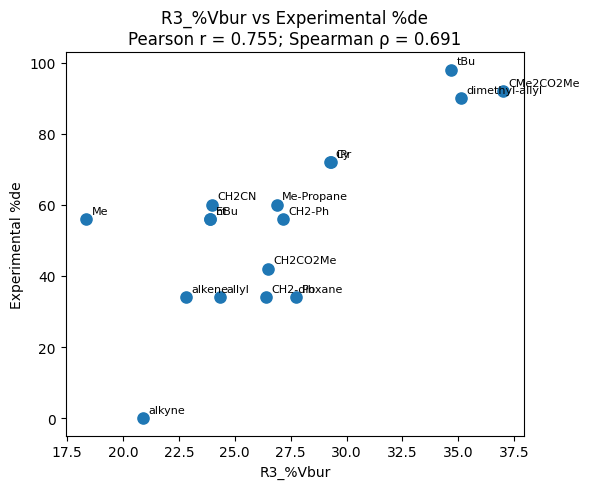

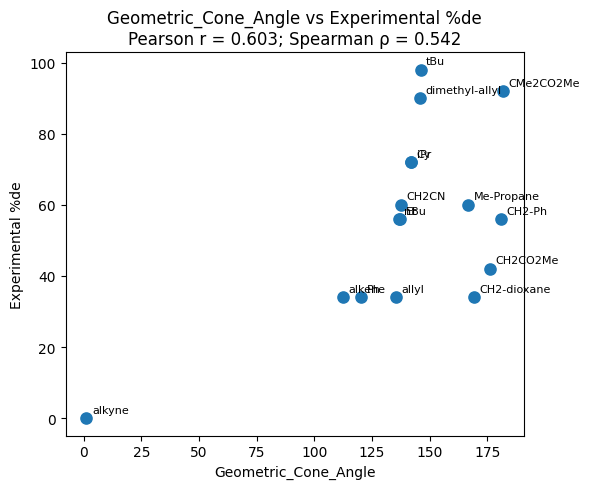

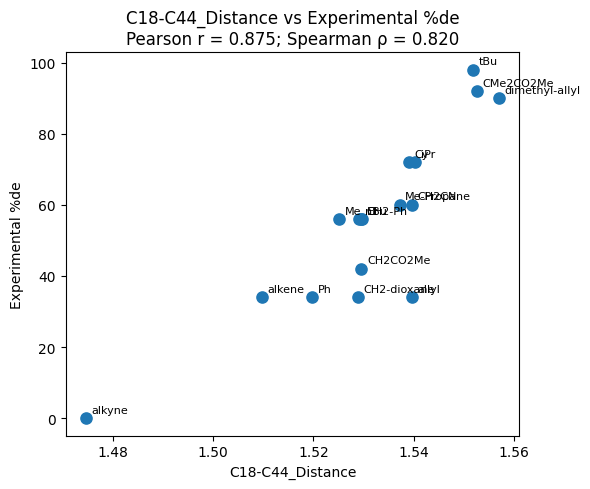

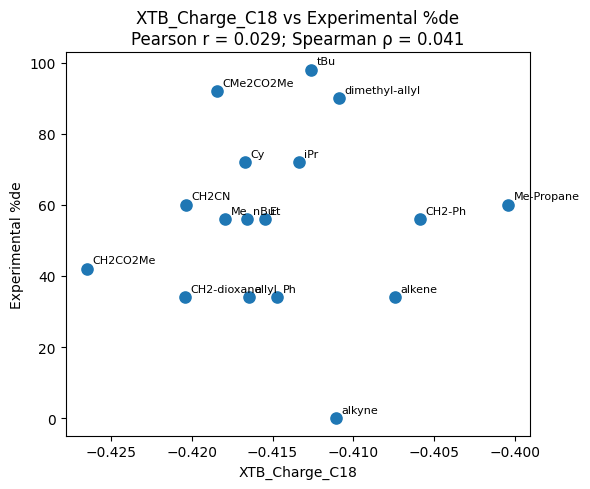

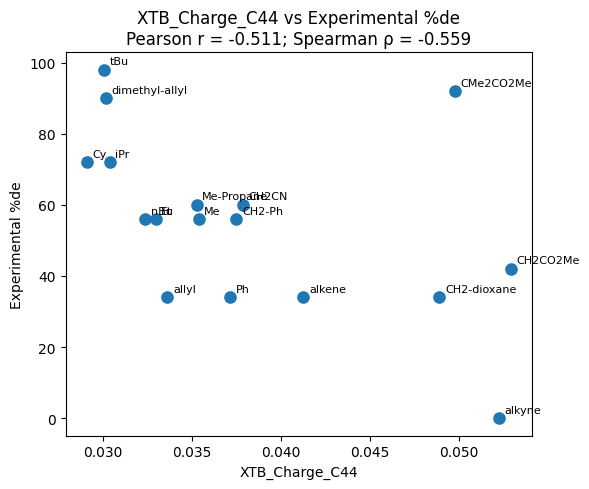

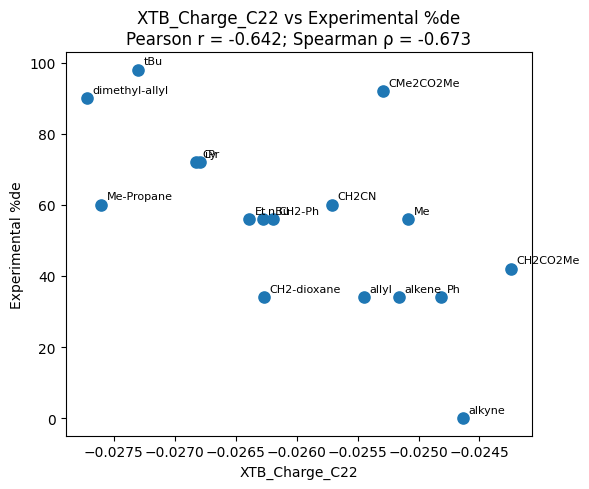

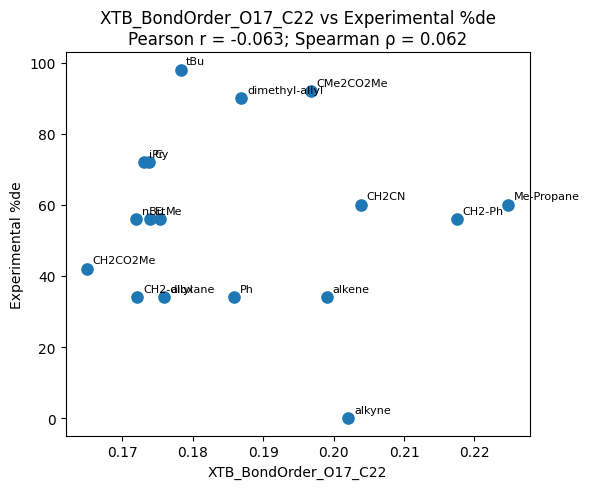

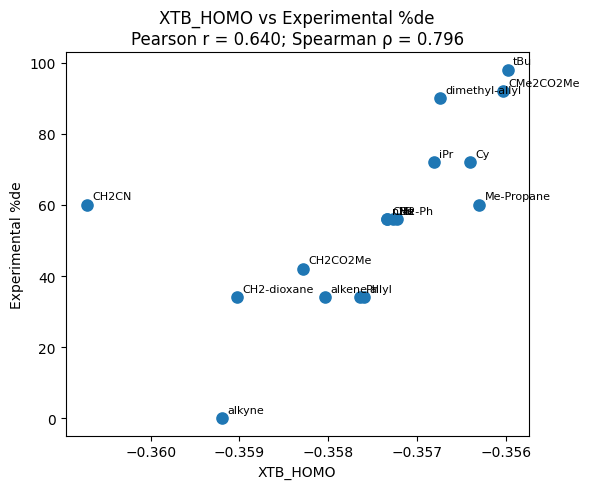

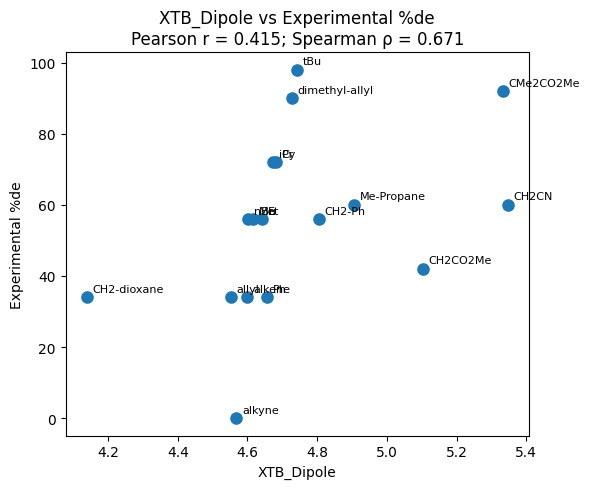

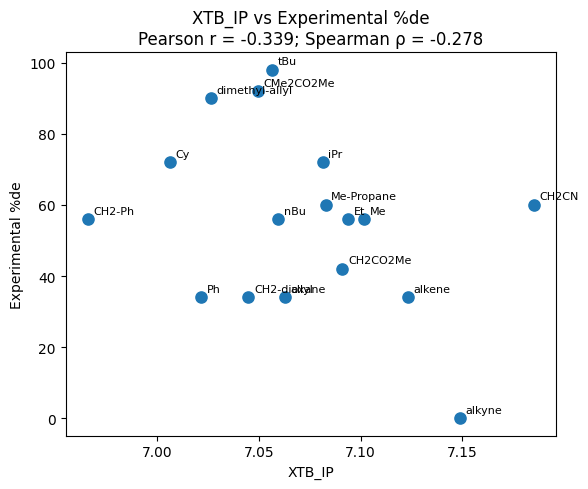

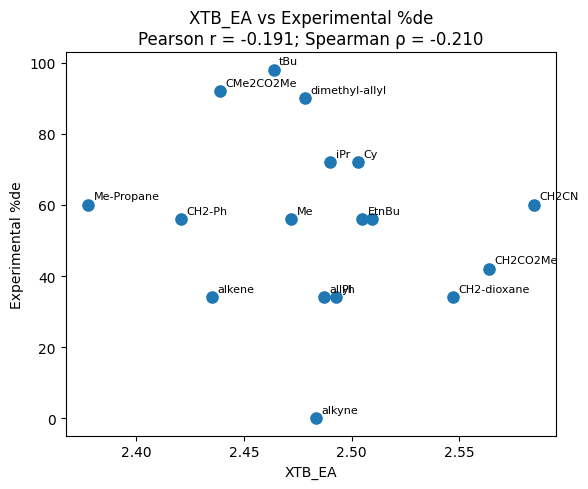

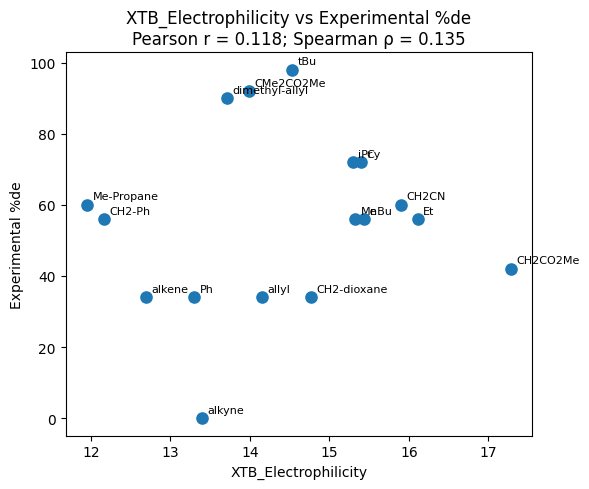

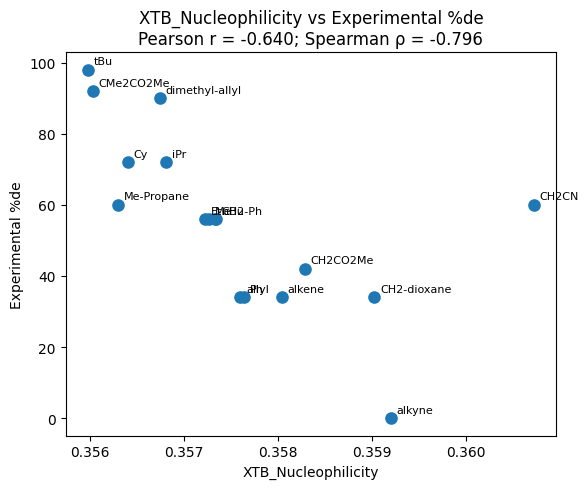

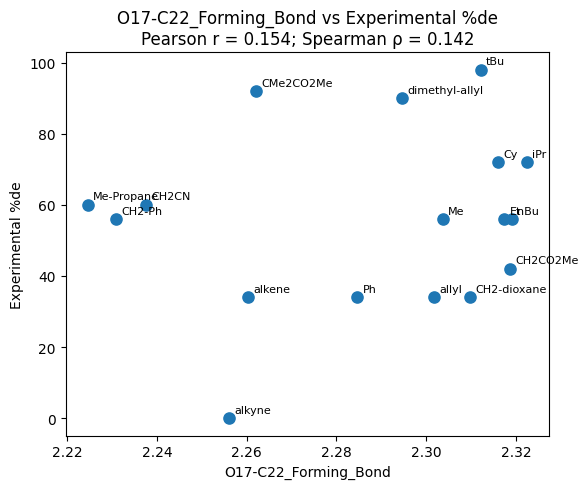

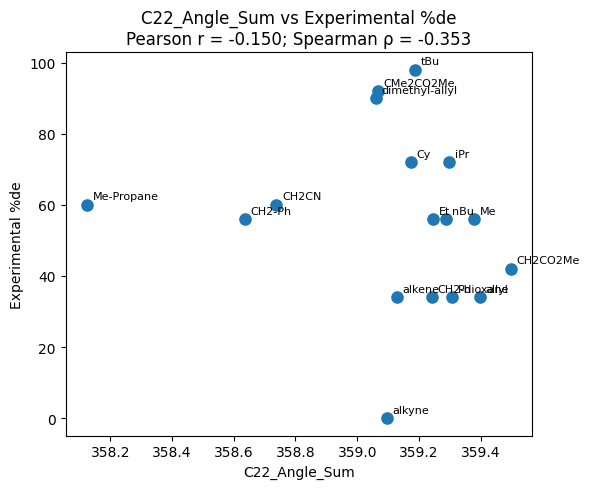

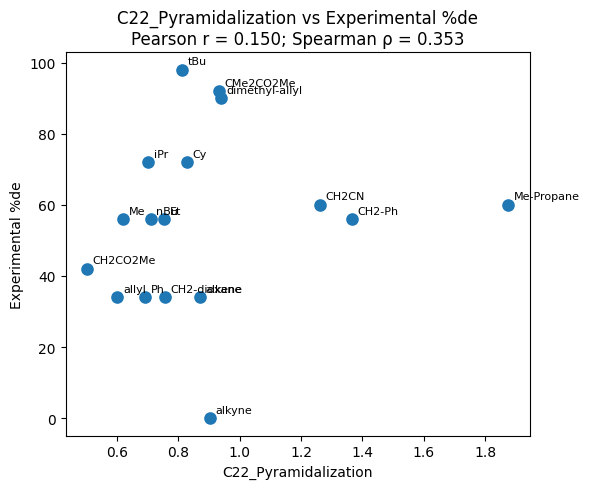

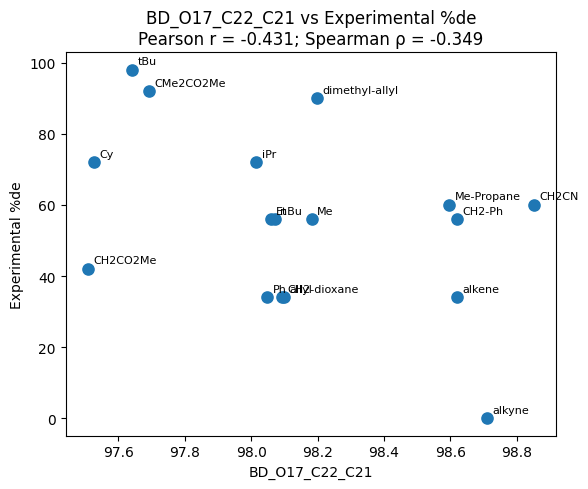

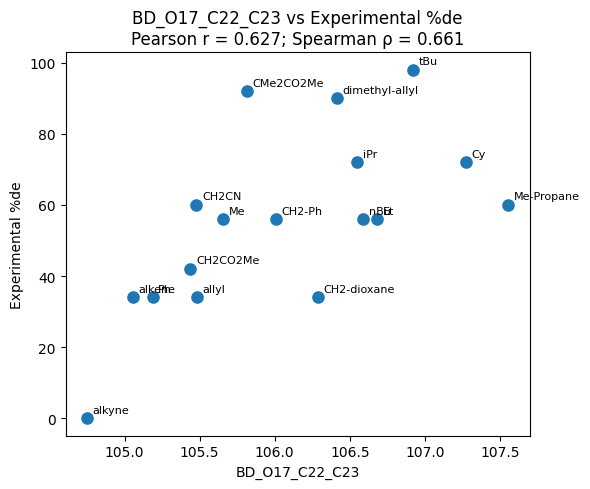

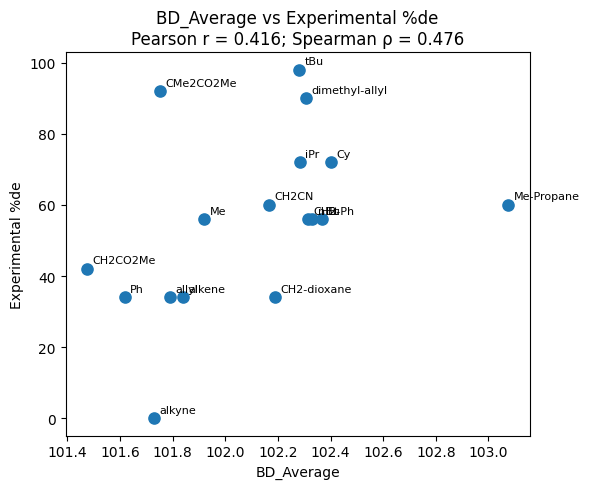

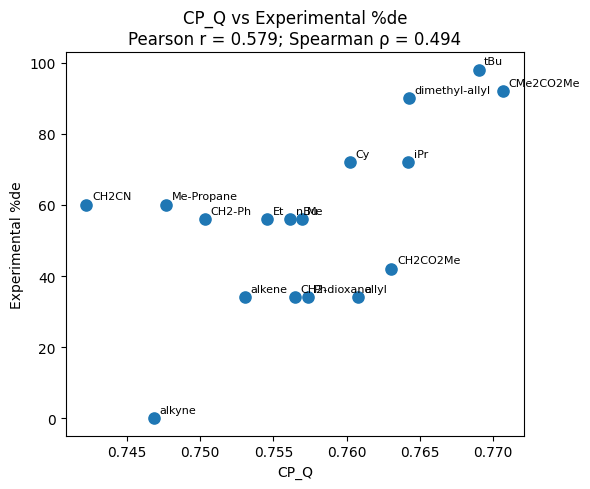

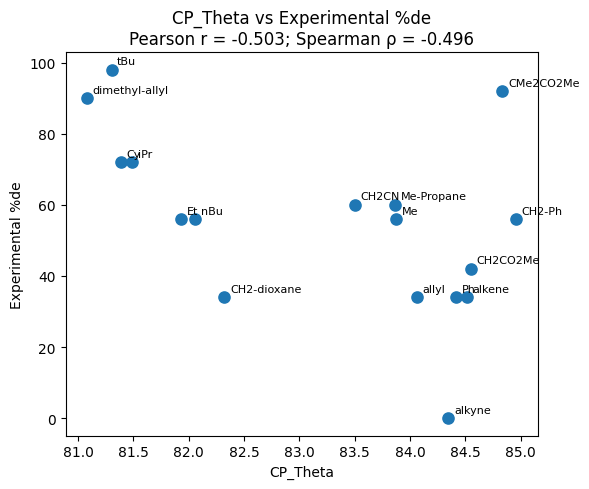

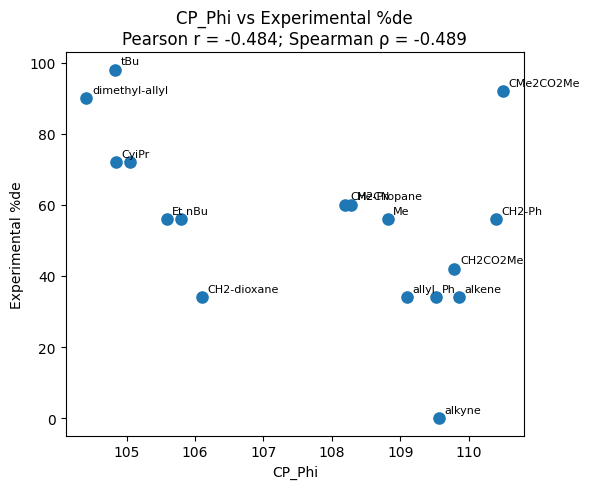

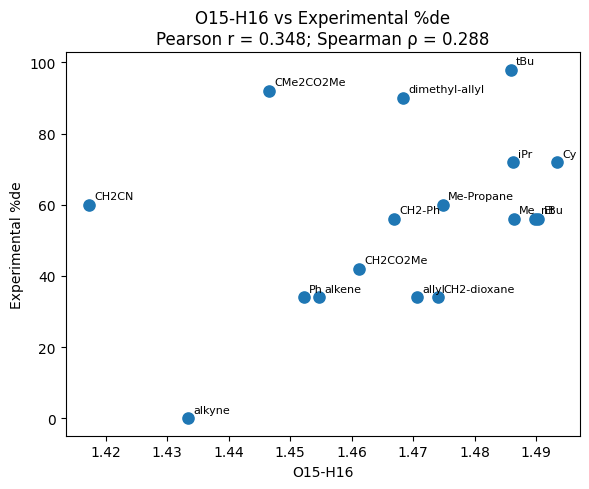

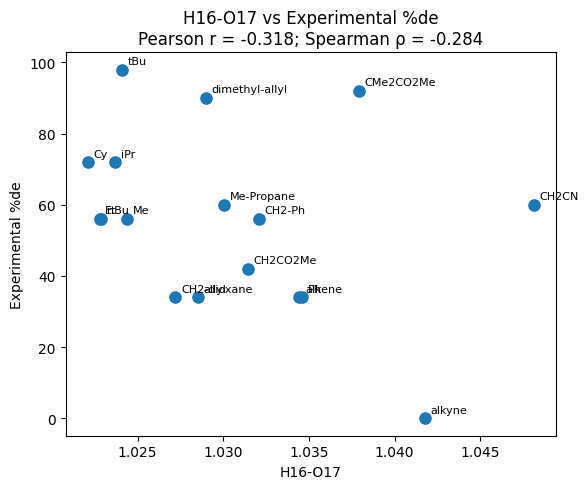

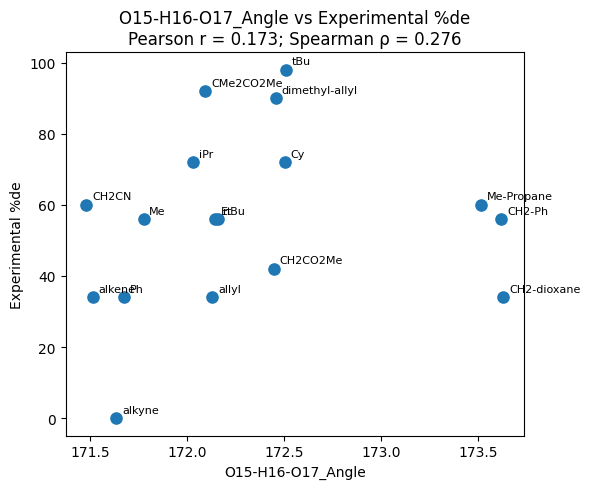

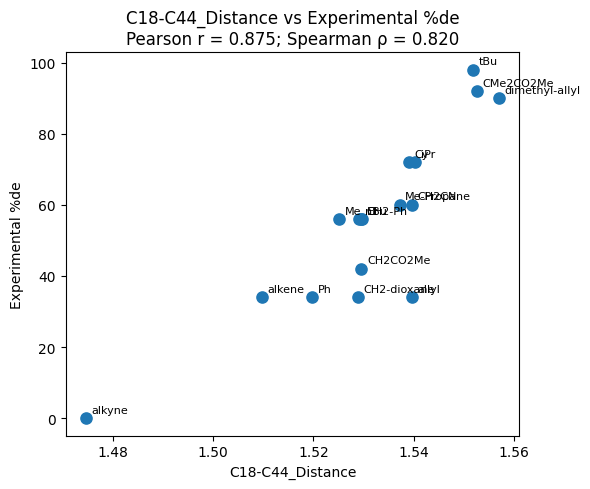

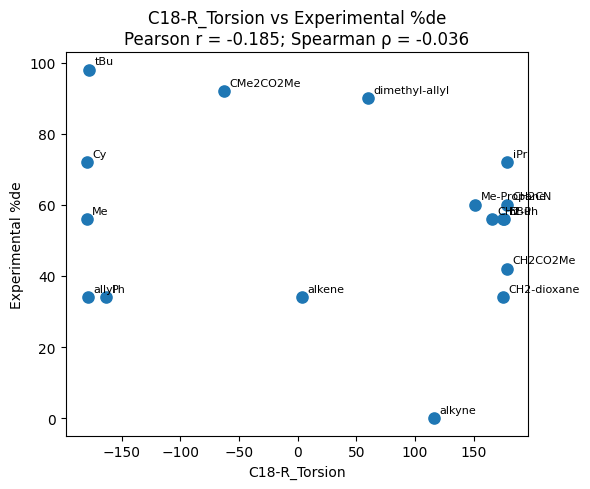

In [9]:
# ============================================================
# 32. SCATTER PLOTS FOR ALL DESCRIPTORS
# ============================================================

plot_folder = os.path.join(
    output_folder,
    "Correlation_Plots"
)

os.makedirs(
    plot_folder,
    exist_ok=True
)


for descriptor in all_descriptors:

    data = results_df[
        [
            descriptor,
            "%de",
            "R3"
        ]
    ].dropna()

    if len(data) < 3:
        continue

    try:

        pr, pp = pearsonr(
            data[descriptor],
            data["%de"]
        )

        sr, sp = spearmanr(
            data[descriptor],
            data["%de"]
        )

    except Exception:

        continue


    plt.figure(
        figsize=(6, 5)
    )

    plt.scatter(
        data[descriptor],
        data["%de"],
        s=65
    )


    for _, row in data.iterrows():

        plt.annotate(
            row["R3"],
            (
                row[descriptor],
                row["%de"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )


    plt.xlabel(
        descriptor
    )

    plt.ylabel(
        "Experimental %de"
    )

    plt.title(
        f"{descriptor} vs Experimental %de\n"
        f"Pearson r = {pr:.3f}; "
        f"Spearman ρ = {sr:.3f}"
    )

    plt.tight_layout()


    safe_name = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        descriptor
    )

    plt.savefig(
        os.path.join(
            plot_folder,
            f"{safe_name}_vs_%de.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [11]:
# ============================================================
# ALL R3 PARAMETERS — MULTIVARIATE REGRESSION
#
# Response:
#     Experimental %de (RR = major, RS = minor)
#
# Tests:
#     ALL possible combinations:
#     1 parameter
#     2 parameters
#     3 parameters
#     ...
#     ALL parameters
#
# Statistics:
#     R2
#     Adjusted R2
#     LOO-CV R2
#     LOO-CV RMSE
#     AICc
#     VIF
#     Regression coefficients
#     p-values
#
# ============================================================


# ============================================================
# 1. INSTALL
# ============================================================

!pip install -q pandas numpy openpyxl scipy statsmodels matplotlib


# ============================================================
# 2. IMPORTS
# ============================================================

import os
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from scipy.stats import spearmanr, pearsonr

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

from google.colab import drive

warnings.filterwarnings("ignore")


# ============================================================
# 3. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=True
)


# ============================================================
# 4. INPUT FILE
# ============================================================

xyz_folder = Path(
    "/content/drive/MyDrive/xyz_files"
)

input_file = (
    xyz_folder /
    "COMPLETE_R3_ANALYSIS.xlsx"
)


print("=" * 90)
print("R3 MULTIVARIATE REGRESSION ANALYSIS")
print("=" * 90)

print("\nInput file:")
print(input_file)

if not input_file.exists():

    raise FileNotFoundError(
        "\nERROR: COMPLETE_R3_ANALYSIS.xlsx "
        "was not found in the xyz_files folder."
    )

print("\nFile found successfully.")


# ============================================================
# 5. READ EXCEL
# ============================================================

steric_df = pd.read_excel(
    input_file
)

print("\nExcel columns:")
for col in steric_df.columns:
    print("   ", col)


# ============================================================
# 6. EXPERIMENTAL %de
#
# RR = MAJOR
# RS = MINOR
# ============================================================

exp_data = {

    "RR_CH2-Ph.xyz": 56,

    "RR_CH2-dioxane.xyz": 34,

    "RR_CH2CN.xyz": 60,

    "RR_CH2CO2Me.xyz": 42,

    "RR_CMe2CO2Me.xyz": 92,

    "RR_Cy.xyz": 72,

    "RR_Et.xyz": 56,

    "RR_Me-Propane.xyz": 60,

    "RR_Me.xyz": 56,

    "RR_Ph.xyz": 34,

    "RR_alkene.xyz": 34,

    "RR_alkyne.xyz": 0,

    "RR_allyl.xyz": 34,

    "RR_dimethyl-allyl.xyz": 90,

    "RR_iPr.xyz": 72,

    "RR_nBu.xyz": 56,

    "RR_tBu.xyz": 98

}


exp_df = pd.DataFrame(

    list(exp_data.items()),

    columns=[
        "File",
        "Experimental_%de"
    ]

)


# ============================================================
# 7. STANDARDIZE EXCEL COLUMN NAMES
# ============================================================

rename_dict = {

    "Sterimol B1 (Å)": "B1",
    "B1 (Å)": "B1",

    "Sterimol B5 (Å)": "B5",
    "B5 (Å)": "B5",

    "Sterimol L (Å)": "L",
    "L (Å)": "L",

    "Cone Angle (deg)": "Cone_Angle",
    "Cone Angle": "Cone_Angle",

    "C18-C44 distance (Å)": "C18_C44",
    "C18-C44 (Å)": "C18_C44",

    "C44-furthest R3 distance (Å)": "Furthest_R3",
    "C44-furthest R3 (Å)": "Furthest_R3",

    "Max perpendicular distance (Å)": "Max_Perpendicular",

    "%Vbur": "Vbur",
    "%Vbur (%)": "Vbur",

    "Percent buried volume": "Vbur",
    "Percent buried volume (%)": "Vbur",

    "percent_vbur": "Vbur",
    "percent buried volume": "Vbur"

}


for old_name, new_name in rename_dict.items():

    if old_name in steric_df.columns:

        steric_df.rename(
            columns={
                old_name: new_name
            },
            inplace=True
        )


# ============================================================
# 8. ALL CANDIDATE PARAMETERS
# ============================================================

candidate_parameters = [

    "B1",

    "B5",

    "L",

    "Cone_Angle",

    "C18_C44",

    "Furthest_R3",

    "Max_Perpendicular",

    "Vbur"

]


# ============================================================
# 9. FIND AVAILABLE PARAMETERS
# ============================================================

parameters = [

    p

    for p in candidate_parameters

    if p in steric_df.columns

]


print("\n")
print("=" * 90)
print("PARAMETERS AVAILABLE FOR MODELING")
print("=" * 90)

for p in parameters:

    print(
        "   ✓",
        p
    )


missing = [

    p

    for p in candidate_parameters

    if p not in steric_df.columns

]


if missing:

    print("\nParameters NOT found:")

    for p in missing:

        print(
            "   -",
            p
        )


# ============================================================
# 10. MERGE EXPERIMENTAL + STERIC DATA
# ============================================================

df = exp_df.merge(

    steric_df,

    on="File",

    how="left"

)


# ============================================================
# 11. R3 NAME
# ============================================================

df["R3"] = (

    df["File"]

    .str.replace(
        "RR_",
        "",
        regex=False
    )

    .str.replace(
        ".xyz",
        "",
        regex=False
    )

)


# ============================================================
# 12. CONVERT TO NUMERIC
# ============================================================

df["Experimental_%de"] = pd.to_numeric(

    df["Experimental_%de"],

    errors="coerce"

)


for p in parameters:

    df[p] = pd.to_numeric(

        df[p],

        errors="coerce"

    )


# ============================================================
# 13. SHOW FINAL DATA
# ============================================================

print("\n")
print("=" * 90)
print("DATA USED FOR REGRESSION")
print("=" * 90)

display(

    df[
        ["R3", "Experimental_%de"]
        + parameters
    ]

)


# ============================================================
# 14. VIF FUNCTION
# ============================================================

def calculate_vif(X):

    """

    Calculate Variance Inflation Factor.

    X contains ONLY predictors.
    Intercept is not included.

    """

    vif_results = {}


    # One predictor automatically has VIF = 1

    if X.shape[1] == 1:

        vif_results[
            X.columns[0]
        ] = 1.0

        return vif_results


    X = X.astype(float)


    for i, column in enumerate(
        X.columns
    ):

        try:

            vif = variance_inflation_factor(

                X.values,

                i

            )

            vif_results[column] = vif

        except:

            vif_results[column] = np.inf


    return vif_results


# ============================================================
# 15. LOO-CV FUNCTION
# ============================================================

def calculate_loo_cv(

    data,
    predictors,
    response="Experimental_%de"

):

    """

    Leave-One-Out Cross Validation.

    Returns:

        LOO-CV R2
        LOO-CV RMSE

    """

    X = data[
        predictors
    ].astype(float)

    y = data[
        response
    ].astype(float)


    n = len(y)


    predictions = []

    actual_values = []


    for i in range(n):

        # ------------------------------------------
        # Training indices
        # ------------------------------------------

        train_indices = [

            j

            for j in range(n)

            if j != i

        ]


        X_train = X.iloc[
            train_indices
        ]

        y_train = y.iloc[
            train_indices
        ]


        X_test = X.iloc[
            [i]
        ]


        # ------------------------------------------
        # Add intercept
        # ------------------------------------------

        X_train_const = sm.add_constant(

            X_train,

            has_constant="add"

        )


        X_test_const = sm.add_constant(

            X_test,

            has_constant="add"

        )


        # ------------------------------------------
        # Fit
        # ------------------------------------------

        try:

            model = sm.OLS(

                y_train,

                X_train_const

            ).fit()


            prediction = model.predict(

                X_test_const

            ).iloc[0]


        except:

            prediction = np.nan


        predictions.append(
            prediction
        )

        actual_values.append(
            y.iloc[i]
        )


    predictions = np.array(
        predictions,
        dtype=float
    )

    actual_values = np.array(
        actual_values,
        dtype=float
    )


    valid = (

        np.isfinite(
            predictions
        )

        &

        np.isfinite(
            actual_values
        )

    )


    predictions = predictions[
        valid
    ]

    actual_values = actual_values[
        valid
    ]


    if len(actual_values) == 0:

        return np.nan, np.nan


    residuals = (

        actual_values
        -
        predictions

    )


    PRESS = np.sum(
        residuals ** 2
    )


    SST = np.sum(

        (
            actual_values
            -
            np.mean(actual_values)
        ) ** 2

    )


    if SST == 0:

        loo_r2 = np.nan

    else:

        loo_r2 = (

            1
            -
            PRESS / SST

        )


    loo_rmse = np.sqrt(

        np.mean(
            residuals ** 2
        )

    )


    return loo_r2, loo_rmse


# ============================================================
# 16. MODEL FITTING FUNCTION
# ============================================================

def fit_regression_model(

    data,
    predictors,
    response="Experimental_%de"

):

    # ------------------------------------------
    # Select complete observations
    # ------------------------------------------

    model_data = data[
        [response] + list(predictors)
    ].dropna()


    n = len(model_data)

    k = len(predictors)


    # Need at least one residual degree of freedom

    if n <= k + 1:

        return None


    X = model_data[
        predictors
    ].astype(float)

    y = model_data[
        response
    ].astype(float)


    # ------------------------------------------
    # OLS with intercept
    # ------------------------------------------

    X_const = sm.add_constant(

        X,

        has_constant="add"

    )


    model = sm.OLS(

        y,

        X_const

    ).fit()


    # ------------------------------------------
    # R2
    # ------------------------------------------

    r2 = model.rsquared


    # ------------------------------------------
    # Adjusted R2
    # ------------------------------------------

    adjusted_r2 = model.rsquared_adj


    # ------------------------------------------
    # LOO-CV
    # ------------------------------------------

    loo_r2, loo_rmse = calculate_loo_cv(

        model_data,

        predictors,

        response

    )


    # ------------------------------------------
    # AICc
    # ------------------------------------------

    aic = model.aic

    number_parameters = k + 1

    denominator = (

        n
        -
        number_parameters
        -
        1

    )


    if denominator > 0:

        aicc = (

            aic

            +

            (

                2
                *
                number_parameters
                *
                (
                    number_parameters
                    + 1
                )

                /

                denominator

            )

        )

    else:

        aicc = np.nan


    # ------------------------------------------
    # VIF
    # ------------------------------------------

    vif = calculate_vif(X)


    max_vif = max(
        vif.values()
    )


    # ------------------------------------------
    # Result dictionary
    # ------------------------------------------

    result = {

        "Predictors":
            " + ".join(predictors),

        "Number_of_predictors":
            k,

        "N":
            n,

        "R2":
            r2,

        "Adjusted_R2":
            adjusted_r2,

        "LOO_CV_R2":
            loo_r2,

        "LOO_CV_RMSE":
            loo_rmse,

        "AICc":
            aicc,

        "Max_VIF":
            max_vif

    }


    # ------------------------------------------
    # Individual VIF
    # ------------------------------------------

    for p in predictors:

        result[
            "VIF_" + p
        ] = vif[p]


    # ------------------------------------------
    # Coefficients
    # ------------------------------------------

    for p in predictors:

        result[
            "Coef_" + p
        ] = model.params[p]


    # ------------------------------------------
    # p-values
    # ------------------------------------------

    for p in predictors:

        result[
            "p_" + p
        ] = model.pvalues[p]


    return result, model


# ============================================================
# 17. TEST EVERY POSSIBLE COMBINATION
# ============================================================

all_results = []

model_objects = {}


print("\n")
print("=" * 90)
print("TESTING ALL POSSIBLE PARAMETER COMBINATIONS")
print("=" * 90)


total_models = (

    2 ** len(parameters)

    -

    1

)


print(
    "\nTotal possible models:",
    total_models
)


for n_predictors in range(

    1,

    len(parameters) + 1

):


    combinations = itertools.combinations(

        parameters,

        n_predictors

    )


    count = 0


    for combo in combinations:


        output = fit_regression_model(

            df,

            combo

        )


        if output is None:

            continue


        result, model = output


        all_results.append(
            result
        )


        model_objects[
            result["Predictors"]
        ] = model


        count += 1


    print(

        f"{n_predictors}-parameter models: "
        f"{count}"

    )


# ============================================================
# 18. CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    all_results
)


print("\nTotal models successfully evaluated:")

print(
    len(results_df)
)


# ============================================================
# 19. FLAG VIF
# ============================================================

results_df["VIF_OK"] = (

    results_df["Max_VIF"]
    < 5

)


# ============================================================
# 20. FLAG POSITIVE LOO R2
# ============================================================

results_df["LOO_R2_positive"] = (

    results_df["LOO_CV_R2"]
    > 0

)


# ============================================================
# 21. RANK ALL MODELS
#
# Primary:
#     LOO-CV R2
#
# Secondary:
#     Adjusted R2
#     AICc
# ============================================================

ranked_all = (

    results_df

    .sort_values(

        [
            "LOO_CV_R2",
            "Adjusted_R2",
            "R2"

        ],

        ascending=False

    )

)


# ============================================================
# 22. ACCEPTABLE MODELS
#
# VIF < 5
# ============================================================

acceptable_models = results_df[
    results_df["Max_VIF"] < 5
].copy()


acceptable_models = (

    acceptable_models

    .sort_values(

        [
            "LOO_CV_R2",
            "Adjusted_R2",
            "R2"

        ],

        ascending=False

    )

)


# ============================================================
# 23. TOP 30 MODELS
# ============================================================

print("\n")
print("=" * 120)
print("TOP 30 MODELS — VIF < 5 — RANKED BY LOO-CV R2")
print("=" * 120)


display(

    acceptable_models[
        [
            "Predictors",
            "Number_of_predictors",
            "N",
            "R2",
            "Adjusted_R2",
            "LOO_CV_R2",
            "LOO_CV_RMSE",
            "AICc",
            "Max_VIF"
        ]
    ]

    .head(30)

    .round(4)

)


# ============================================================
# 24. BEST MODEL FOR EACH MODEL SIZE
# ============================================================

best_by_size = (

    acceptable_models

    .sort_values(

        "LOO_CV_R2",

        ascending=False

    )

    .groupby(

        "Number_of_predictors",

        as_index=False

    )

    .first()

)


print("\n")
print("=" * 120)
print("BEST MODEL FOR EACH NUMBER OF PARAMETERS")
print("=" * 120)


display(

    best_by_size[
        [
            "Number_of_predictors",
            "Predictors",
            "R2",
            "Adjusted_R2",
            "LOO_CV_R2",
            "LOO_CV_RMSE",
            "AICc",
            "Max_VIF"
        ]
    ]

    .sort_values(
        "Number_of_predictors"
    )

    .round(4)

)


# ============================================================
# 25. BEST OVERALL MODEL
# ============================================================

if len(acceptable_models) == 0:

    raise ValueError(

        "No model passed the VIF < 5 criterion."

    )


best_row = acceptable_models.iloc[0]


best_predictors = (

    best_row[
        "Predictors"
    ]

    .split(
        " + "
    )

)


best_model_name = best_row[
    "Predictors"
]


best_model = model_objects[
    best_model_name
]


# ============================================================
# 26. PRINT BEST MODEL
# ============================================================

print("\n")
print("=" * 90)
print("BEST MODEL")
print("=" * 90)


print(
    "\nModel:"
)

print(
    best_model_name
)


print(

    f"\nR²          = "
    f"{best_row['R2']:.4f}"

)


print(

    f"Adjusted R² = "
    f"{best_row['Adjusted_R2']:.4f}"

)


print(

    f"LOO-CV R²   = "
    f"{best_row['LOO_CV_R2']:.4f}"

)


print(

    f"LOO-CV RMSE = "
    f"{best_row['LOO_CV_RMSE']:.4f}"

)


print(

    f"AICc        = "
    f"{best_row['AICc']:.4f}"

)


print(

    f"Maximum VIF = "
    f"{best_row['Max_VIF']:.4f}"

)


# ============================================================
# 27. FULL STATISTICAL SUMMARY
# ============================================================

print("\n")
print("=" * 90)
print("OLS REGRESSION SUMMARY")
print("=" * 90)

print(
    best_model.summary()
)


# ============================================================
# 28. BEST MODEL COEFFICIENT TABLE
# ============================================================

coefficient_table = pd.DataFrame({

    "Predictor":

        best_predictors,

    "Coefficient":

        [
            best_model.params[p]
            for p in best_predictors
        ],

    "p-value":

        [
            best_model.pvalues[p]
            for p in best_predictors
        ],

    "VIF":

        [
            best_row[
                "VIF_" + p
            ]

            for p in best_predictors
        ]

})


print("\n")
print("=" * 90)
print("BEST MODEL COEFFICIENTS")
print("=" * 90)

display(
    coefficient_table.round(5)
)


# ============================================================
# 29. PREDICTIONS
# ============================================================

best_data = df[
    [
        "R3",
        "File",
        "Experimental_%de"
    ]
    +
    best_predictors
].dropna().copy()


X_best = best_data[
    best_predictors
].astype(float)


X_best_const = sm.add_constant(

    X_best,

    has_constant="add"

)


best_data["Predicted_%de"] = (

    best_model.predict(
        X_best_const
    )

)


best_data["Residual"] = (

    best_data["Experimental_%de"]

    -

    best_data["Predicted_%de"]

)


# ============================================================
# 30. OBSERVED vs PREDICTED PLOT
# ============================================================

fig, ax = plt.subplots(

    figsize=(8, 7)

)


ax.scatter(

    best_data[
        "Experimental_%de"
    ],

    best_data[
        "Predicted_%de"
    ],

    s=80

)


minimum = min(

    best_data[
        "Experimental_%de"
    ].min(),

    best_data[
        "Predicted_%de"
    ].min()

)


maximum = max(

    best_data[
        "Experimental_%de"
    ].max(),

    best_data[
        "Predicted_%de"
    ].max()

)


ax.plot(

    [minimum, maximum],

    [minimum, maximum],

    linestyle="--"

)


for _, row in best_data.iterrows():

    ax.annotate(

        row["R3"],

        (
            row["Experimental_%de"],
            row["Predicted_%de"]
        ),

        xytext=(5, 5),

        textcoords="offset points",

        fontsize=9

    )


ax.set_xlabel(

    "Experimental %de (RR major)",

    fontsize=13

)


ax.set_ylabel(

    "Predicted %de",

    fontsize=13

)


ax.set_title(

    "Observed vs Predicted %de\n"

    + best_model_name

    +

    f"\nR² = {best_row['R2']:.3f}; "
    f"LOO-CV R² = {best_row['LOO_CV_R2']:.3f}",

    fontsize=12

)


ax.grid(
    alpha=0.25
)


fig.tight_layout()


observed_plot = (

    xyz_folder /

    "Best_Model_Observed_vs_Predicted.png"

)


fig.savefig(

    observed_plot,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close(fig)


# ============================================================
# 31. RESIDUAL PLOT
# ============================================================

fig, ax = plt.subplots(

    figsize=(8, 6)

)


ax.scatter(

    best_data[
        "Predicted_%de"
    ],

    best_data[
        "Residual"
    ],

    s=80

)


ax.axhline(

    0,

    linestyle="--"

)


for _, row in best_data.iterrows():

    ax.annotate(

        row["R3"],

        (
            row["Predicted_%de"],
            row["Residual"]
        ),

        xytext=(5, 5),

        textcoords="offset points",

        fontsize=9

    )


ax.set_xlabel(

    "Predicted %de",

    fontsize=13

)


ax.set_ylabel(

    "Residual",

    fontsize=13

)


ax.set_title(

    "Residual Plot — Best Model",

    fontsize=13

)


ax.grid(
    alpha=0.25
)


fig.tight_layout()


residual_plot = (

    xyz_folder /

    "Best_Model_Residuals.png"

)


fig.savefig(

    residual_plot,

    dpi=300,

    bbox_inches="tight"

)


plt.show()

plt.close(fig)


# ============================================================
# 32. SAVE EVERYTHING TO EXCEL
# ============================================================

output_excel = (

    xyz_folder /

    "R3_ALL_PARAMETER_Model_Analysis.xlsx"

)


with pd.ExcelWriter(

    output_excel,

    engine="openpyxl"

) as writer:


    # ------------------------------------------
    # Raw merged data
    # ------------------------------------------

    df.to_excel(

        writer,

        sheet_name="Merged_Data",

        index=False

    )


    # ------------------------------------------
    # ALL models
    # ------------------------------------------

    ranked_all.to_excel(

        writer,

        sheet_name="ALL_Models",

        index=False

    )


    # ------------------------------------------
    # Models with VIF < 5
    # ------------------------------------------

    acceptable_models.to_excel(

        writer,

        sheet_name="VIF_OK_Models",

        index=False

    )


    # ------------------------------------------
    # Best model at each size
    # ------------------------------------------

    best_by_size.to_excel(

        writer,

        sheet_name="Best_by_Model_Size",

        index=False

    )


    # ------------------------------------------
    # Best model predictions
    # ------------------------------------------

    best_data.to_excel(

        writer,

        sheet_name="Best_Model_Predictions",

        index=False

    )


    # ------------------------------------------
    # Best model coefficients
    # ------------------------------------------

    coefficient_table.to_excel(

        writer,

        sheet_name="Best_Model_Coefficients",

        index=False

    )


# ============================================================
# 33. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 90)
print("ANALYSIS COMPLETE")
print("=" * 90)


print(
    "\nNumber of parameters tested:",
    len(parameters)
)


print(
    "Total possible models:",
    total_models
)


print(
    "Total models evaluated:",
    len(results_df)
)


print(
    "\nBEST MODEL:"
)

print(
    best_model_name
)


print(

    f"\nR²          = "
    f"{best_row['R2']:.4f}"

)


print(

    f"Adjusted R² = "
    f"{best_row['Adjusted_R2']:.4f}"

)


print(

    f"LOO-CV R²   = "
    f"{best_row['LOO_CV_R2']:.4f}"

)


print(

    f"LOO-CV RMSE = "
    f"{best_row['LOO_CV_RMSE']:.4f}"

)


print(

    f"AICc        = "
    f"{best_row['AICc']:.4f}"

)


print(

    f"Maximum VIF = "
    f"{best_row['Max_VIF']:.4f}"

)


print("\nOutput Excel:")

print(
    output_excel
)


print("\nObserved vs predicted plot:")

print(
    observed_plot
)


print("\nResidual plot:")

print(
    residual_plot
)

Mounted at /content/drive
R3 MULTIVARIATE REGRESSION ANALYSIS

Input file:
/content/drive/MyDrive/xyz_files/COMPLETE_R3_ANALYSIS.xlsx

File found successfully.

Excel columns:
    R3
    Filename
    %de
    Sterimol_B1
    Sterimol_B5
    Sterimol_L
    R3_%Vbur
    Geometric_Cone_Angle
    Geometric_Half_Cone_Angle
    Cone_Limiting_Atom
    O17-C22_Forming_Bond
    C22_Angle_Sum
    C22_Pyramidalization
    BD_O17_C22_C21
    BD_O17_C22_C23
    BD_Average
    CP_Q
    CP_Theta
    CP_Phi
    Ring_Classification
    O15-H16
    H16-O17
    O15-H16-O17_Angle
    C18-C44_Distance
    C18-R_Torsion
    XTB_Energy
    XTB_HOMO
    XTB_LUMO
    XTB_Gap
    XTB_Dipole
    XTB_IP
    XTB_EA
    XTB_Electrophilicity
    XTB_Nucleophilicity
    XTB_Charge_C18
    XTB_Charge_C44
    XTB_Charge_C22
    XTB_BondOrder_O17_C22


PARAMETERS AVAILABLE FOR MODELING

Parameters NOT found:
   - B1
   - B5
   - L
   - Cone_Angle
   - C18_C44
   - Furthest_R3
   - Max_Perpendicular
   - Vbur


KeyError: 'File'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
R3 MULTIVARIATE REGRESSION ANALYSIS

Input file:
/content/drive/MyDrive/xyz_files/COMPLETE_R3_ANALYSIS.xlsx

File found successfully.

Excel columns:
    R3
    Filename
    %de
    Sterimol_B1
    Sterimol_B5
    Sterimol_L
    R3_%Vbur
    Geometric_Cone_Angle
    Geometric_Half_Cone_Angle
    Cone_Limiting_Atom
    O17-C22_Forming_Bond
    C22_Angle_Sum
    C22_Pyramidalization
    BD_O17_C22_C21
    BD_O17_C22_C23
    BD_Average
    CP_Q
    CP_Theta
    CP_Phi
    Ring_Classification
    O15-H16
    H16-O17
    O15-H16-O17_Angle
    C18-C44_Distance
    C18-R_Torsion
    XTB_Energy
    XTB_HOMO
    XTB_LUMO
    XTB_Gap
    XTB_Dipole
    XTB_IP
    XTB_EA
    XTB_Electrophilicity
    XTB_Nucleophilicity
    XTB_Charge_C18
    XTB_Charge_C44
    XTB_Charge_C22
    XTB_BondOrder_O17_C22


ALL PARAMETERS AVAILABLE FOR MODELING

Total numerical parameters fo

,Parameter,Pearson_r,Pearson_p,N,Abs_Pearson_r,Spearman_rho,Spearman_p,Abs_Spearman_rho
6,C18_C44,0.874606,0.000004,17,0.874606,0.819952,0.000056,0.819952
0,B1,0.784713,0.000191,17,0.784713,0.812386,0.000074,0.812386
29,XTB_HOMO,0.640249,0.005631,17,0.640249,0.796348,0.000131,0.796348
32,XTB_Nucleophilicity,-0.640249,0.005631,17,0.640249,-0.796348,0.000131,0.796348
19,Vbur,0.755425,0.000454,17,0.755425,0.690748,0.002140,0.690748
22,XTB_Charge_C22,-0.642428,0.005420,17,0.642428,-0.673355,0.003047,0.673355
24,XTB_Dipole,0.414672,0.097923,17,0.414672,0.670870,0.003199,0.670870
4,BD_O17_C22_C23,0.626587,0.007114,17,0.626587,0.660931,0.003869,0.660931
23,XTB_Charge_C44,-0.510866,0.036114,17,0.510866,-0.559058,0.019646,0.559058
13,Geometric_Half_Cone_Angle,0.602678,0.013476,16,0.602678,0.541705,0.030207,0.541705




VIF — ALL PARAMETERS


,Parameter,VIF
0,B1,NaN
1,B5,NaN
2,L,NaN
3,Vbur,NaN
4,Cone_Angle,NaN
5,Geometric_Half_Cone_Angle,NaN
6,O17-C22_Forming_Bond,NaN
7,C22_Angle_Sum,NaN
8,C22_Pyramidalization,NaN
9,BD_O17_C22_C21,NaN




PARAMETERS USED AS REGRESSION CANDIDATES

Original parameters: 33
Regression candidates after redundancy screening: 26
   ✓ B1
   ✓ B5
   ✓ L
   ✓ Vbur
   ✓ Cone_Angle
   ✓ O17-C22_Forming_Bond
   ✓ C22_Angle_Sum
   ✓ BD_O17_C22_C21
   ✓ BD_O17_C22_C23
   ✓ BD_Average
   ✓ CP_Q
   ✓ CP_Theta
   ✓ O15-H16
   ✓ O15-H16-O17_Angle
   ✓ C18_C44
   ✓ C18-R_Torsion
   ✓ XTB_Energy
   ✓ XTB_HOMO
   ✓ XTB_LUMO
   ✓ XTB_Gap
   ✓ XTB_Dipole
   ✓ XTB_IP
   ✓ XTB_EA
   ✓ XTB_Charge_C18
   ✓ XTB_Charge_C44
   ✓ XTB_Charge_C22


MODEL SEARCH

Testing 1 to 3 predictors.
Tested 26 models with 1 predictor(s).
Tested 325 models with 2 predictor(s).
Tested 2600 models with 3 predictor(s).


TOP REGRESSION MODELS


...

,Rank,N,Predictors,N_Predictors,R2,Adjusted_R2,LOO_CV_R2,LOO_CV_RMSE,AICc,Max_VIF,Min_P,Condition_Number
0,1,16,B1 + Cone_Angle + XTB_Charge_C44,3,0.918679,0.898349,0.849083,9.724496,119.937885,1.080350,0.002289,18500.308317
1,2,17,B1 + C18_C44 + XTB_EA,3,0.873426,0.844217,0.813182,10.496545,132.894556,1.717252,0.345881,460.759166
2,3,17,B1 + C18_C44 + XTB_Charge_C18,3,0.874664,0.845741,0.810972,10.558449,132.727409,1.657093,0.314526,492.976019
3,4,17,B1 + C18_C44 + XTB_Charge_C44,3,0.889114,0.863525,0.808954,10.614647,130.644993,2.094291,0.110614,481.903862
4,5,17,B1 + C18_C44,2,0.864112,0.844699,0.803778,10.757473,130.614504,1.600797,0.006465,331.423715
5,6,17,B1 + BD_O17_C22_C23 + C18_C44,3,0.897443,0.873776,0.802849,10.782926,129.317609,2.256383,0.060494,15467.757569
6,7,17,CP_Q + XTB_Dipole + XTB_Charge_C22,3,0.893348,0.868736,0.799476,10.874768,129.983259,1.037582,0.000154,4915.810185
7,8,17,B1 + C18_C44 + XTB_LUMO,3,0.869428,0.839296,0.798289,10.906907,133.423209,1.812553,0.479789,2010.922883
8,9,17,B1 + O17-C22_Forming_Bond + C18_C44,3,0.865099,0.833968,0.788381,11.171578,133.977748,1.649227,0.762652,456.740460
10,11,17,B1 + B5 + C18_C44,3,0.874584,0.845641,0.786965,11.208879,132.738370,2.378572,0.316464,716.013471




BEST MODEL

Predictors:
   ✓ B1
   ✓ Cone_Angle
   ✓ XTB_Charge_C44

R² = 0.9187
Adjusted R² = 0.8983
LOO-CV R² = 0.8491
LOO-CV RMSE = 9.7245
AICc = 119.9379
Maximum VIF = 1.0803


BEST MODEL — OLS SUMMARY
                            OLS Regression Results                            
Dep. Variable:       Experimental_%de   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     45.19
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           8.18e-07
Time:                        03:05:52   Log-Likelihood:                -54.151
No. Observations:                  16   AIC:                             116.3
Df Residuals:                      12   BIC:                             119.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
  

,Parameter,Coefficient,Std_Error,t_value,p_value,CI_Lower,CI_Upper
0,const,-11.459457,16.378098,-0.699682,0.497466,-47.144267,24.225354
1,B1,36.422640,4.867942,7.482143,0.000007,25.816305,47.028976
2,Cone_Angle,0.247621,0.052059,4.756549,0.000467,0.134194,0.361048
3,XTB_Charge_C44,-1009.991742,261.991589,-3.855054,0.002289,-1580.822377,-439.161107




EXPERIMENTAL vs PREDICTED %de


,R3,Experimental_%de,B1,Cone_Angle,XTB_Charge_C44,Predicted_%de,Residual
0,CH2-Ph,56,1.700000,180.816046,0.037491,57.367428,-1.367428
1,CH2-dioxane,34,1.700000,169.106676,0.048910,42.934329,-8.934329
2,CH2CN,60,1.700000,137.534713,0.037874,46.262975,13.737025
3,CH2CO2Me,42,1.700000,176.302413,0.052937,40.649657,1.350343
4,CMe2CO2Me,92,2.841477,181.918850,0.049782,86.802368,5.197632
5,Cy,72,2.006980,141.777492,0.029075,67.382039,4.617961
6,Et,56,1.700000,137.303854,0.032943,51.186473,4.813527
8,Me-Propane,60,1.700000,166.554452,0.035252,56.097549,3.902451
9,Ph,34,1.700000,120.329967,0.037148,42.736546,-8.736546
10,alkene,34,1.700000,112.478213,0.041262,36.636564,-2.636564


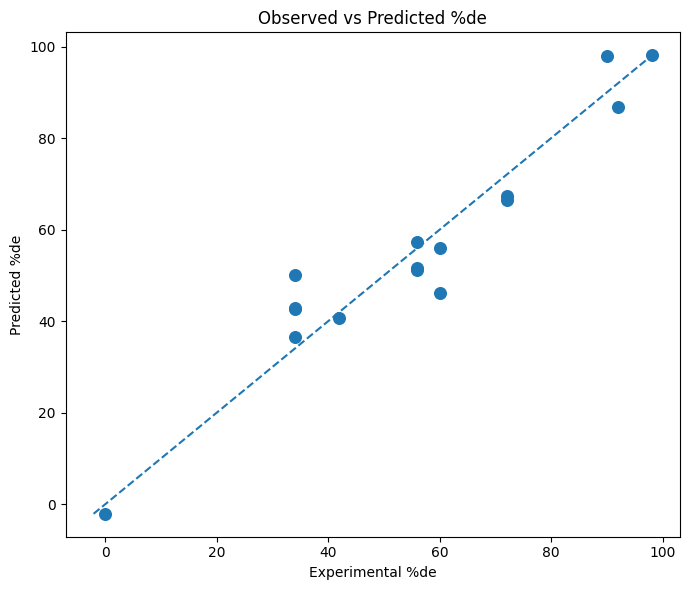

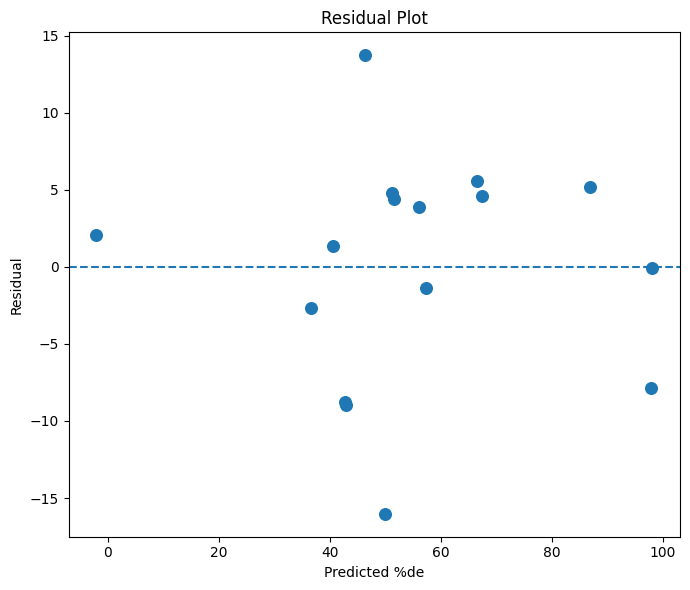



ANALYSIS COMPLETE

Results saved to:
/content/drive/MyDrive/xyz_files/R3_ALL_PARAMETER_ANALYSIS.xlsx

Total original parameters: 33
Regression candidate parameters: 26
Models tested: 2951

Best model:
B1 + Cone_Angle + XTB_Charge_C44

Best LOO-CV R²: 0.8491


In [12]:
# ============================================================
# R3 MULTIVARIATE REGRESSION ANALYSIS
# ALL AVAILABLE PARAMETERS
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================

!pip install -q pandas numpy openpyxl scipy statsmodels matplotlib seaborn


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings("ignore")


# ============================================================
# 3. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# 4. INPUT FILE
# ============================================================

input_file = "/content/drive/MyDrive/xyz_files/COMPLETE_R3_ANALYSIS.xlsx"

print("=" * 100)
print("R3 MULTIVARIATE REGRESSION ANALYSIS")
print("=" * 100)

print("\nInput file:")
print(input_file)

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"\nFile not found:\n{input_file}"
    )

print("\nFile found successfully.")


# ============================================================
# 5. READ EXCEL FILE
# ============================================================

df = pd.read_excel(input_file)

print("\nExcel columns:")
for col in df.columns:
    print(f"    {col}")


# ============================================================
# 6. STANDARDIZE IMPORTANT COLUMN NAMES
# ============================================================

column_mapping = {

    # Identification
    "Filename": "File",

    # Experimental response
    "%de": "Experimental_%de",

    # Steric descriptors
    "Sterimol_B1": "B1",
    "Sterimol_B5": "B5",
    "Sterimol_L": "L",

    "R3_%Vbur": "Vbur",

    "Geometric_Cone_Angle": "Cone_Angle",

    # Geometry
    "C18-C44_Distance": "C18_C44",

}

df = df.rename(columns=column_mapping)


# ============================================================
# 7. CHECK RESPONSE VARIABLE
# ============================================================

if "Experimental_%de" not in df.columns:

    # In case the original %de name survived
    if "%de" in df.columns:
        df["Experimental_%de"] = df["%de"]
    else:
        raise KeyError(
            "Experimental %de column was not found."
        )


# ============================================================
# 8. REMOVE IDENTIFICATION / CATEGORICAL COLUMNS
# ============================================================

exclude_columns = [

    "R3",
    "File",
    "Filename",
    "Experimental_%de",

    # categorical
    "Ring_Classification",
    "Cone_Limiting_Atom",

]


# ============================================================
# 9. IDENTIFY ALL NUMERICAL PARAMETERS
# ============================================================

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()

parameters = [
    col for col in numeric_columns
    if col not in exclude_columns
]


# ============================================================
# 10. PRINT PARAMETERS
# ============================================================

print("\n")
print("=" * 100)
print("ALL PARAMETERS AVAILABLE FOR MODELING")
print("=" * 100)

print(f"\nTotal numerical parameters found: {len(parameters)}")

for i, p in enumerate(parameters, 1):
    print(f"{i:2d}. {p}")


# ============================================================
# 11. PREPARE DATA
# ============================================================

analysis_columns = [
    "R3",
    "Experimental_%de"
] + parameters

analysis_df = df[
    [c for c in analysis_columns if c in df.columns]
].copy()


# Convert numerical columns
for col in ["Experimental_%de"] + parameters:

    if col in analysis_df.columns:

        analysis_df[col] = pd.to_numeric(
            analysis_df[col],
            errors="coerce"
        )


# ============================================================
# 12. REMOVE PARAMETERS WITH TOO MANY MISSING VALUES
# ============================================================

minimum_non_missing = 0.80 * len(analysis_df)

valid_parameters = []

for p in parameters:

    if analysis_df[p].notna().sum() >= minimum_non_missing:
        valid_parameters.append(p)

parameters = valid_parameters


print("\n")
print("=" * 100)
print("PARAMETERS AFTER MISSING-DATA CHECK")
print("=" * 100)

print(f"\nParameters retained: {len(parameters)}")

for p in parameters:
    print(f"   ✓ {p}")


# ============================================================
# 13. COMPLETE-CASE DATA FOR CORRELATION
# ============================================================

corr_df = analysis_df[
    ["Experimental_%de"] + parameters
].copy()


# ============================================================
# 14. PEARSON CORRELATION
# ============================================================

pearson_results = []

for p in parameters:

    temp = corr_df[
        ["Experimental_%de", p]
    ].dropna()

    if len(temp) >= 3:

        r, pvalue = pearsonr(
            temp["Experimental_%de"],
            temp[p]
        )

        pearson_results.append({
            "Parameter": p,
            "Pearson_r": r,
            "Pearson_p": pvalue,
            "N": len(temp)
        })


pearson_df = pd.DataFrame(
    pearson_results
)

pearson_df["Abs_Pearson_r"] = (
    pearson_df["Pearson_r"].abs()
)

pearson_df = pearson_df.sort_values(
    "Abs_Pearson_r",
    ascending=False
)


# ============================================================
# 15. SPEARMAN CORRELATION
# ============================================================

spearman_results = []

for p in parameters:

    temp = corr_df[
        ["Experimental_%de", p]
    ].dropna()

    if len(temp) >= 3:

        rho, pvalue = spearmanr(
            temp["Experimental_%de"],
            temp[p]
        )

        spearman_results.append({
            "Parameter": p,
            "Spearman_rho": rho,
            "Spearman_p": pvalue,
            "N": len(temp)
        })


spearman_df = pd.DataFrame(
    spearman_results
)

spearman_df["Abs_Spearman_rho"] = (
    spearman_df["Spearman_rho"].abs()
)

spearman_df = spearman_df.sort_values(
    "Abs_Spearman_rho",
    ascending=False
)


# ============================================================
# 16. COMBINE CORRELATION RESULTS
# ============================================================

correlation_results = pearson_df.merge(
    spearman_df,
    on=["Parameter", "N"],
    how="outer"
)

correlation_results = correlation_results.sort_values(
    "Abs_Spearman_rho",
    ascending=False
)


print("\n")
print("=" * 100)
print("CORRELATION WITH EXPERIMENTAL %de")
print("=" * 100)

display(
    correlation_results
)


# ============================================================
# 17. FULL PARAMETER CORRELATION MATRIX
# ============================================================

matrix_columns = [
    "Experimental_%de"
] + parameters

correlation_matrix_pearson = corr_df[
    matrix_columns
].corr(
    method="pearson"
)

correlation_matrix_spearman = corr_df[
    matrix_columns
].corr(
    method="spearman"
)


# ============================================================
# 18. VIF FUNCTION
# ============================================================

def calculate_vif(data, predictors):

    X = data[predictors].dropna().copy()

    if len(X) <= len(predictors) + 1:
        return pd.DataFrame({
            "Parameter": predictors,
            "VIF": np.nan
        })

    # Remove constant columns
    predictors_clean = []

    for p in predictors:

        if X[p].nunique() > 1:
            predictors_clean.append(p)

    X = X[predictors_clean]

    X_scaled = StandardScaler().fit_transform(X)

    vif_values = []

    for i, p in enumerate(predictors_clean):

        try:

            vif = variance_inflation_factor(
                X_scaled,
                i
            )

        except:
            vif = np.inf

        vif_values.append({
            "Parameter": p,
            "VIF": vif
        })

    return pd.DataFrame(vif_values)


# ============================================================
# 19. VIF FOR ALL PARAMETERS
# ============================================================

vif_all_df = calculate_vif(
    corr_df,
    parameters
)

vif_all_df = vif_all_df.sort_values(
    "VIF",
    ascending=False
)


print("\n")
print("=" * 100)
print("VIF — ALL PARAMETERS")
print("=" * 100)

display(
    vif_all_df
)


# ============================================================
# 20. REDUNDANCY SCREENING
# ============================================================
#
# ALL parameters are retained in correlation analysis.
#
# For regression, we remove highly correlated duplicate
# descriptors to reduce overfitting.
#
# Threshold:
# |r| >= 0.90
#
# When two descriptors are highly correlated, keep the one
# having the stronger absolute Spearman correlation with %de.
# ============================================================

spearman_matrix = corr_df[
    parameters
].corr(
    method="spearman"
)

response_spearman = {}

for p in parameters:

    temp = corr_df[
        ["Experimental_%de", p]
    ].dropna()

    if len(temp) >= 3:

        response_spearman[p] = abs(
            spearmanr(
                temp["Experimental_%de"],
                temp[p]
            ).statistic
        )

redundant_pairs = []

parameters_for_modeling = parameters.copy()

for i in range(len(parameters)):

    for j in range(i + 1, len(parameters)):

        p1 = parameters[i]
        p2 = parameters[j]

        if (
            p1 in parameters_for_modeling
            and
            p2 in parameters_for_modeling
        ):

            r = spearman_matrix.loc[p1, p2]

            if abs(r) >= 0.90:

                redundant_pairs.append({
                    "Parameter_1": p1,
                    "Parameter_2": p2,
                    "Spearman_r": r
                })

                score1 = response_spearman.get(
                    p1, 0
                )

                score2 = response_spearman.get(
                    p2, 0
                )

                # Keep descriptor with stronger
                # relationship to experimental %de

                if score1 >= score2:
                    parameters_for_modeling.remove(p2)

                else:
                    parameters_for_modeling.remove(p1)


redundant_pairs_df = pd.DataFrame(
    redundant_pairs
)


# ============================================================
# 21. PRINT MODELING PARAMETERS
# ============================================================

print("\n")
print("=" * 100)
print("PARAMETERS USED AS REGRESSION CANDIDATES")
print("=" * 100)

print(
    f"\nOriginal parameters: {len(parameters)}"
)

print(
    f"Regression candidates after redundancy screening: "
    f"{len(parameters_for_modeling)}"
)

for p in parameters_for_modeling:
    print(f"   ✓ {p}")


# ============================================================
# 22. LOO-CV FUNCTION
# ============================================================

def loo_cv_metrics(data, predictors, response):

    temp = data[
        [response] + predictors
    ].dropna().copy()

    n = len(temp)
    k = len(predictors)

    if n <= k + 2:
        return np.nan, np.nan

    X = temp[predictors].values
    y = temp[response].values

    predictions = np.zeros(n)

    for i in range(n):

        train_indices = [
            j for j in range(n)
            if j != i
        ]

        X_train = X[train_indices]
        y_train = y[train_indices]

        X_test = X[i].reshape(1, -1)

        model = LinearRegression()

        model.fit(
            X_train,
            y_train
        )

        predictions[i] = model.predict(
            X_test
        )[0]

    press = np.sum(
        (y - predictions) ** 2
    )

    sst = np.sum(
        (y - np.mean(y)) ** 2
    )

    loo_r2 = 1 - press / sst

    loo_rmse = np.sqrt(
        np.mean(
            (y - predictions) ** 2
        )
    )

    return loo_r2, loo_rmse


# ============================================================
# 23. AICc FUNCTION
# ============================================================

def calculate_aicc(model, n, k):

    aic = model.aic

    correction = (
        (2 * k * (k + 1))
        /
        (n - k - 1)
    )

    return aic + correction


# ============================================================
# 24. FIT ONE MODEL
# ============================================================

def evaluate_model(data, predictors, response):

    temp = data[
        [response] + predictors
    ].dropna().copy()

    n = len(temp)
    k = len(predictors)

    if n <= k + 2:
        return None

    X = temp[predictors]
    y = temp[response]

    X_const = sm.add_constant(
        X,
        has_constant="add"
    )

    try:

        model = sm.OLS(
            y,
            X_const
        ).fit()

    except:
        return None

    loo_r2, loo_rmse = loo_cv_metrics(
        data,
        predictors,
        response
    )

    vif_df = calculate_vif(
        temp,
        predictors
    )

    if len(vif_df) > 0:
        max_vif = vif_df["VIF"].max()
    else:
        max_vif = np.nan

    aicc = calculate_aicc(
        model,
        n,
        k + 1
    )

    return {

        "N": n,

        "Predictors": " + ".join(
            predictors
        ),

        "N_Predictors": k,

        "R2": model.rsquared,

        "Adjusted_R2":
            model.rsquared_adj,

        "LOO_CV_R2":
            loo_r2,

        "LOO_CV_RMSE":
            loo_rmse,

        "AICc":
            aicc,

        "Max_VIF":
            max_vif,

        "Min_P":
            model.pvalues[
                model.pvalues.index != "const"
            ].max()
            if k > 0 else np.nan,

        "Condition_Number":
            model.condition_number

    }


# ============================================================
# 25. TEST ALL REASONABLE MODEL COMBINATIONS
# ============================================================
#
# Because n = 17, we limit the maximum number of
# simultaneous predictors.
#
# Recommended maximum = 3 predictors.
#
# This still tests:
# 1-variable models
# 2-variable models
# 3-variable models
#
# while avoiding severe overfitting.
# ============================================================

MAX_PREDICTORS = 3

if len(parameters_for_modeling) < MAX_PREDICTORS:
    MAX_PREDICTORS = len(
        parameters_for_modeling
    )

print("\n")
print("=" * 100)
print("MODEL SEARCH")
print("=" * 100)

print(
    f"\nTesting 1 to {MAX_PREDICTORS} predictors."
)

model_results = []

for n_predictors in range(
    1,
    MAX_PREDICTORS + 1
):

    combinations = itertools.combinations(
        parameters_for_modeling,
        n_predictors
    )

    count = 0

    for combination in combinations:

        result = evaluate_model(
            analysis_df,
            list(combination),
            "Experimental_%de"
        )

        if result is not None:

            model_results.append(
                result
            )

        count += 1

    print(
        f"Tested {count} models with "
        f"{n_predictors} predictor(s)."
    )


# ============================================================
# 26. MODEL RESULTS DATAFRAME
# ============================================================

model_results_df = pd.DataFrame(
    model_results
)


# ============================================================
# 27. REMOVE INVALID MODELS
# ============================================================

model_results_df = model_results_df[
    model_results_df["LOO_CV_R2"].notna()
].copy()


# ============================================================
# 28. RANK MODELS
# ============================================================

model_results_df = model_results_df.sort_values(
    [
        "LOO_CV_R2",
        "Adjusted_R2",
        "R2"
    ],
    ascending=[
        False,
        False,
        False
    ]
).reset_index(drop=True)


model_results_df.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(model_results_df) + 1
    )
)


# ============================================================
# 29. TOP MODELS
# ============================================================

print("\n")
print("=" * 100)
print("TOP REGRESSION MODELS")
print("=" * 100)

display(
    model_results_df.head(30)
)


# ============================================================
# 30. MODELS WITH VIF < 5
# ============================================================

good_vif_models = model_results_df[
    model_results_df["Max_VIF"] < 5
].copy()


print("\n")
print("=" * 100)
print("TOP MODELS WITH MAX VIF < 5")
print("=" * 100)

display(
    good_vif_models.head(30)
)


# ============================================================
# 31. BEST MODEL
# ============================================================

if len(good_vif_models) > 0:

    best_model_info = (
        good_vif_models.iloc[0]
    )

else:

    best_model_info = (
        model_results_df.iloc[0]
    )


best_predictors = [
    x.strip()
    for x in
    best_model_info["Predictors"].split("+")
]


print("\n")
print("=" * 100)
print("BEST MODEL")
print("=" * 100)

print(
    "\nPredictors:"
)

for p in best_predictors:
    print(
        f"   ✓ {p}"
    )

print(
    f"\nR² = "
    f"{best_model_info['R2']:.4f}"
)

print(
    f"Adjusted R² = "
    f"{best_model_info['Adjusted_R2']:.4f}"
)

print(
    f"LOO-CV R² = "
    f"{best_model_info['LOO_CV_R2']:.4f}"
)

print(
    f"LOO-CV RMSE = "
    f"{best_model_info['LOO_CV_RMSE']:.4f}"
)

print(
    f"AICc = "
    f"{best_model_info['AICc']:.4f}"
)

print(
    f"Maximum VIF = "
    f"{best_model_info['Max_VIF']:.4f}"
)


# ============================================================
# 32. FIT BEST MODEL
# ============================================================

best_data = analysis_df[
    ["Experimental_%de"] +
    best_predictors
].dropna().copy()

X_best = best_data[
    best_predictors
]

y_best = best_data[
    "Experimental_%de"
]

X_best_const = sm.add_constant(
    X_best,
    has_constant="add"
)

best_ols = sm.OLS(
    y_best,
    X_best_const
).fit()


# ============================================================
# 33. BEST MODEL SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("BEST MODEL — OLS SUMMARY")
print("=" * 100)

print(
    best_ols.summary()
)


# ============================================================
# 34. COEFFICIENT TABLE
# ============================================================

coefficient_df = pd.DataFrame({

    "Parameter":
        best_ols.params.index,

    "Coefficient":
        best_ols.params.values,

    "Std_Error":
        best_ols.bse.values,

    "t_value":
        best_ols.tvalues.values,

    "p_value":
        best_ols.pvalues.values,

    "CI_Lower":
        best_ols.conf_int()[0].values,

    "CI_Upper":
        best_ols.conf_int()[1].values

})


print("\n")
print("=" * 100)
print("BEST MODEL COEFFICIENTS")
print("=" * 100)

display(
    coefficient_df
)


# ============================================================
# 35. PREDICTIONS FOR BEST MODEL
# ============================================================

best_data["Predicted_%de"] = (
    best_ols.predict(
        X_best_const
    )
)

best_data["Residual"] = (
    best_data["Experimental_%de"]
    -
    best_data["Predicted_%de"]
)


# ============================================================
# 36. ADD R3 IDENTIFIERS
# ============================================================

identifier_df = analysis_df[
    ["R3"]
].copy()

identifier_df = identifier_df.loc[
    best_data.index
]

best_data.insert(
    0,
    "R3",
    identifier_df["R3"].values
)


# ============================================================
# 37. DISPLAY PREDICTIONS
# ============================================================

print("\n")
print("=" * 100)
print("EXPERIMENTAL vs PREDICTED %de")
print("=" * 100)

display(
    best_data
)


# ============================================================
# 38. OBSERVED vs PREDICTED PLOT
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    best_data["Experimental_%de"],
    best_data["Predicted_%de"],
    s=70
)

min_value = min(
    best_data["Experimental_%de"].min(),
    best_data["Predicted_%de"].min()
)

max_value = max(
    best_data["Experimental_%de"].max(),
    best_data["Predicted_%de"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Experimental %de"
)

plt.ylabel(
    "Predicted %de"
)

plt.title(
    "Observed vs Predicted %de"
)

plt.tight_layout()

plt.show()


# ============================================================
# 39. RESIDUAL PLOT
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    best_data["Predicted_%de"],
    best_data["Residual"],
    s=70
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted %de"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Plot"
)

plt.tight_layout()

plt.show()


# ============================================================
# 40. SAVE EVERYTHING TO EXCEL
# ============================================================

output_file = (
    "/content/drive/MyDrive/"
    "xyz_files/"
    "R3_ALL_PARAMETER_ANALYSIS.xlsx"
)

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Original data
    df.to_excel(
        writer,
        sheet_name="Original_Data",
        index=False
    )

    # Analysis data
    analysis_df.to_excel(
        writer,
        sheet_name="Analysis_Data",
        index=False
    )

    # Correlations
    correlation_results.to_excel(
        writer,
        sheet_name="Correlation_Results",
        index=False
    )

    # Pearson matrix
    correlation_matrix_pearson.to_excel(
        writer,
        sheet_name="Pearson_Matrix"
    )

    # Spearman matrix
    correlation_matrix_spearman.to_excel(
        writer,
        sheet_name="Spearman_Matrix"
    )

    # VIF
    vif_all_df.to_excel(
        writer,
        sheet_name="VIF_All",
        index=False
    )

    # Redundant pairs
    redundant_pairs_df.to_excel(
        writer,
        sheet_name="Redundant_Pairs",
        index=False
    )

    # Model results
    model_results_df.to_excel(
        writer,
        sheet_name="All_Models",
        index=False
    )

    # Good VIF models
    good_vif_models.to_excel(
        writer,
        sheet_name="Models_VIF_lt5",
        index=False
    )

    # Best model coefficients
    coefficient_df.to_excel(
        writer,
        sheet_name="Best_Model_Coefficients",
        index=False
    )

    # Best model predictions
    best_data.to_excel(
        writer,
        sheet_name="Best_Model_Predictions",
        index=False
    )


# ============================================================
# 41. FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 100)
print("ANALYSIS COMPLETE")
print("=" * 100)

print(
    f"\nResults saved to:"
)

print(
    output_file
)

print(
    "\nTotal original parameters:",
    len(parameters)
)

print(
    "Regression candidate parameters:",
    len(parameters_for_modeling)
)

print(
    "Models tested:",
    len(model_results_df)
)

print(
    "\nBest model:"
)

print(
    best_model_info["Predictors"]
)

print(
    f"\nBest LOO-CV R²: "
    f"{best_model_info['LOO_CV_R2']:.4f}"
)



R3 DECISION TREE REGRESSION — ALL PARAMETERS

Total candidate parameters:
33
 1. B1
 2. B5
 3. L
 4. Vbur
 5. Cone_Angle
 6. Geometric_Half_Cone_Angle
 7. O17-C22_Forming_Bond
 8. C22_Angle_Sum
 9. C22_Pyramidalization
10. BD_O17_C22_C21
11. BD_O17_C22_C23
12. BD_Average
13. CP_Q
14. CP_Theta
15. CP_Phi
16. O15-H16
17. H16-O17
18. O15-H16-O17_Angle
19. C18_C44
20. C18-R_Torsion
21. XTB_Energy
22. XTB_HOMO
23. XTB_LUMO
24. XTB_Gap
25. XTB_Dipole
26. XTB_IP
27. XTB_EA
28. XTB_Electrophilicity
29. XTB_Nucleophilicity
30. XTB_Charge_C18
31. XTB_Charge_C44
32. XTB_Charge_C22
33. XTB_BondOrder_O17_C22


DECISION TREE DATASET

Number of compounds: 16
Number of parameters: 33


DECISION TREE RESULTS


,Rank,Max_Depth,Min_Samples_Leaf,Actual_Depth,Number_of_Leaves,Training_R2,LOO_CV_R2,LOO_CV_RMSE
0,1,2.0,4,2,3,0.795746,0.305739,20.857379
1,2,3.0,4,2,3,0.795746,0.305739,20.857379
2,3,4.0,4,2,3,0.795746,0.305739,20.857379
3,4,5.0,4,2,3,0.795746,0.305739,20.857379
4,5,NaN,4,2,3,0.795746,0.305739,20.857379
5,6,3.0,3,3,4,0.829260,0.283533,21.188327
6,7,4.0,3,3,4,0.829260,0.283533,21.188327
7,8,5.0,3,3,4,0.829260,0.283533,21.188327
8,9,NaN,3,3,4,0.829260,0.283533,21.188327
9,10,2.0,3,2,3,0.795746,0.249897,21.679981




BEST DECISION TREE

Maximum depth: 2
Minimum samples per leaf: 4
Actual tree depth: 2.0
Number of leaves: 3.0
Training R²: 0.7957
LOO-CV R²: 0.3057
LOO-CV RMSE: 20.8574


DECISION TREE FEATURE IMPORTANCE


,Parameter,Importance
0,B1,0.775939
1,Cone_Angle,0.224061
2,B5,0.000000
3,L,0.000000
4,Vbur,0.000000
5,Geometric_Half_Cone_Angle,0.000000
6,O17-C22_Forming_Bond,0.000000
7,C22_Angle_Sum,0.000000
8,C22_Pyramidalization,0.000000
9,BD_O17_C22_C21,0.000000




PARAMETERS USED BY THE TREE


,Parameter,Importance
0,B1,0.775939
1,Cone_Angle,0.224061




DECISION TREE — EXPERIMENTAL vs PREDICTED


,R3,Experimental_%de,Predicted_%de,Residual
0,CH2-Ph,56,52.0,4.0
1,CH2-dioxane,34,52.0,-18.0
2,CH2CN,60,52.0,8.0
3,CH2CO2Me,42,52.0,-10.0
4,CMe2CO2Me,92,84.8,7.2
5,Cy,72,84.8,-12.8
6,Et,56,52.0,4.0
7,Me-Propane,60,52.0,8.0
8,Ph,34,25.5,8.5
9,alkene,34,25.5,8.5


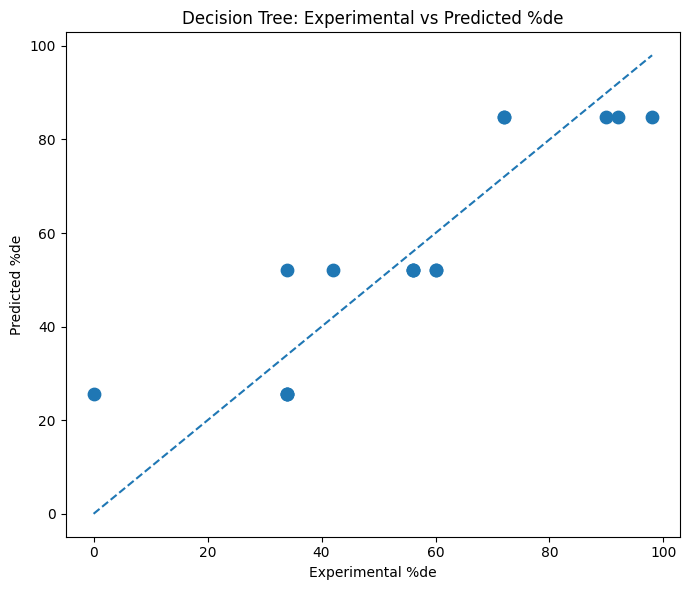

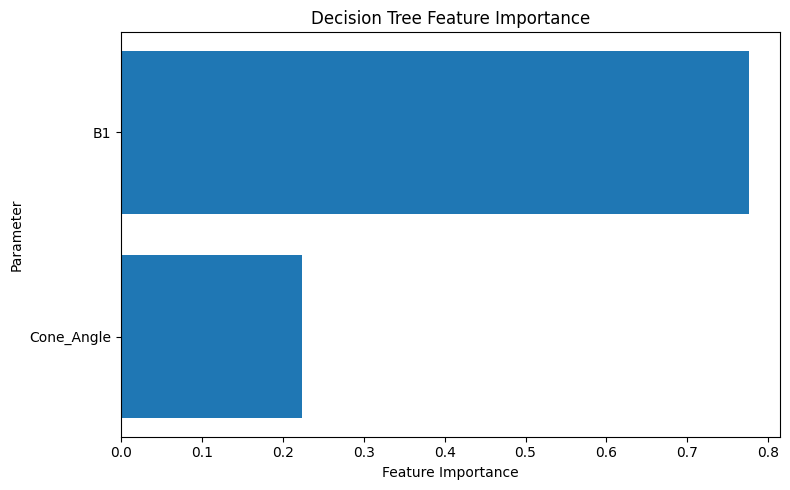

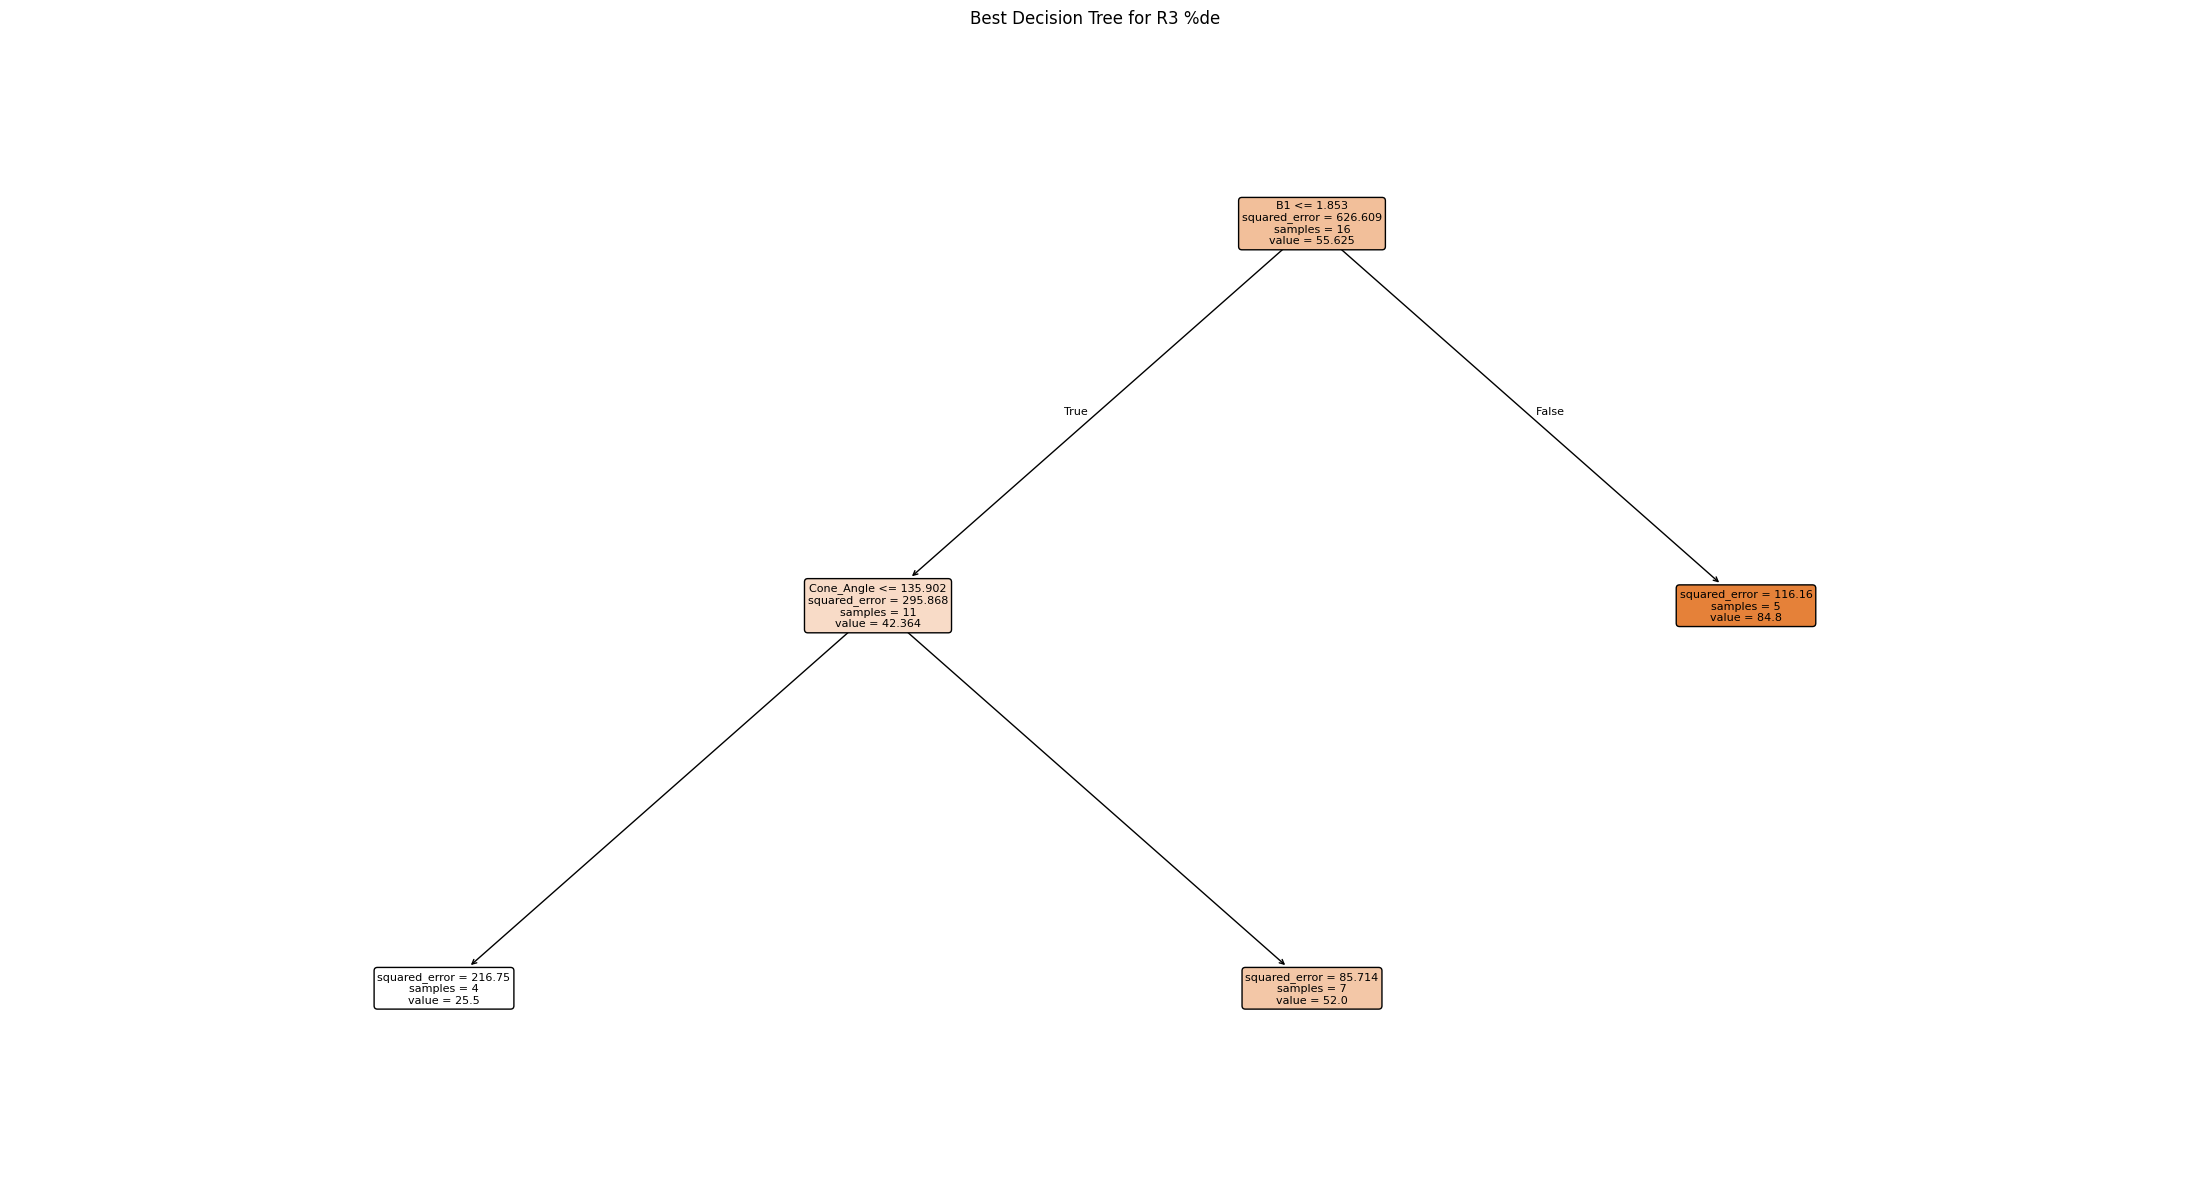



DECISION TREE ANALYSIS COMPLETE

Results saved to:
/content/drive/MyDrive/xyz_files/R3_DECISION_TREE_ALL_PARAMETERS.xlsx

Best tree LOO-CV R²: 0.3057
Best tree LOO-CV RMSE: 20.8574

Most important parameters:


,Parameter,Importance
0,B1,0.775939
1,Cone_Angle,0.224061
2,B5,0.000000
3,L,0.000000
4,Vbur,0.000000
5,Geometric_Half_Cone_Angle,0.000000
6,O17-C22_Forming_Bond,0.000000
7,C22_Angle_Sum,0.000000
8,C22_Pyramidalization,0.000000
9,BD_O17_C22_C21,0.000000


In [15]:
# ============================================================
# R3 DECISION TREE REGRESSION
# USING ALL AVAILABLE PARAMETERS
# ============================================================

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    r2_score,
    mean_squared_error
)
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PREPARE DATA
# ============================================================

print("\n")
print("=" * 100)
print("R3 DECISION TREE REGRESSION — ALL PARAMETERS")
print("=" * 100)


# Use ALL parameters identified previously
dt_parameters = parameters.copy()

print("\nTotal candidate parameters:")
print(len(dt_parameters))

for i, p in enumerate(dt_parameters, 1):
    print(f"{i:2d}. {p}")


# ============================================================
# 2. CREATE COMPLETE DATASET
# ============================================================

dt_df = analysis_df[
    ["R3", "Experimental_%de"] + dt_parameters
].copy()


# Convert everything to numeric
for p in dt_parameters:
    dt_df[p] = pd.to_numeric(
        dt_df[p],
        errors="coerce"
    )

dt_df["Experimental_%de"] = pd.to_numeric(
    dt_df["Experimental_%de"],
    errors="coerce"
)


# ============================================================
# 3. REMOVE PARAMETERS WITH MISSING VALUES
# ============================================================

dt_parameters = [
    p for p in dt_parameters
    if dt_df[p].notna().sum() >= 0.80 * len(dt_df)
]


# Complete-case dataset
dt_complete = dt_df[
    ["R3", "Experimental_%de"] + dt_parameters
].dropna().reset_index(drop=True)


print("\n")
print("=" * 100)
print("DECISION TREE DATASET")
print("=" * 100)

print(
    f"\nNumber of compounds: {len(dt_complete)}"
)

print(
    f"Number of parameters: {len(dt_parameters)}"
)


# ============================================================
# 4. X AND Y
# ============================================================

X = dt_complete[
    dt_parameters
]

y = dt_complete[
    "Experimental_%de"
]


# ============================================================
# 5. TEST DIFFERENT TREE COMPLEXITIES
# ============================================================

tree_results = []

loo = LeaveOneOut()

# Different maximum depths
max_depth_values = [
    1,
    2,
    3,
    4,
    5,
    None
]

# Different minimum samples per leaf
min_leaf_values = [
    1,
    2,
    3,
    4
]


for max_depth in max_depth_values:

    for min_leaf in min_leaf_values:

        predictions = np.zeros(
            len(y)
        )

        valid = True

        for train_index, test_index in loo.split(X):

            X_train = X.iloc[
                train_index
            ]

            X_test = X.iloc[
                test_index
            ]

            y_train = y.iloc[
                train_index
            ]

            # Avoid impossible tree structures
            if len(y_train) < min_leaf:
                valid = False
                break

            tree = DecisionTreeRegressor(
                max_depth=max_depth,
                min_samples_leaf=min_leaf,
                random_state=42
            )

            tree.fit(
                X_train,
                y_train
            )

            predictions[test_index] = (
                tree.predict(X_test)
            )

        if not valid:
            continue


        # ----------------------------------------------------
        # LOO-CV statistics
        # ----------------------------------------------------

        loo_r2 = r2_score(
            y,
            predictions
        )

        loo_rmse = np.sqrt(
            mean_squared_error(
                y,
                predictions
            )
        )


        # ----------------------------------------------------
        # Fit tree on complete dataset
        # ----------------------------------------------------

        final_tree = DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            random_state=42
        )

        final_tree.fit(
            X,
            y
        )

        train_predictions = (
            final_tree.predict(X)
        )

        train_r2 = r2_score(
            y,
            train_predictions
        )


        # ----------------------------------------------------
        # Tree complexity
        # ----------------------------------------------------

        n_leaves = (
            final_tree.get_n_leaves()
        )

        tree_depth = (
            final_tree.get_depth()
        )


        tree_results.append({

            "Max_Depth": max_depth,

            "Min_Samples_Leaf":
                min_leaf,

            "Actual_Depth":
                tree_depth,

            "Number_of_Leaves":
                n_leaves,

            "Training_R2":
                train_r2,

            "LOO_CV_R2":
                loo_r2,

            "LOO_CV_RMSE":
                loo_rmse

        })


# ============================================================
# 6. RESULTS
# ============================================================

tree_results_df = pd.DataFrame(
    tree_results
)

tree_results_df = tree_results_df.sort_values(
    [
        "LOO_CV_R2",
        "LOO_CV_RMSE"
    ],
    ascending=[
        False,
        True
    ]
).reset_index(drop=True)


tree_results_df.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(tree_results_df) + 1
    )
)


print("\n")
print("=" * 100)
print("DECISION TREE RESULTS")
print("=" * 100)

display(
    tree_results_df
)


# ============================================================
# 7. BEST TREE
# ============================================================

best_tree_info = (
    tree_results_df.iloc[0]
)


# ============================================================
# CONVERT TREE PARAMETERS TO CORRECT TYPES
# ============================================================

best_depth = best_tree_info["Max_Depth"]

# max_depth must be either int or None
if pd.isna(best_depth):
    best_depth = None
else:
    best_depth = int(best_depth)

best_leaf = int(
    best_tree_info["Min_Samples_Leaf"]
)


print("\n")
print("=" * 100)
print("BEST DECISION TREE")
print("=" * 100)

print(
    f"\nMaximum depth: {best_depth}"
)

print(
    f"Minimum samples per leaf: {best_leaf}"
)

print(
    f"Actual tree depth: "
    f"{best_tree_info['Actual_Depth']}"
)

print(
    f"Number of leaves: "
    f"{best_tree_info['Number_of_Leaves']}"
)

print(
    f"Training R²: "
    f"{best_tree_info['Training_R2']:.4f}"
)

print(
    f"LOO-CV R²: "
    f"{best_tree_info['LOO_CV_R2']:.4f}"
)

print(
    f"LOO-CV RMSE: "
    f"{best_tree_info['LOO_CV_RMSE']:.4f}"
)


# ============================================================
# 8. FIT BEST TREE
# ============================================================

best_tree = DecisionTreeRegressor(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    random_state=42
)

best_tree.fit(
    X,
    y
)


# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

feature_importance_df = pd.DataFrame({

    "Parameter":
        dt_parameters,

    "Importance":
        best_tree.feature_importances_

})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 100)
print("DECISION TREE FEATURE IMPORTANCE")
print("=" * 100)

display(
    feature_importance_df
)


# ============================================================
# 10. ONLY IMPORTANT PARAMETERS
# ============================================================

important_features = (
    feature_importance_df[
        feature_importance_df["Importance"] > 0
    ]
)


print("\n")
print("=" * 100)
print("PARAMETERS USED BY THE TREE")
print("=" * 100)

display(
    important_features
)


# ============================================================
# 11. TREE PREDICTIONS
# ============================================================

dt_predictions_df = dt_complete[
    ["R3", "Experimental_%de"]
].copy()

dt_predictions_df[
    "Predicted_%de"
] = best_tree.predict(X)

dt_predictions_df[
    "Residual"
] = (
    dt_predictions_df[
        "Experimental_%de"
    ]
    -
    dt_predictions_df[
        "Predicted_%de"
    ]
)


# ============================================================
# 12. DISPLAY PREDICTIONS
# ============================================================

print("\n")
print("=" * 100)
print("DECISION TREE — EXPERIMENTAL vs PREDICTED")
print("=" * 100)

display(
    dt_predictions_df
)


# ============================================================
# 13. OBSERVED vs PREDICTED
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    dt_predictions_df[
        "Experimental_%de"
    ],
    dt_predictions_df[
        "Predicted_%de"
    ],
    s=80
)

min_val = min(
    dt_predictions_df[
        "Experimental_%de"
    ].min(),
    dt_predictions_df[
        "Predicted_%de"
    ].min()
)

max_val = max(
    dt_predictions_df[
        "Experimental_%de"
    ].max(),
    dt_predictions_df[
        "Predicted_%de"
    ].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel(
    "Experimental %de"
)

plt.ylabel(
    "Predicted %de"
)

plt.title(
    "Decision Tree: Experimental vs Predicted %de"
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. FEATURE IMPORTANCE PLOT
# ============================================================

plot_df = feature_importance_df[
    feature_importance_df["Importance"] > 0
].copy()

plot_df = plot_df.sort_values(
    "Importance"
)

plt.figure(
    figsize=(8, max(5, len(plot_df) * 0.35))
)

plt.barh(
    plot_df["Parameter"],
    plot_df["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Parameter"
)

plt.title(
    "Decision Tree Feature Importance"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. VISUALIZE DECISION TREE
# ============================================================

plt.figure(
    figsize=(22, 12)
)

plot_tree(
    best_tree,
    feature_names=dt_parameters,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Best Decision Tree for R3 %de"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. SAVE DECISION TREE RESULTS
# ============================================================

dt_output_file = (
    "/content/drive/MyDrive/"
    "xyz_files/"
    "R3_DECISION_TREE_ALL_PARAMETERS.xlsx"
)


with pd.ExcelWriter(
    dt_output_file,
    engine="openpyxl"
) as writer:

    dt_complete.to_excel(
        writer,
        sheet_name="Tree_Data",
        index=False
    )

    tree_results_df.to_excel(
        writer,
        sheet_name="Tree_Models",
        index=False
    )

    feature_importance_df.to_excel(
        writer,
        sheet_name="Feature_Importance",
        index=False
    )

    dt_predictions_df.to_excel(
        writer,
        sheet_name="Predictions",
        index=False
    )


# ============================================================
# 17. FINAL
# ============================================================

print("\n")
print("=" * 100)
print("DECISION TREE ANALYSIS COMPLETE")
print("=" * 100)

print(
    "\nResults saved to:"
)

print(
    dt_output_file
)

print(
    "\nBest tree LOO-CV R²:",
    round(
        best_tree_info["LOO_CV_R2"],
        4
    )
)

print(
    "Best tree LOO-CV RMSE:",
    round(
        best_tree_info["LOO_CV_RMSE"],
        4
    )
)

print(
    "\nMost important parameters:"
)

display(
    feature_importance_df.head(10)
)

In [16]:
# ============================================================
# SASA — SOLVENT ACCESSIBLE SURFACE AREA (DCM probe radius)
# ============================================================
from morfeus import SASA, read_xyz
import os
import pandas as pd

xyz_folder = "/content/drive/MyDrive/xyz_files"

# DCM probe radius — commonly cited around 2.34-2.5 Å depending on source/convention.
# Double-check this value against the specific reference you want to cite before
# using it in a manuscript; adjust DCM_PROBE_RADIUS accordingly.
DCM_PROBE_RADIUS = 2.40  # Å

C18_ATOM = 18
C44_ATOM = 44
O17_ATOM = 17

def get_sasa_descriptors(xyz_path, probe_radius=DCM_PROBE_RADIUS):
    elements, coordinates = read_xyz(xyz_path)
    sasa = SASA(elements, coordinates, probe_radius=probe_radius)

    return {
        "File": os.path.basename(xyz_path),
        "Total SASA (Å²)": sasa.area,
        "Enclosed volume (Å³)": sasa.volume,
        "SASA_C18 (Å²)": sasa.atom_areas.get(C18_ATOM),
        "SASA_C44 (Å²)": sasa.atom_areas.get(C44_ATOM),
        "SASA_O17 (Å²)": sasa.atom_areas.get(O17_ATOM),
    }

xyz_files = sorted([f for f in os.listdir(xyz_folder) if f.lower().endswith(".xyz")])

rows = []
for f in xyz_files:
    path = os.path.join(xyz_folder, f)
    try:
        row = get_sasa_descriptors(path)
        rows.append(row)
        print(f"✅ {f}: Total SASA = {row['Total SASA (Å²)']:.2f} Å²,  "
              f"SASA_C18 = {row['SASA_C18 (Å²)']:.2f} Å²")
    except Exception as e:
        print(f"⚠️ Failed for {f}: {e}")

df_sasa = pd.DataFrame(rows)
print("\n")
print(df_sasa.to_string(index=False))

out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
os.makedirs(out_dir, exist_ok=True)
df_sasa.to_csv(os.path.join(out_dir, "SASA_descriptors_DCM.csv"), index=False)
print(f"\n✅ Saved: {os.path.join(out_dir, 'SASA_descriptors_DCM.csv')}")

✅ RR_CH2-Ph.xyz: Total SASA = 849.02 Å²,  SASA_C18 = 0.00 Å²
✅ RR_CH2-dioxane.xyz: Total SASA = 836.08 Å²,  SASA_C18 = 0.00 Å²
✅ RR_CH2CN.xyz: Total SASA = 767.57 Å²,  SASA_C18 = 0.00 Å²
✅ RR_CH2CO2Me.xyz: Total SASA = 804.19 Å²,  SASA_C18 = 0.00 Å²
✅ RR_CMe2CO2Me.xyz: Total SASA = 833.33 Å²,  SASA_C18 = 0.00 Å²
✅ RR_Cy.xyz: Total SASA = 851.14 Å²,  SASA_C18 = 0.00 Å²
✅ RR_Et.xyz: Total SASA = 766.78 Å²,  SASA_C18 = 0.00 Å²
✅ RR_Me-Propane.xyz: Total SASA = 816.21 Å²,  SASA_C18 = 0.00 Å²
✅ RR_Me.xyz: Total SASA = 742.76 Å²,  SASA_C18 = 0.00 Å²
✅ RR_Ph.xyz: Total SASA = 835.69 Å²,  SASA_C18 = 0.00 Å²
✅ RR_alkene.xyz: Total SASA = 756.92 Å²,  SASA_C18 = 0.00 Å²
✅ RR_alkyne.xyz: Total SASA = 766.15 Å²,  SASA_C18 = 0.00 Å²
✅ RR_allyl.xyz: Total SASA = 790.01 Å²,  SASA_C18 = 0.00 Å²
✅ RR_dimethyl-allyl.xyz: Total SASA = 824.16 Å²,  SASA_C18 = 0.00 Å²
✅ RR_iPr.xyz: Total SASA = 782.61 Å²,  SASA_C18 = 0.00 Å²
✅ RR_nBu.xyz: Total SASA = 830.89 Å²,  SASA_C18 = 0.00 Å²
✅ RR_tBu.xyz: Total SASA =